# ModernBERT: The Hard Way

We will build and understand a ModernBERT-style encoder Transformer from first principles.

The goal is not just to use a pretrained ModernBERT model. We will progressively implement and inspect the important pieces ourselves:

- Tokenization and input representation
- Embeddings
- Transformer encoder blocks
- Q, K, V and bidirectional self-attention
- RoPE
- Local / global attention
- Normalization, residual connections and MLP
- Stacking the encoder layers
- Understanding the `[batch, sequence, hidden]` output
- Building a compatibility head on top of ModernBERT

## Final experiment

We will turn the encoder into a semantic router for a multi-agent system.

For each candidate agent:

    chat history + agent description
                 ↓
             ModernBERT
                 ↓
        compatibility head
                 ↓
               score

With 5 candidate agents:

    chat history + Agent A → ModernBERT → score A
    chat history + Agent B → ModernBERT → score B
    chat history + Agent C → ModernBERT → score C
    chat history + Agent D → ModernBERT → score D
    chat history + Agent E → ModernBERT → score E

The highest-scoring agent is selected.

Our test data will deliberately contain:

1. Multi-turn conversations
2. At least two closely related agents
3. Ambiguous requests
4. Context-dependent requests
5. "Ding-dong" conversations where the user repeatedly jumps between agents
6. Cases where the router should resist unnecessary switching

We will proceed **one notebook unit at a time**.

Each unit consists of exactly:

**one Markdown cell + one Code cell.**

In [72]:
# ModernBERT: The Hard Way
# Cell 1 — Environment sanity check

import sys
import torch

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device :", "CUDA" if torch.cuda.is_available() else "CPU")

Python : 3.13.15
PyTorch: 2.11.0+cu128
Device : CUDA


In [73]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


In [74]:
!pip install -q "transformers==5.17.0"

---
# Phase 1 — Establish what ModernBERT is

## Cell 2 — Encoder vs decoder

**What.** Compare two Transformer families on a 4-token sequence, `the cat sat down`:

```text
SmolLM2 (decoder):    tokens → next token
ModernBERT (encoder): tokens → contextual representations
```

**Why.** Everything later depends on this difference. SmolLM2 *generates*: at position `i` it predicts token `i+1`, so it must never see the future and uses a **causal mask**. ModernBERT *understands*: it produces one vector per token that summarizes that token **in the context of the whole sequence**, left and right. It has no "next token" to predict, so it doesn't need a causal mask and doesn't generate text autoregressively.

**Math.** Attention lets query token `i` read from key token `j` only where the visibility mask allows it:

- decoder: `visible[i, j] = (j ≤ i)`, a lower-triangular matrix with `S(S+1)/2` true entries
- encoder: `visible[i, j] = True` for all `i, j`, giving `S²` true entries

The training objectives differ in the same way. A decoder learns `P(token_{i+1} | tokens_≤i)`. A BERT-style encoder learns **masked language modelling**: hide a token with `[MASK]` and recover it from *both* sides.

**Shapes.** Each visibility mask is `[S, S]` = `[4, 4]`. Row = query token, column = key token.

**Expect.** In the decoder table, `the` sees only itself and `down` sees everything. In the encoder table every row is full. The masked-LM example shows `cat` being recovered from `the … sat down`, which needs right-hand context.

In [75]:
# Cell 2 — Encoder vs decoder: which tokens can each token see?

tokens = ["the", "cat", "sat", "down"]
S = len(tokens)

# Decoder (SmolLM2): query i may attend to keys 0..i  -> lower-triangular
decoder_visibility = torch.tril(torch.ones(S, S, dtype=torch.bool))

# Encoder (ModernBERT): query i may attend to every key -> all True
encoder_visibility = torch.ones(S, S, dtype=torch.bool)

print("decoder_visibility:", tuple(decoder_visibility.shape), "| encoder_visibility:", tuple(encoder_visibility.shape))
print()


def show_visibility(title, visibility):
    print(title)
    print("query \\ key".ljust(13) + "".join(t.ljust(6) for t in tokens))
    for i, t in enumerate(tokens):
        row = "".join(("✓" if visibility[i, j] else "·").ljust(6) for j in range(S))
        print(t.ljust(13) + row)
    print()


show_visibility("Decoder (causal) — SmolLM2", decoder_visibility)
show_visibility("Encoder (bidirectional) — ModernBERT", encoder_visibility)

print("What each token's output can depend on:")
for i, t in enumerate(tokens):
    dec = [tokens[j] for j in range(S) if decoder_visibility[i, j]]
    enc = [tokens[j] for j in range(S) if encoder_visibility[i, j]]
    print(f"  {t:5s} | decoder: {str(dec):32s} | encoder: {enc}")

print("\nDecoder objective — predict the NEXT token:")
for i in range(S - 1):
    print(f"  {tokens[:i + 1]} -> {tokens[i + 1]!r}")

print("\nEncoder objective (masked LM) — recover a hidden token from BOTH sides:")
print(f"  {['the', '[MASK]', 'sat', 'down']} -> position 1 = 'cat'")

assert decoder_visibility.sum().item() == S * (S + 1) // 2
assert encoder_visibility.sum().item() == S * S

decoder_visibility: (4, 4) | encoder_visibility: (4, 4)

Decoder (causal) — SmolLM2
query \ key  the   cat   sat   down  
the          ✓     ·     ·     ·     
cat          ✓     ✓     ·     ·     
sat          ✓     ✓     ✓     ·     
down         ✓     ✓     ✓     ✓     

Encoder (bidirectional) — ModernBERT
query \ key  the   cat   sat   down  
the          ✓     ✓     ✓     ✓     
cat          ✓     ✓     ✓     ✓     
sat          ✓     ✓     ✓     ✓     
down         ✓     ✓     ✓     ✓     

What each token's output can depend on:
  the   | decoder: ['the']                          | encoder: ['the', 'cat', 'sat', 'down']
  cat   | decoder: ['the', 'cat']                   | encoder: ['the', 'cat', 'sat', 'down']
  sat   | decoder: ['the', 'cat', 'sat']            | encoder: ['the', 'cat', 'sat', 'down']
  down  | decoder: ['the', 'cat', 'sat', 'down']    | encoder: ['the', 'cat', 'sat', 'down']

Decoder objective — predict the NEXT token:
  ['the'] -> 'cat'
  ['the', 'cat'] -> '

## Cell 3 — Model configuration, from the real checkpoint

**What.** Read the configuration of the real pretrained ModernBERT checkpoint named by `CHECKPOINT` into our own config object, and load its pretrained weights as a **plain dictionary of tensors**.

**Why.** We use the actual pretrained model as the source of truth, but we compute the forward pass ourselves. So we need exactly two things from the checkpoint:

```text
ModernBERT checkpoint
    ├── config.json        → every dimension of the model
    └── model.safetensors  → every pretrained weight tensor
```

`hf_hub_download` and `safetensors` only fetch and read files. No library model is built here, and no library code runs a forward pass.

**The fields.**

| Field | Meaning | ModernBERT-large (used) | ModernBERT-base |
|---|---|---|---|
| `vocab_size` (V) | rows in the embedding table | 50,368 | 50,368 |
| `hidden_size` (H) | width of every token vector | 1,024 | 768 |
| `num_layers` (L) | stacked encoder blocks | 28 | 22 |
| `num_attention_heads` | heads per layer, `head_dim = H / heads` | 16 × 64 | 12 × 64 |
| `intermediate_size` (I) | MLP inner width | 2,624 | 1,152 |
| `max_position_embeddings` | longest supported sequence | 8,192 | 8,192 |
| `local_attention_window` | sliding-window width for local layers | 128 (±64 tokens) | 128 (±64 tokens) |
| `global_attn_every_n_layers` | every n-th layer attends globally | 3 | 3 |
| `global_rope_theta` / `local_rope_theta` | RoPE bases for global / local layers | 160,000 / 10,000 | 160,000 / 10,000 |

**Math.** The parameter count follows from the shapes (there are no biases anywhere):

```text
embeddings   V·H  (token table)  +  H  (embedding norm)
per layer    3H·H (Wqkv)  +  H·H (Wo)  +  H·2I (MLP Wi)  +  I·H (MLP Wo)  +  2H (two norms)
             − H for layer 0, which has no attention norm (the embedding norm already precedes it)
final norm   H
```

**Shapes.** Each tensor is listed with its shape. `Wqkv` is `[3H, H] = [2304, 768]` (Q, K and V stacked), and the MLP input `Wi` is `[2I, H] = [2304, 768]` because of its gated activation (Cell 24).

**Expect.** The formula matches the checkpoint exactly: **149,014,272** encoder parameters. The checkpoint also contains a masked-LM prediction head (`head.*`, `decoder.bias`), which we set aside because routing doesn't use it. Layers 0, 3, 6, …, 21 are global-attention layers, and the rest are local.

> **Memory.** The weights take about 600 MB in float32. Later cells also load a reference model for comparison (another ~600 MB). If the kernel dies, close other notebook kernels to free RAM.

**Switching checkpoints.** `CHECKPOINT` selects the model, and the default is now **ModernBERT-large**. Every code cell reads its sizes from `config`, so the same hand-written forward pass runs either checkpoint. The shapes quoted in these notes use **ModernBERT-base's** numbers (H = 768, 22 layers, 12 heads, I = 1,152). For **large**, read H = 1,024, 28 layers (10 global, 18 local), 16 heads of 64 and I = 2,624. The local window (128) and both RoPE bases are the same.

In [76]:
# Cell 3 — Model configuration + pretrained weights, read from the real checkpoint

import json
from dataclasses import dataclass

from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

torch.manual_seed(42)

# Which pretrained checkpoint to load. Both share the architecture built in this notebook:
#   "answerdotai/ModernBERT-base"  : 22 layers, H = 768,  12 heads, I = 1152  (149M parameters)
#   "answerdotai/ModernBERT-large" : 28 layers, H = 1024, 16 heads, I = 2624  (395M parameters)
CHECKPOINT = "answerdotai/ModernBERT-large"

config_path = hf_hub_download(CHECKPOINT, "config.json")
weights_path = hf_hub_download(CHECKPOINT, "model.safetensors")

with open(config_path) as f:
    raw_config = json.load(f)


@dataclass
class ModernBertConfig:
    vocab_size: int
    hidden_size: int
    num_layers: int
    num_attention_heads: int
    intermediate_size: int
    max_position_embeddings: int
    local_attention_window: int
    global_attn_every_n_layers: int
    global_rope_theta: float
    local_rope_theta: float
    norm_eps: float
    pad_token_id: int
    cls_token_id: int
    sep_token_id: int

    @property
    def head_dim(self):
        return self.hidden_size // self.num_attention_heads

    def is_global_layer(self, layer_idx):
        return layer_idx % self.global_attn_every_n_layers == 0


config = ModernBertConfig(
    vocab_size=raw_config["vocab_size"],
    hidden_size=raw_config["hidden_size"],
    num_layers=raw_config["num_hidden_layers"],
    num_attention_heads=raw_config["num_attention_heads"],
    intermediate_size=raw_config["intermediate_size"],
    max_position_embeddings=raw_config["max_position_embeddings"],
    local_attention_window=raw_config["local_attention"],
    global_attn_every_n_layers=raw_config["global_attn_every_n_layers"],
    global_rope_theta=raw_config["global_rope_theta"],
    local_rope_theta=raw_config["local_rope_theta"],
    norm_eps=raw_config["norm_eps"],
    pad_token_id=raw_config["pad_token_id"],
    cls_token_id=raw_config["cls_token_id"],
    sep_token_id=raw_config["sep_token_id"],
)

assert config.hidden_size % config.num_attention_heads == 0, "H must split evenly across heads"
assert config.head_dim % 2 == 0, "RoPE rotates pairs of dimensions"

print(f"Checkpoint: {CHECKPOINT}\n")
for field in ["vocab_size", "hidden_size", "num_layers", "num_attention_heads", "head_dim",
              "intermediate_size", "max_position_embeddings", "local_attention_window",
              "global_attn_every_n_layers", "global_rope_theta", "local_rope_theta", "norm_eps"]:
    print(f"  {field:28s} {getattr(config, field)}")

global_layers = [i for i in range(config.num_layers) if config.is_global_layer(i)]
print(f"\n  global-attention layers: {global_layers}")
print(f"  local-attention layers : {[i for i in range(config.num_layers) if i not in global_layers]}")

# ---- Pretrained weights as a plain dict of tensors (no library model) ----
checkpoint_tensors = load_file(weights_path)
weights = {name.removeprefix("model."): t for name, t in checkpoint_tensors.items() if name.startswith("model.")}
mlm_head = sorted(name for name in checkpoint_tensors if not name.startswith("model."))
del checkpoint_tensors

for t in weights.values():
    t.requires_grad_(False)

print(f"\nLoaded {len(weights)} encoder tensors; set aside the masked-LM head: {mlm_head}\n")
for name, t in weights.items():
    if ".layers." not in "." + name or name.startswith(("layers.0.", "layers.1.")):
        print(f"  {name:36s} {str(tuple(t.shape)):14s} {t.dtype}")
print(f"  ... layers.2 – layers.{config.num_layers - 1} repeat the layers.1 pattern")

H, I, V, L = config.hidden_size, config.intermediate_size, config.vocab_size, config.num_layers
expected = (V * H + H) + L * (3 * H * H + H * H + H * 2 * I + I * H + 2 * H) - H + H
actual = sum(t.numel() for t in weights.values())
print(f"\nEncoder parameters: {actual:,} (formula: {expected:,})")

assert actual == expected
assert "layers.0.attn_norm.weight" not in weights, "layer 0 has no attention norm"
assert weights["layers.0.attn.Wqkv.weight"].shape == (3 * H, H)
assert weights["layers.0.mlp.Wi.weight"].shape == (2 * I, H)

Checkpoint: answerdotai/ModernBERT-large

  vocab_size                   50368
  hidden_size                  1024
  num_layers                   28
  num_attention_heads          16
  head_dim                     64
  intermediate_size            2624
  max_position_embeddings      8192
  local_attention_window       128
  global_attn_every_n_layers   3
  global_rope_theta            160000.0
  local_rope_theta             10000.0
  norm_eps                     1e-05

  global-attention layers: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27]
  local-attention layers : [1, 2, 4, 5, 7, 8, 10, 11, 13, 14, 16, 17, 19, 20, 22, 23, 25, 26]

Loaded 170 encoder tensors; set aside the masked-LM head: ['decoder.bias', 'head.dense.weight', 'head.norm.weight']

  embeddings.norm.weight               (1024,)        torch.float32
  embeddings.tok_embeddings.weight     (50368, 1024)  torch.float32
  final_norm.weight                    (1024,)        torch.float32
  layers.0.attn.Wo.weight              (1024, 

---
# Phase 2 — Input representation

## Cell 4 — Token IDs

**What.** Use ModernBERT's own tokenizer to turn text into token IDs:

```text
text → tokens → token IDs
```

**Why.** The encoder only understands integers, and each integer is a row number in the pretrained embedding table (Cell 5). Because we load real weights, we must use the exact tokenizer the model was trained with. A home-made vocabulary would map words to the wrong rows. The tokenizer is a preprocessing utility, not part of the forward pass, so using the library here is fine.

ModernBERT uses a **byte-level BPE** vocabulary of 50,368 entries. Common words are single tokens, and rarer words split into several subword pieces. `Ġ` marks a token that starts with a space, so `the` (sentence start) and `Ġthe` (mid-sentence) are **different tokens**.

**Special tokens.**

| Token | ID | Role |
|---|---|---|
| `[CLS]` | 50281 | placed first; a conventional "whole sequence" slot (Cell 31 discusses whether to use it) |
| `[SEP]` | 50282 | ends a segment; later separates conversation turns from the agent description |
| `[PAD]` | 50283 | filler so batched sequences have equal length; excluded via the attention mask |
| `[MASK]` | 50284 | hides a token during masked-language-model pretraining |
| `[UNK]` | 50280 | unknown token (rarely needed with byte-level BPE) |

**Math.** `encode(text) = [CLS] + BPE(text) + [SEP]`, then right-pad with `[PAD]` to the longest sequence in the batch. The **attention mask** is `1` for real tokens and `0` for padding.

**Shapes.** Two sentences padded together give `input_ids: [B, S]` and `attention_mask: [B, S]`, with `B = 2`.

**Expect.** Common words map to single tokens, and the shorter sentence ends in `[PAD]` (50283) with mask 0 at those positions.

In [77]:
# Cell 4 — Token IDs with ModernBERT's own tokenizer: text -> tokens -> token IDs

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

special = ["[CLS]", "[SEP]", "[PAD]", "[MASK]", "[UNK]"]
special_ids = {t: tokenizer.convert_tokens_to_ids(t) for t in special}
print("Vocabulary size:", len(tokenizer))
print("Special token IDs:", special_ids)

assert len(tokenizer) == config.vocab_size
assert special_ids["[CLS]"] == config.cls_token_id
assert special_ids["[SEP]"] == config.sep_token_id
assert special_ids["[PAD]"] == config.pad_token_id

CLS_ID, SEP_ID, PAD_ID, MASK_ID = (special_ids[t] for t in ["[CLS]", "[SEP]", "[PAD]", "[MASK]"])

texts = ["The dog bites the man.", "My card payment failed yesterday, please help!"]

for text in texts:
    ids = tokenizer(text)["input_ids"]
    print(f"\ntext   : {text!r}")
    print(f"tokens : {tokenizer.convert_ids_to_tokens(ids)}")
    print(f"ids    : {ids}")

batch = tokenizer(texts, padding=True, return_tensors="pt")
input_ids = batch["input_ids"]
attention_mask = batch["attention_mask"]

print("\ninput_ids:", tuple(input_ids.shape), "= [B, S]")
print(input_ids)
print("attention_mask:", tuple(attention_mask.shape))
print(attention_mask)

assert input_ids.shape == attention_mask.shape
assert (input_ids[:, 0] == CLS_ID).all(), "every sequence starts with [CLS]"
assert ((input_ids == PAD_ID) == (attention_mask == 0)).all(), "mask is 0 exactly where [PAD] is"
for b in range(input_ids.shape[0]):
    last_real = attention_mask[b].sum().item() - 1
    assert input_ids[b, last_real] == SEP_ID, "every sequence ends with [SEP] before padding"

Vocabulary size: 50368
Special token IDs: {'[CLS]': 50281, '[SEP]': 50282, '[PAD]': 50283, '[MASK]': 50284, '[UNK]': 50280}

text   : 'The dog bites the man.'
tokens : ['[CLS]', 'The', 'Ġdog', 'Ġbites', 'Ġthe', 'Ġman', '.', '[SEP]']
ids    : [50281, 510, 4370, 38829, 253, 637, 15, 50282]

text   : 'My card payment failed yesterday, please help!'
tokens : ['[CLS]', 'My', 'Ġcard', 'Ġpayment', 'Ġfailed', 'Ġyesterday', ',', 'Ġplease', 'Ġhelp', '!', '[SEP]']
ids    : [50281, 3220, 3120, 7830, 4242, 11066, 13, 4496, 1361, 2, 50282]

input_ids: (2, 11) = [B, S]
tensor([[50281,   510,  4370, 38829,   253,   637,    15, 50282, 50283, 50283,
         50283],
        [50281,  3220,  3120,  7830,  4242, 11066,    13,  4496,  1361,     2,
         50282]])
attention_mask: (2, 11)
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


## Cell 5 — Token embeddings

**What.** Turn each token ID into its **pretrained** vector by looking it up in ModernBERT's embedding table:

```text
input_ids  [B, S]        integers
    ↓  row lookup in W_emb [V, H]
X          [B, S, H]     one 768-dim vector per token
```

**Why.** IDs are arbitrary labels: ID 4370 isn't "bigger" than ID 637. The embedding table holds a learned point in H-dimensional space for every token. In the real checkpoint, those points already encode a great deal of meaning from pretraining. Attention then refines each vector using its context.

**Math.** An embedding is a table lookup, `X[b, s] = W_emb[input_ids[b, s]]`. This equals `one_hot(id) @ W_emb` without materialising the one-hot. In PyTorch it is plain indexing, `W_emb[input_ids]`, which is exactly what we do. We don't use `nn.Embedding`, because the weights come from the checkpoint and the lookup is just indexing.

**The dimensions.**

- `B` (batch): independent sequences processed together, here 2
- `S` (sequence): token positions, padded to the longest sequence in the batch
- `H` (hidden): features per token, 1,024 for ModernBERT-large (768 for base)

**ModernBERT details.**
- There is **no position-embedding table**. Unlike the original BERT, position is injected later, inside attention, with RoPE (Phase 3).
- The real model normalizes this output (`embeddings.norm`) before layer 0. We implement that with the other normalizations in Cell 23.
- The `[PAD]` row is **not** zero in this checkpoint. Padding is made harmless by the attention mask, not by the embedding values.

**Validation.** We load the reference ModernBERT implementation **only for comparison** and check that its embedding output equals ours exactly. It never feeds into our computation.

**Expect.** `X` is `[2, S, 768]`, and the maximum difference from the reference is exactly `0.0`.

In [78]:
# Cell 5 — Token embeddings: [B, S] -> [B, S, H] using the pretrained table

W_emb = weights["embeddings.tok_embeddings.weight"]      # [V, H]

X = W_emb[input_ids]                                     # our lookup: plain row indexing

B, S = input_ids.shape
H = config.hidden_size

print("embedding table W_emb:", tuple(W_emb.shape), "= [V, H]")
print("input_ids            :", tuple(input_ids.shape), "= [B, S]")
print("X                    :", tuple(X.shape), "= [B, S, H]")

assert X.shape == (B, S, H)
assert torch.equal(X[0, 0], W_emb[CLS_ID]), "[CLS] vector = row CLS_ID of the table"

print("\nFirst 6 dims of each token in sequence 0:")
for s in range(S):
    token = tokenizer.convert_ids_to_tokens(input_ids[0, s].item())
    print(f"  pos {s:2d} {token:10s} {X[0, s, :6]}")

print(f"\n[PAD] row norm: {W_emb[PAD_ID].norm():.3f}  (not zero: padding is handled by the attention mask)")

# ---- Validation against the reference implementation (comparison only) ----
from transformers import ModernBertModel

reference = ModernBertModel.from_pretrained(CHECKPOINT, attn_implementation="eager").eval()

with torch.no_grad():
    X_ref = reference.embeddings.tok_embeddings(input_ids)

max_diff = (X - X_ref).abs().max().item()
print(f"\nours vs reference token embeddings: max |difference| = {max_diff}")
assert torch.equal(X, X_ref)

embedding table W_emb: (50368, 1024) = [V, H]
input_ids            : (2, 11) = [B, S]
X                    : (2, 11, 1024) = [B, S, H]

First 6 dims of each token in sequence 0:
  pos  0 [CLS]      tensor([ 0.0218,  0.0304,  0.0638, -0.0218, -0.0003,  0.1038])
  pos  1 The        tensor([-0.0418,  0.0552,  0.0190, -0.0249,  0.0294, -0.0964])
  pos  2 Ġdog       tensor([ 0.1183,  0.0117, -0.0135,  0.0596,  0.0215, -0.0116])
  pos  3 Ġbites     tensor([-0.0340, -0.0409, -0.1285,  0.0039,  0.0126, -0.0766])
  pos  4 Ġthe       tensor([-0.0445,  0.0113,  0.0234,  0.0299, -0.0048, -0.2184])
  pos  5 Ġman       tensor([ 0.1313,  0.0383, -0.0323,  0.0660, -0.0333, -0.0826])
  pos  6 .          tensor([-0.0047, -0.0055, -0.0042,  0.0095,  0.0078, -0.1799])
  pos  7 [SEP]      tensor([-0.0221,  0.0020,  0.0252, -0.0037, -0.0491,  0.0501])
  pos  8 [PAD]      tensor([-0.0243, -0.0027, -0.0017, -0.0688, -0.0260,  0.0053])
  pos  9 [PAD]      tensor([-0.0243, -0.0027, -0.0017, -0.0688, -0.0260,  0

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



ours vs reference token embeddings: max |difference| = 0.0


## Cell 6 — Why position information is needed

**What.** Compare `the dog bites the man` with `the man bites the dog`. Both tokenize into **exactly the same five BPE tokens**, only in a different order, and they mean very different things.

**Why.** Embeddings alone carry no order: `Ġdog` is the same row of the table wherever it appears. Self-attention without position information is also blind to order. It compares tokens using only their *contents*, so shuffling the input just shuffles the output. This property is called **permutation equivariance**. Without position information, even the real pretrained model couldn't tell who bit whom.

**Math.** For self-attention `Attn(E) = softmax(E W_qᵀ (E W_kᵀ)ᵀ / √d) · E W_vᵀ`, permuting the input rows by a permutation matrix `P` gives

`Attn(P E) = P · Attn(E)`

So each token's output depends on *which* tokens are present, never on *where* they are, and any order-independent summary (such as the mean over tokens) is identical.

**Shapes.** We use the **real** layer-0 projections for attention head 0, with no RoPE (a preview of Phase 4). `Wqkv` `[2304, 768]` splits into `W_q, W_k, W_v`, each `[768, 768]`. Head 0 is the first 64 rows of each, `[64, 768]`. The sentence `[1, 7]` → embeddings `[1, 7, 768]` → head-0 output `[1, 7, 64]`. We skip the embedding normalization here: it acts on each token separately, so it doesn't change the argument.

**Expect.**
- Same sorted token IDs, different order.
- `Ġdog`'s and `Ġman`'s outputs are **identical** across the two sentences, up to float32 rounding (about 1e-8).
- The mean-pooled sentence vectors are identical too. This is the problem RoPE solves next.

In [79]:
# Cell 6 — Without position information, "the dog bites the man" == "the man bites the dog"

ids_a = tokenizer("the dog bites the man")["input_ids"]
ids_b = tokenizer("the man bites the dog")["input_ids"]

print("A:", tokenizer.convert_ids_to_tokens(ids_a), ids_a)
print("B:", tokenizer.convert_ids_to_tokens(ids_b), ids_b)

assert sorted(ids_a) == sorted(ids_b), "same multiset of tokens"
assert ids_a != ids_b, "different order"

E_a = W_emb[torch.tensor([ids_a])]                       # [1, S, H]
E_b = W_emb[torch.tensor([ids_b])]

# Real layer-0 projections, head 0 only, and NO RoPE (preview of Phase 4)
W_q, W_k, W_v = weights["layers.0.attn.Wqkv.weight"].chunk(3, dim=0)   # each [H, H]
d = config.head_dim
W_q0, W_k0, W_v0 = W_q[:d], W_k[:d], W_v[:d]                           # each [d, H]


def attention_without_position(E):
    Q, K, Vv = E @ W_q0.T, E @ W_k0.T, E @ W_v0.T          # [1, S, d] each
    scores = Q @ K.transpose(-2, -1) / d ** 0.5             # [1, S, S]
    return torch.softmax(scores, dim=-1) @ Vv               # [1, S, d]


out_a = attention_without_position(E_a)
out_b = attention_without_position(E_b)
print("\nE_a:", tuple(E_a.shape), "| head-0 output:", tuple(out_a.shape))

print("\nSame token, different position — is the output different?")
for token in ["Ġdog", "Ġman", "Ġbites"]:
    tid = tokenizer.convert_tokens_to_ids(token)
    pa, pb = ids_a.index(tid), ids_b.index(tid)
    diff = (out_a[0, pa] - out_b[0, pb]).abs().max().item()
    print(f"  {token:7s}: position {pa} in A, {pb} in B -> max |difference| = {diff:.2e}")
    assert torch.allclose(out_a[0, pa], out_b[0, pb], atol=1e-5)

sentence_a, sentence_b = out_a.mean(dim=1), out_b.mean(dim=1)
print(f"\nMean-pooled sentence vectors differ by {(sentence_a - sentence_b).abs().max().item():.2e}")
assert torch.allclose(sentence_a, sentence_b, atol=1e-5)

print("\nConclusion: without position information the model cannot tell who bit whom.")

A: ['[CLS]', 'the', 'Ġdog', 'Ġbites', 'Ġthe', 'Ġman', '[SEP]'] [50281, 783, 4370, 38829, 253, 637, 50282]
B: ['[CLS]', 'the', 'Ġman', 'Ġbites', 'Ġthe', 'Ġdog', '[SEP]'] [50281, 783, 637, 38829, 253, 4370, 50282]

E_a: (1, 7, 1024) | head-0 output: (1, 7, 64)

Same token, different position — is the output different?
  Ġdog   : position 2 in A, 5 in B -> max |difference| = 7.45e-09
  Ġman   : position 5 in A, 2 in B -> max |difference| = 7.45e-09
  Ġbites : position 3 in A, 3 in B -> max |difference| = 2.98e-08

Mean-pooled sentence vectors differ by 7.45e-09

Conclusion: without position information the model cannot tell who bit whom.


---
# Phase 3 — RoPE

## Cell 7 — RoPE motivation

**What.** Compare the two ways of giving a Transformer position information:

```text
absolute (original BERT):  x_pos = x + p[pos]        → added to the token vector before layer 0
rotary   (ModernBERT):     Q, K → rotate by an angle that depends on the position
```

**Why.** Cell 6 showed that attention without position can't tell `dog bites man` from `man bites dog`.

- **Absolute embeddings** (original BERT) add a learned vector `p[pos]` to each token. Position becomes mixed into *every* feature, including the values V. The table also has a fixed size (512 in BERT), and relative distances have to be inferred indirectly.
- **RoPE** leaves the token vector alone and **rotates the query and key** just before the attention dot product, by an angle proportional to the position. A rotation doesn't change a vector's length, V is never touched, and the score between two tokens depends only on **how far apart** they are.

**Math.** Take one 2-D pair of a query `q` and key `k`, using RoPE pair 0 (dims 0 and 32, rotating 1 radian per token):

```text
absolute:  score(m, n) = (q + p_m) · (k + p_n)      depends on m and n separately
RoPE:      score(m, n) = (R(m)q) · (R(n)k) = qᵀ R(n − m) k      depends only on n − m
```

**Shapes.** Each `q`/`k` here is a 2-vector taken from the real layer-0 head-0 projections of `Ġdog` (query) and `Ġman` (key). The full implementation works on `[B, heads, S, head_dim]` (Cell 9).

**Expect.** For position pairs that are all 2 apart, the **absolute** scores vary with where the pair sits, while the **RoPE** scores are identical. Adding a position vector changes the length of `q`, and rotating it doesn't.

In [80]:
# Cell 7 — Absolute position embeddings vs RoPE, on one real 2-D pair

import math

dog_id = tokenizer.convert_tokens_to_ids("Ġdog")
man_id = tokenizer.convert_tokens_to_ids("Ġman")

q_full = W_emb[dog_id] @ W_q0.T      # [64]  real layer-0 head-0 query of Ġdog
k_full = W_emb[man_id] @ W_k0.T      # [64]  real layer-0 head-0 key of Ġman

half = d // 2
q2 = torch.stack([q_full[0], q_full[half]])   # RoPE pair 0 = dims (0, 32)
k2 = torch.stack([k_full[0], k_full[half]])
print("q pair:", q2, "| k pair:", k2)


def absolute_position_vector(pos, scale):
    """A sinusoidal absolute position vector (original-Transformer style), scaled to the pair's size."""
    return scale * torch.tensor([math.sin(pos), math.cos(pos)])


def rotation(angle):
    c, s = math.cos(angle), math.sin(angle)
    return torch.tensor([[c, -s], [s, c]])


scale = q2.norm().item()
pairs_2_apart = [(0, 2), (3, 5), (10, 12), (50, 52)]

print(f"\n{'q pos':>5} {'k pos':>5} | {'absolute score':>15} | {'RoPE score':>11}")
print("-" * 45)
rope_scores = []
for m, n in pairs_2_apart:
    abs_score = (q2 + absolute_position_vector(m, scale)) @ (k2 + absolute_position_vector(n, scale))
    rope_score = (rotation(m * 1.0) @ q2) @ (rotation(n * 1.0) @ k2)     # pair 0 turns 1 rad per token
    rope_scores.append(rope_score)
    print(f"{m:>5} {n:>5} | {abs_score.item():>15.5f} | {rope_score.item():>11.5f}")

assert all(torch.allclose(s, rope_scores[0], atol=1e-5) for s in rope_scores), "RoPE: offset-only"

print("\nLength of q at position 3:")
print(f"  original              : {q2.norm():.5f}")
print(f"  absolute (q + p_3)    : {(q2 + absolute_position_vector(3, scale)).norm():.5f}")
print(f"  RoPE (R(3) q)         : {(rotation(3.0) @ q2).norm():.5f}")

q pair: tensor([0.0885, 0.2023]) | k pair: tensor([-0.0272, -0.1293])

q pos k pos |  absolute score |  RoPE score
---------------------------------------------
    0     2 |        -0.07819 |     0.01728
    3     5 |        -0.02749 |     0.01728
   10    12 |         0.00558 |     0.01728
   50    52 |        -0.06280 |     0.01728

Length of q at position 3:
  original              : 0.22075
  absolute (q + p_3)    : 0.12072
  RoPE (R(3) q)         : 0.22075


## Cell 8 — RoPE mathematics

**What.** Compute RoPE's rotation **frequencies** for ModernBERT's two layer types, and check the properties of the 2-D rotation that RoPE applies to each pair of dimensions.

**Why.** A 64-dim head is treated as **32 independent 2-D planes**. Each plane rotates at its own speed, its frequency. Fast planes separate nearby positions, and slow planes change only over long distances. ModernBERT uses **two bases** because its layers see different distances:

- **global** layers attend over the whole sequence (up to 8,192 tokens), so they use `θ = 160,000` (slower rotations)
- **local** layers only attend within ±64 tokens, so they use `θ = 10,000`

**Math.** Frequency of pair `i` (`d = head_dim = 64`, `i = 0 … 31`):

```text
inv_freq[i] = 1 / θ^(2i / d)            wavelength[i] = 2π / inv_freq[i] tokens per full turn
```

At position `p`, pair `i` is rotated by the angle `p · inv_freq[i]`:

```text
[x']   [cos θ  -sin θ] [x]
[y'] = [sin θ   cos θ] [y]
```

Properties we verify: `RᵀR = I` (lengths preserved), `det R = 1` (a pure rotation), `R(a)R(b) = R(a+b)` (angles add), and therefore `R(m)ᵀR(n) = R(n − m)`, which is the relative-position property.

**Which dimensions form a pair.** ModernBERT pairs dimension `i` with `i + 32` (the "rotate-half" convention), **not** adjacent dimensions `(2i, 2i+1)`.

**Shapes.** `inv_freq` is `[32]` for each layer type.

**Expect.**
- Pair 0 turns 1 rad per token for both bases (a wavelength of about 6.3 tokens).
- Pair 31 is about 15× slower for global layers than for local ones (a full turn every ~690,000 tokens vs ~47,000).
- Our frequencies match the reference model's buffers.
- All rotation identities hold.

In [81]:
# Cell 8 — RoPE frequencies and the 2-D rotation

def rope_inv_freq(head_dim, theta):
    i2 = torch.arange(0, head_dim, 2, dtype=torch.float32)      # 0, 2, ..., head_dim-2
    return 1.0 / (theta ** (i2 / head_dim))                     # [head_dim / 2]


inv_freq_global = rope_inv_freq(config.head_dim, config.global_rope_theta)
inv_freq_local = rope_inv_freq(config.head_dim, config.local_rope_theta)

print("inv_freq_global:", tuple(inv_freq_global.shape), "| inv_freq_local:", tuple(inv_freq_local.shape))
print(f"\n{'pair':>4} {'dims':>9} | {'global freq':>12} {'wavelength':>12} | {'local freq':>11} {'wavelength':>11}")
print("-" * 70)
for i in [0, 1, 4, 8, 16, 24, 31]:
    fg, fl = inv_freq_global[i].item(), inv_freq_local[i].item()
    print(f"{i:>4} {f'({i},{i + half})':>9} | {fg:>12.6f} {2 * math.pi / fg:>12,.0f} | {fl:>11.6f} {2 * math.pi / fl:>11,.0f}")

# Validation: our frequencies vs the reference model's buffers
assert torch.allclose(inv_freq_global, reference.rotary_emb.full_attention_inv_freq)
assert torch.allclose(inv_freq_local, reference.rotary_emb.sliding_attention_inv_freq)
print("\nMatches reference full_attention / sliding_attention frequencies.")

# The 2-D rotation and its properties
a, b, m, n = 0.7, 1.9, 3.0, 8.0
I2 = torch.eye(2)
assert torch.allclose(rotation(a).T @ rotation(a), I2, atol=1e-6), "R^T R = I"
assert abs(torch.det(rotation(a)).item() - 1.0) < 1e-6, "det R = 1"
assert torch.allclose(rotation(a) @ rotation(b), rotation(a + b), atol=1e-6), "angles add"
assert torch.allclose(rotation(m).T @ rotation(n), rotation(n - m), atol=1e-6), "relative angle"

print("\nRotate (1, 0) by 90°:", rotation(math.pi / 2) @ torch.tensor([1.0, 0.0]))
print("R^T R = I, det R = 1, R(a)R(b) = R(a+b), R(m)^T R(n) = R(n-m): all verified")
print(f"\nRoPE pairs for head_dim={config.head_dim}: (0,{half}), (1,{half + 1}), ..., ({half - 1},{config.head_dim - 1})")

inv_freq_global: (32,) | inv_freq_local: (32,)

pair      dims |  global freq   wavelength |  local freq  wavelength
----------------------------------------------------------------------
   0    (0,32) |     1.000000            6 |    1.000000           6
   1    (1,33) |     0.687656            9 |    0.749894           8
   4    (4,36) |     0.223607           28 |    0.316228          20
   8    (8,40) |     0.050000          126 |    0.100000          63
  16   (16,48) |     0.002500        2,513 |    0.010000         628
  24   (24,56) |     0.000125       50,265 |    0.001000       6,283
  31   (31,63) |     0.000009      691,307 |    0.000133      47,117

Matches reference full_attention / sliding_attention frequencies.

Rotate (1, 0) by 90°: tensor([6.1232e-17, 1.0000e+00])
R^T R = I, det R = 1, R(a)R(b) = R(a+b), R(m)^T R(n) = R(n-m): all verified

RoPE pairs for head_dim=64: (0,32), (1,33), ..., (31,63)


## Cell 9 — RoPE implementation

**What.** Implement RoPE for full attention tensors, apply it to the **real** layer-0 queries and keys of `the dog bites the man`, and check the result against the reference implementation.

**Why.** This is the exact operation every ModernBERT attention layer performs on Q and K before computing scores. Writing it ourselves shows that RoPE is nothing more than elementwise multiplies and one half-swap.

**Math.** For every position `p`, build the angle vector `angles[p] = p · inv_freq`, which is `[32]`. Duplicate it to `[64]` so it lines up with both halves of the head:

```text
cos[p] = cos([angles, angles])      sin[p] = sin([angles, angles])
rotate_half([x₁, x₂]) = [−x₂, x₁]   (x₁ = dims 0–31, x₂ = dims 32–63)
RoPE(x) = x · cos + rotate_half(x) · sin
```

For pair `i` this is exactly the 2-D rotation from Cell 8: `x₁ᵢ' = x₁ᵢ cos − x₂ᵢ sin` and `x₂ᵢ' = x₁ᵢ sin + x₂ᵢ cos`.

**Shapes.**

```text
E          [1, 7, 768]          raw token embeddings
qkv        [1, 7, 2304]         E @ Wqkvᵀ
Q, K       [1, 12, 7, 64]       = [B, heads, S, head_dim]  (head split previewed here, explained in Cells 11–12)
cos, sin   [7, 64]              broadcast over B and heads
RoPE(Q)    [1, 12, 7, 64]       same shape as Q
```

Layer 0 is a **global** layer, so it uses `θ = 160,000`. We feed raw embeddings here, since the embedding normalization comes in Cell 23. The comparison is still exact because both implementations get the same Q and K.

**Expect.**
- Position 0 is unchanged (angle 0), and the vector lengths are unchanged.
- The pair-0 value of `Ġdog` matches a hand-applied 2×2 rotation.
- Our `cos`/`sin` and rotated Q/K match the reference for both global and local layers, with a maximum difference of about 0.

In [82]:
# Cell 9 — RoPE implementation: [B, heads, S, head_dim] -> same shape

def rope_cos_sin(seq_len, inv_freq):
    positions = torch.arange(seq_len, dtype=torch.float32, device=inv_freq.device)   # [S]
    angles = positions[:, None] * inv_freq[None, :]               # [S, d/2]
    angles = torch.cat([angles, angles], dim=-1)                  # [S, d]  same angle for dims i and i+d/2
    return angles.cos(), angles.sin()


def rotate_half(x):
    h = x.shape[-1] // 2
    return torch.cat([-x[..., h:], x[..., :h]], dim=-1)           # [x1, x2] -> [-x2, x1]


def apply_rope(x, cos, sin):
    """x: [..., S, d]; cos/sin: [S, d] (broadcast over batch and heads)."""
    return x * cos + rotate_half(x) * sin


# Real layer-0 Q and K for "the dog bites the man"
E = W_emb[torch.tensor([ids_a])]                                  # [1, 7, 768]
qkv = E @ weights["layers.0.attn.Wqkv.weight"].T                  # [1, 7, 2304]
B_, S_, _ = qkv.shape
q, k, v = qkv.view(B_, S_, 3, config.num_attention_heads, d).unbind(dim=2)   # each [1, 7, 12, 64]
Q, K = q.transpose(1, 2), k.transpose(1, 2)                                    # [1, 12, 7, 64]

cos_g, sin_g = rope_cos_sin(S_, inv_freq_global)                  # layer 0 is a global layer
Q_rot, K_rot = apply_rope(Q, cos_g, sin_g), apply_rope(K, cos_g, sin_g)

print("E:", tuple(E.shape), "| qkv:", tuple(qkv.shape), "| Q:", tuple(Q.shape), "| cos:", tuple(cos_g.shape), "| RoPE(Q):", tuple(Q_rot.shape))
assert Q_rot.shape == Q.shape == (1, config.num_attention_heads, S_, d)

# Small inspectable example: head 0, token Ġdog, RoPE pair 0 = dims (0, 32)
p_dog = ids_a.index(dog_id)
before = torch.stack([Q[0, 0, p_dog, 0], Q[0, 0, p_dog, half]])
after = torch.stack([Q_rot[0, 0, p_dog, 0], Q_rot[0, 0, p_dog, half]])
by_hand = rotation(p_dog * inv_freq_global[0].item()) @ before
print(f"\nĠdog at position {p_dog}, head 0, pair 0: before {before} -> after {after} (2x2 by hand: {by_hand})")
assert torch.allclose(after, by_hand, atol=1e-5)

assert torch.allclose(Q_rot[:, :, 0], Q[:, :, 0]), "position 0: angle 0, unchanged"
assert torch.allclose(Q_rot.norm(dim=-1), Q.norm(dim=-1), atol=1e-4), "rotation preserves length"
print("Position 0 unchanged; every vector's length unchanged.")

# Validation against the reference implementation
from transformers.models.modernbert.modeling_modernbert import apply_rotary_pos_emb as reference_apply_rope

position_ids = torch.arange(S_)[None]                             # [1, S]
for layer_type, inv_freq in [("full_attention", inv_freq_global), ("sliding_attention", inv_freq_local)]:
    cos_ours, sin_ours = rope_cos_sin(S_, inv_freq)
    cos_ref, sin_ref = reference.rotary_emb(E, position_ids, layer_type)      # [1, S, d]
    Q_ref, K_ref = reference_apply_rope(Q, K, cos_ref, sin_ref)
    Q_ours, K_ours = apply_rope(Q, cos_ours, sin_ours), apply_rope(K, cos_ours, sin_ours)
    diff_cs = max((cos_ours - cos_ref[0]).abs().max().item(), (sin_ours - sin_ref[0]).abs().max().item())
    diff_qk = max((Q_ours - Q_ref).abs().max().item(), (K_ours - K_ref).abs().max().item())
    print(f"{layer_type:17s}: cos/sin max |diff| = {diff_cs:.1e} | rotated Q/K max |diff| = {diff_qk:.1e}")
    assert diff_cs < 1e-6 and diff_qk < 1e-5

E: (1, 7, 1024) | qkv: (1, 7, 3072) | Q: (1, 16, 7, 64) | cos: (7, 64) | RoPE(Q): (1, 16, 7, 64)

Ġdog at position 2, head 0, pair 0: before tensor([0.0885, 0.2023]) -> after tensor([-0.2207, -0.0037]) (2x2 by hand: tensor([-0.2207, -0.0037]))
Position 0 unchanged; every vector's length unchanged.
full_attention   : cos/sin max |diff| = 0.0e+00 | rotated Q/K max |diff| = 0.0e+00
sliding_attention: cos/sin max |diff| = 0.0e+00 | rotated Q/K max |diff| = 0.0e+00


## Cell 10 — Verify that position changes Q and K

**What.** Put the **same** vector at different positions and show that RoPE gives it different representations. Then return to Cell 6's example and show that RoPE now separates `the dog bites the man` from `the man bites the dog`.

**Why.** This closes the loop on Cell 6. Before RoPE, identical tokens produced identical attention outputs wherever they stood. After RoPE, the query and key carry their position, so the attention pattern, and with it the output, depends on word order.

**Math.**

- Same vector, different position: `RoPE(q, p) = R(p) q`. Its length stays `‖q‖`, but its direction changes with `p`, so `cos∠(R(0)q, R(p)q)` drops below 1.
- Relative property: `R(m)q · R(n)k = qᵀ R(n−m) k`. Every query/key pair with the same offset `n − m` gets the same score, wherever it sits.

**Shapes.** The single head-0 vectors are `[64]`. The dog/man attention reuses Cell 6's head-0 attention, now with RoPE applied to Q and K, giving `[1, 7, 64]` outputs.

**Expect.**
- The rotated `Ġdog` query keeps its length at every position, while its cosine similarity to the position-0 version varies.
- Scores for query/key position pairs `(2,4)`, `(3,5)`, `(10,12)` and `(100,102)` are identical, and other offsets give different scores.
- With RoPE, `Ġdog`'s attention output now **differs** between the two sentences, by far more than float rounding.

> **Conclusion:** RoPE injects position-dependent information into Q/K, so attention can distinguish token positions and relative relationships.

In [83]:
# Cell 10 — Same vector, different positions: RoPE makes them different

q_dog = Q[0, 0, p_dog]                                     # [64] head-0 query of Ġdog (before RoPE)
k_man = K[0, 0, ids_a.index(man_id)]                       # [64] head-0 key of Ġman (before RoPE)

cos_long, sin_long = rope_cos_sin(200, inv_freq_global)    # angles for positions 0..199


def rope_at(vec, pos):
    return apply_rope(vec, cos_long[pos], sin_long[pos])


print("Same Ġdog query vector placed at different positions:")
print(f"{'pos':>4} | {'length':>8} | {'cosine sim. to pos 0':>20}")
for pos in [0, 1, 2, 5, 10, 50, 100]:
    rotated = rope_at(q_dog, pos)
    cos_sim = torch.nn.functional.cosine_similarity(rotated, q_dog, dim=0).item()
    print(f"{pos:>4} | {rotated.norm():>8.4f} | {cos_sim:>20.4f}")
    assert torch.allclose(rotated.norm(), q_dog.norm(), atol=1e-4)

print("\nScore depends only on the offset n - m:")
same_offset = [(2, 4), (3, 5), (10, 12), (100, 102)]
scores = [rope_at(q_dog, m) @ rope_at(k_man, n) for m, n in same_offset]
for (m, n), s in zip(same_offset, scores):
    print(f"  q at {m:>3}, k at {n:>3} (offset {n - m:+d}): {s.item():.5f}")
assert all(torch.allclose(s, scores[0], atol=1e-3) for s in scores)
for m, n in [(2, 2), (2, 7), (4, 2)]:
    print(f"  q at {m:>3}, k at {n:>3} (offset {n - m:+d}): {(rope_at(q_dog, m) @ rope_at(k_man, n)).item():.5f}")

# Back to Cell 6: the same head-0 attention, now WITH RoPE on Q and K
def attention_with_rope(E):
    Qh, Kh, Vh = E @ W_q0.T, E @ W_k0.T, E @ W_v0.T             # [1, S, d]
    cos_s, sin_s = rope_cos_sin(E.shape[1], inv_freq_global)
    Qh, Kh = apply_rope(Qh, cos_s, sin_s), apply_rope(Kh, cos_s, sin_s)
    scores = Qh @ Kh.transpose(-2, -1) / d ** 0.5               # [1, S, S]
    return torch.softmax(scores, dim=-1) @ Vh                   # [1, S, d]


out_a_rope = attention_with_rope(E_a)
out_b_rope = attention_with_rope(E_b)

print("\nthe dog bites the man  vs  the man bites the dog — head-0 output, with RoPE:")
for token in ["Ġdog", "Ġman"]:
    tid = tokenizer.convert_tokens_to_ids(token)
    pa, pb = ids_a.index(tid), ids_b.index(tid)
    without = (out_a[0, pa] - out_b[0, pb]).abs().max().item()
    with_rope = (out_a_rope[0, pa] - out_b_rope[0, pb]).abs().max().item()
    print(f"  {token:5s}: max |difference| without RoPE = {without:.1e}  |  with RoPE = {with_rope:.1e}")
    assert with_rope > 1e-4 and with_rope > 1000 * without     # RoPE makes the difference, without it ~0

print("\nRoPE injects position-dependent information into Q/K, so attention can tell the two sentences apart.")

Same Ġdog query vector placed at different positions:
 pos |   length | cosine sim. to pos 0
   0 |   1.4962 |               1.0000
   1 |   1.4962 |               0.9683
   2 |   1.4962 |               0.8910
   5 |   1.4962 |               0.7594
  10 |   1.4962 |               0.8583
  50 |   1.4962 |               0.6810
 100 |   1.4962 |               0.7578

Score depends only on the offset n - m:
  q at   2, k at   4 (offset +2): 0.44401
  q at   3, k at   5 (offset +2): 0.44401
  q at  10, k at  12 (offset +2): 0.44401
  q at 100, k at 102 (offset +2): 0.44401
  q at   2, k at   2 (offset +0): 0.37605
  q at   2, k at   7 (offset +5): 0.39090
  q at   4, k at   2 (offset -2): 0.46827

the dog bites the man  vs  the man bites the dog — head-0 output, with RoPE:
  Ġdog : max |difference| without RoPE = 7.5e-09  |  with RoPE = 2.3e-03
  Ġman : max |difference| without RoPE = 7.5e-09  |  with RoPE = 8.1e-04

RoPE injects position-dependent information into Q/K, so attention can tel

---
# Phase 4 — Self-attention

## Cell 11 — Q, K, V

**What.** Project the real layer-0 input into **queries, keys and values** with the pretrained `Wqkv` weights, for the sentence `My card payment failed, so I need a new card.`

**Why.** Attention lets every token gather information from other tokens. Each token plays three roles:

- **Query (Q):** what this token is looking for
- **Key (K):** what this token offers to be matched against
- **Value (V):** the information this token hands over when it is attended to

**The layer-0 input.** ModernBERT normalizes the token embeddings before layer 0 (`embeddings.norm`, a LayerNorm with a scale but no bias). We apply it here so that our Q, K and V are exactly the model's. Cell 23 explains LayerNorm in detail.

```text
x = LayerNorm(W_emb[input_ids])          [B, S, H]
```

**Math.** The checkpoint stores the three projections **stacked** in one matrix, `Wqkv` `[3H, H]`. PyTorch linear weights are stored as `[out, in]`, so `X @ Wq` from the spec is `x @ W_qᵀ` here:

```text
W_q, W_k, W_v = split(Wqkv, 3)            each [H, H] = [768, 768]
Q = x @ W_qᵀ    K = x @ W_kᵀ    V = x @ W_vᵀ
```

There are no biases, because ModernBERT removes them from all linear layers.

**Shapes.**

```text
input_ids     [1, S]
x             [1, S, 768]
Q, K, V       [1, S, 768]     B = 1 sentence, S tokens, H = 768 features
```

**Expect.** All three projections are `[1, S, 768]`. Our layer-0 input matches the reference `embeddings` output, and our concatenated `[Q, K, V]` matches the reference `Wqkv` output.

In [84]:
# Cell 11 — Q, K, V from the real layer-0 Wqkv

text = "My card payment failed, so I need a new card."
input_ids_1 = tokenizer(text, return_tensors="pt")["input_ids"]          # [1, S]
tokens_1 = tokenizer.convert_ids_to_tokens(input_ids_1[0])
B, S = input_ids_1.shape
H = config.hidden_size
print("tokens:", tokens_1)


def layer_norm(x, weight, eps=config.norm_eps):
    """ModernBERT LayerNorm: normalize each token vector, then scale (no bias). Detailed in Cell 23."""
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    return (x - mean) / torch.sqrt(var + eps) * weight


x = layer_norm(W_emb[input_ids_1], weights["embeddings.norm.weight"])   # layer-0 input [B, S, H]

W_q, W_k, W_v = weights["layers.0.attn.Wqkv.weight"].chunk(3, dim=0)   # each [H, H]

Q_proj = x @ W_q.T                                                     # [B, S, H]
K_proj = x @ W_k.T
V_proj = x @ W_v.T

print("\ninput_ids:", tuple(input_ids_1.shape), "| x:", tuple(x.shape))
print("Wqkv:", tuple(weights["layers.0.attn.Wqkv.weight"].shape), "-> W_q, W_k, W_v:", tuple(W_q.shape))
print("Q:", tuple(Q_proj.shape), "| K:", tuple(K_proj.shape), "| V:", tuple(V_proj.shape))
assert Q_proj.shape == K_proj.shape == V_proj.shape == (B, S, H)

# Validation against the reference implementation
with torch.no_grad():
    x_ref = reference.embeddings(input_ids_1)                          # embeddings + norm
    qkv_ref = reference.layers[0].attn.Wqkv(x_ref)                     # layer 0 has no attn_norm

diff_x = (x - x_ref).abs().max().item()
diff_qkv = (torch.cat([Q_proj, K_proj, V_proj], dim=-1) - qkv_ref).abs().max().item()
print(f"\nlayer-0 input vs reference : max |diff| = {diff_x:.1e}")
print(f"[Q, K, V] vs reference Wqkv: max |diff| = {diff_qkv:.1e}")
assert diff_x < 1e-5 and diff_qkv < 1e-4

tokens: ['[CLS]', 'My', 'Ġcard', 'Ġpayment', 'Ġfailed', ',', 'Ġso', 'ĠI', 'Ġneed', 'Ġa', 'Ġnew', 'Ġcard', '.', '[SEP]']

input_ids: (1, 14) | x: (1, 14, 1024)
Wqkv: (3072, 1024) -> W_q, W_k, W_v: (1024, 1024)
Q: (1, 14, 1024) | K: (1, 14, 1024) | V: (1, 14, 1024)

layer-0 input vs reference : max |diff| = 9.5e-07
[Q, K, V] vs reference Wqkv: max |diff| = 1.9e-06


## Cell 12 — Multi-head splitting

**What.** Split the 768 features of Q, K and V into **12 heads of 64 features each**, then apply RoPE to every Q and K head (layer 0 is a global layer, so `θ = 160,000`):

```text
[B, S, H]  →  view  →  [B, S, heads, head_dim]  →  transpose  →  [B, heads, S, head_dim]
```

**Why.** A single attention pattern per layer would be limiting. With 12 heads, each head runs its **own** attention in its own 64-dim subspace, so different heads can track different relationships, such as a word's neighbours, repeated words, or a noun and its verb. The transpose puts `heads` next to `B`, so that the score computation in Cell 13 runs for all heads in one batched matmul.

**Math.**

```text
H = heads × head_dim        768 = 12 × 64
head h uses features h·64 … h·64 + 63 of Q, K and V
```

No numbers change. `view` and `transpose` only reinterpret the same values, which is why merging the heads back (Cell 17) loses nothing. RoPE then rotates each head's Q and K exactly as in Cell 9.

**Shapes.**

```text
Q_proj               [1, S, 768]
→ view               [1, S, 12, 64]
→ transpose(1, 2)    [1, 12, S, 64]  = Q_heads   (same for K_heads, V_heads)
RoPE(Q/K_heads)      [1, 12, S, 64]
```

**Expect.**
- Head 5 of token 3 is exactly features 320–383 of that token's projection.
- Undoing the transpose and view recovers the original tensor exactly.
- RoPE leaves each head vector's length unchanged.

In [85]:
# Cell 12 — Multi-head split: [B, S, H] -> [B, heads, S, head_dim], then RoPE on Q and K

n_heads, d = config.num_attention_heads, config.head_dim
assert H == n_heads * d


def split_heads(t):
    B_, S_, _ = t.shape
    return t.view(B_, S_, n_heads, d).transpose(1, 2)        # [B, heads, S, head_dim]


Q_heads, K_heads, V_heads = split_heads(Q_proj), split_heads(K_proj), split_heads(V_proj)

print("Q_proj :", tuple(Q_proj.shape), "= [B, S, H]")
print("view   :", tuple(Q_proj.view(B, S, n_heads, d).shape), "= [B, S, heads, head_dim]")
print("Q_heads:", tuple(Q_heads.shape), "= [B, heads, S, head_dim]")
print(f"H = heads × head_dim: {H} = {n_heads} × {d}")

# Head h of token s is just a 64-wide slice of the original feature vector
h, s = 5, 3
assert torch.equal(Q_heads[0, h, s], Q_proj[0, s, h * d:(h + 1) * d])
print(f"\nhead {h}, token {s} ({tokens_1[s]!r}) == Q_proj features {h * d}..{(h + 1) * d - 1}")

# Splitting is lossless: undo it exactly
assert torch.equal(Q_heads.transpose(1, 2).reshape(B, S, H), Q_proj)
print("transpose + reshape back recovers Q_proj exactly")

# RoPE on every head's Q and K (layer 0 is global)
cos_0, sin_0 = rope_cos_sin(S, inv_freq_global)
Q_heads_rope, K_heads_rope = apply_rope(Q_heads, cos_0, sin_0), apply_rope(K_heads, cos_0, sin_0)

print("\nafter RoPE:", tuple(Q_heads_rope.shape), "(V is never rotated:", tuple(V_heads.shape), ")")
assert torch.allclose(Q_heads_rope.norm(dim=-1), Q_heads.norm(dim=-1), atol=1e-4)
assert torch.allclose(K_heads_rope.norm(dim=-1), K_heads.norm(dim=-1), atol=1e-4)

Q_proj : (1, 14, 1024) = [B, S, H]
view   : (1, 14, 16, 64) = [B, S, heads, head_dim]
Q_heads: (1, 16, 14, 64) = [B, heads, S, head_dim]
H = heads × head_dim: 1024 = 16 × 64

head 5, token 3 ('Ġpayment') == Q_proj features 320..383
transpose + reshape back recovers Q_proj exactly

after RoPE: (1, 16, 14, 64) (V is never rotated: (1, 16, 14, 64) )


## Cell 13 — Attention scores

**What.** Compare every query with every key, in every head:

```python
scores = Q @ K.transpose(-2, -1) / sqrt(head_dim)
```

**Why.** The score says how well token `i`'s query matches token `j`'s key. Softmax (Cell 15) turns each row of scores into weights, which decide how much of each token's value flows into token `i`'s new representation.

**Math.** For head `h`:

```text
scores[b, h, i, j] = (q_i · k_j) / √64        q_i = RoPE'd query of token i, k_j = RoPE'd key of token j
```

**What `[i, j]` means.** Row `i` is the **query** token (the one being updated). Column `j` is the **key** token (the one being looked at). `scores[0, h, i, j]` is how strongly token `i` wants to read token `j` in head `h`. The matrix is **not symmetric**, because `q_i · k_j ≠ q_j · k_i` in general.

Dividing by `√head_dim = 8` keeps the scores' spread roughly independent of `head_dim`. Without it, dot products grow with dimension, and softmax would collapse onto a single key.

**Shapes.**

```text
Q_heads_rope              [1, 12, S, 64]
K_heads_rope.transpose    [1, 12, 64, S]
scores                    [1, 12, S, S]       one S × S matrix per head
```

**Expect.**
- `scores` is `[1, 12, S, S]` with no masking yet. Every token scores every other token, including tokens to its right.
- A hand-computed dot product reproduces one entry.
- The matrix isn't symmetric.
- In head 0, the `[CLS]` and `[SEP]` **columns** score highest for almost every query. Many heads use the special tokens as a default place to put attention (an "attention sink") when no other token is especially relevant.

In [86]:
# Cell 13 — Attention scores: [B, heads, S, S]

scores = Q_heads_rope @ K_heads_rope.transpose(-2, -1) / d ** 0.5      # [1, 12, S, S]

print("Q:", tuple(Q_heads_rope.shape), "@ K^T:", tuple(K_heads_rope.transpose(-2, -1).shape), "->", tuple(scores.shape))
assert scores.shape == (B, n_heads, S, S)

# One entry by hand: head 0, query token i, key token j
h, i, j = 0, 2, 10
manual = (Q_heads_rope[0, h, i] @ K_heads_rope[0, h, j]) / d ** 0.5
print(f"\nscores[0, {h}, {i}, {j}] = {scores[0, h, i, j]:.4f}  (by hand: {manual:.4f})  "
      f"— how much {tokens_1[i]!r} (query) matches {tokens_1[j]!r} (key)")
assert torch.allclose(manual, scores[0, h, i, j], atol=1e-5)

assert not torch.allclose(scores[0, h], scores[0, h].T), "scores are not symmetric"
print(f"not symmetric: scores[{i},{j}] = {scores[0, h, i, j]:.3f} vs scores[{j},{i}] = {scores[0, h, j, i]:.3f}")

labels = [t.replace("Ġ", "_")[:7] for t in tokens_1]
print(f"\nHead {h} scores (rows = query token i, columns = key token j):")
print(" " * 9 + "".join(f"{l:>8}" for l in labels))
for r, l in enumerate(labels):
    print(f"{l:>9}" + "".join(f"{v:8.2f}" for v in scores[0, h, r].tolist()))

Q: (1, 16, 14, 64) @ K^T: (1, 16, 64, 14) -> (1, 16, 14, 14)

scores[0, 0, 2, 10] = 3.0677  (by hand: 3.0677)  — how much 'Ġcard' (query) matches 'Ġnew' (key)
not symmetric: scores[2,10] = 3.068 vs scores[10,2] = 3.571

Head 0 scores (rows = query token i, columns = key token j):
            [CLS]      My   _card _paymen _failed       ,     _so      _I   _need      _a    _new   _card       .   [SEP]
    [CLS]    2.24    1.09   -0.90   -1.72   -0.40   -1.12    0.02    0.12   -0.82   -2.03   -0.80   -0.97   -0.02    2.65
       My    4.37    3.72    2.48    5.54    3.57    1.69    0.81    3.83    1.51   -0.01    2.80    2.56    0.67    4.31
    _card    3.13    2.62    5.88    9.33    1.23    2.57   -0.51    2.14    1.40    0.46    3.07    5.54    0.74    2.46
  _paymen    3.04    0.25    5.02    4.15    1.16    2.66    0.70    0.72   -0.45    0.39    1.58    4.85    1.23    2.94
  _failed    3.20    1.68    1.46    5.94    4.17    2.42    0.23    2.38   -2.26   -1.08    1.49    0.23    

---
# Phase 5 — The critical ModernBERT difference

## Cell 14 — No causal mask

**What.** Compare the attention pattern of head 0 on our sentence under two rules:

```text
SmolLM2 (decoder):    token i → tokens ≤ i      (causal mask)
ModernBERT (encoder): token i → every token     (no causal mask)
```

**Why.** An encoder's job is to understand each token **in its full context**. The second `card` in `…so I need a new card.` and the first `card` in `My card payment failed…` can only be told apart, and understood, if each sees the words on **both** sides. A causal mask would throw half of that context away. It's only needed when the model must not see the future, as in next-token generation, and an encoder doesn't generate.

**Math.** A causal mask sets every score above the diagonal to `−∞` before softmax, so `softmax` gives those positions exactly 0:

```text
causal:         scores[i, j] = −∞  for j > i
bidirectional:  scores[i, j] unchanged for all j
```

**Shapes.** One head's score matrix is `[S, S] = [14, 14]`. Both masks are boolean `[14, 14]`.

**Expect.**
- The causal heatmap is lower-triangular (white above the diagonal).
- The bidirectional heatmap is filled everywhere.
- The first `Ġcard` (position 2) puts a large share of its attention on tokens to its **right** under bidirectional attention, and exactly 0 under the causal mask.

scores (one head): (14, 14) | masks: (14, 14)

Query 'Ġcard' (position 2) — share of attention on tokens to its RIGHT:
  causal       : 0.000
  bidirectional: 0.967


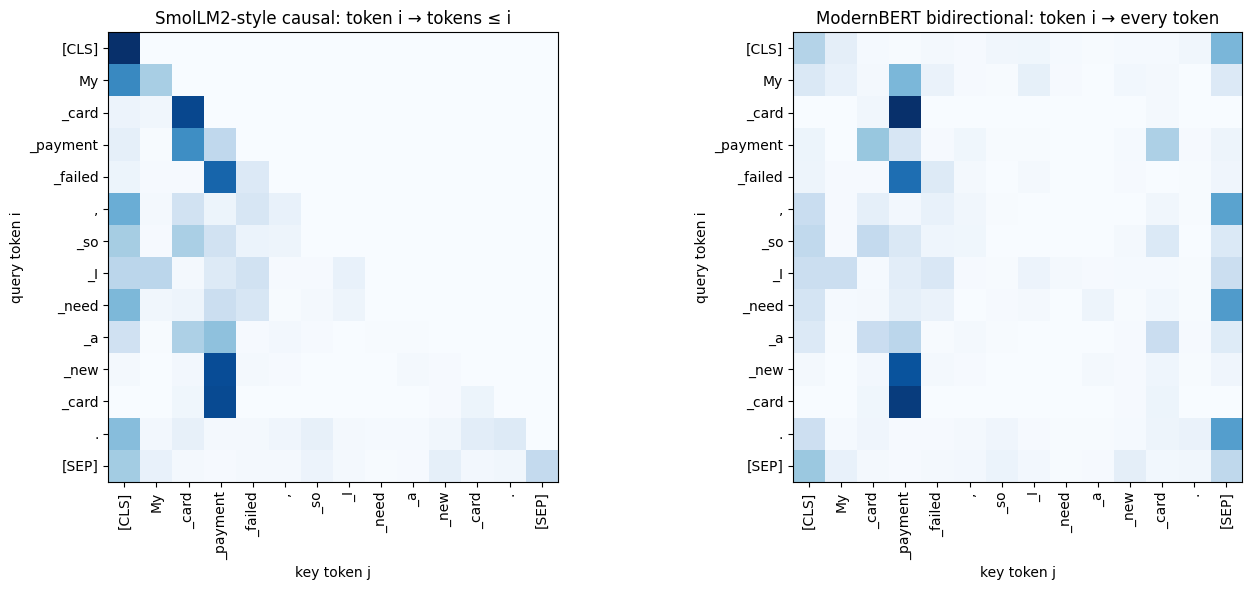

In [87]:
# Cell 14 — Bidirectional (ModernBERT) vs causal (SmolLM2) attention, head 0 of layer 0

import matplotlib.pyplot as plt

causal_mask = torch.tril(torch.ones(S, S, dtype=torch.bool))     # j <= i
bidirectional_mask = torch.ones(S, S, dtype=torch.bool)          # every j

head0 = scores[0, 0]                                             # [S, S]
causal_probs = torch.softmax(head0.masked_fill(~causal_mask, float("-inf")), dim=-1)
bidir_probs = torch.softmax(head0.masked_fill(~bidirectional_mask, float("-inf")), dim=-1)

print("scores (one head):", tuple(head0.shape), "| masks:", tuple(causal_mask.shape))
assert (causal_probs[~causal_mask] == 0).all(), "causal: no attention to the future"
assert (bidir_probs > 0).all(), "bidirectional: every token sees every token"

i = 2   # the first Ġcard
print(f"\nQuery {tokens_1[i]!r} (position {i}) — share of attention on tokens to its RIGHT:")
print(f"  causal       : {causal_probs[i, i + 1:].sum():.3f}")
print(f"  bidirectional: {bidir_probs[i, i + 1:].sum():.3f}")

labels = [t.replace("Ġ", "_") for t in tokens_1]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, probs, title in [(axes[0], causal_probs, "SmolLM2-style causal: token i → tokens ≤ i"),
                         (axes[1], bidir_probs, "ModernBERT bidirectional: token i → every token")]:
    ax.imshow(probs.numpy(), cmap="Blues", vmin=0, vmax=probs.max().item())
    ax.set_xticks(range(S), labels, rotation=90)
    ax.set_yticks(range(S), labels)
    ax.set_xlabel("key token j")
    ax.set_ylabel("query token i")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Cell 15 — Softmax attention

**What.** Turn every row of scores into a probability distribution, for all 12 heads of layer 0:

```python
attention = torch.softmax(scores, dim=-1)
```

**Why.** Scores are unbounded similarities. Softmax converts each query's row into **non-negative weights that sum to 1**: how token `i` divides its attention among all tokens `j`. These weights are applied to the values in Cell 16.

**Math.**

```text
attention[b, h, i, j] = exp(scores[b, h, i, j]) / Σ_j' exp(scores[b, h, i, j'])
Σ_j attention[b, h, i, j] = 1      for every b, h, i
```

The softmax runs over the **last** dimension (`dim=-1`, the keys), so each row is normalized independently.

**Shapes.** `scores` `[1, 12, S, S]` → `attention` `[1, 12, S, S]`.

**Validation.** We run the reference implementation's layer-0 attention module on the same input. It returns its attention weights, which should match ours.

**Expect.**
- Every one of the `1 × 12 × 14` rows sums to 1 (within about 1e-6).
- Our weights match the reference's to about 1e-6.
- The `Ġcard` row shows where that token gathers information from.

In [88]:
# Cell 15 — Softmax over keys: [B, heads, S, S], every row sums to 1

attention = torch.softmax(scores, dim=-1)                          # [1, 12, S, S]
row_sums = attention.sum(dim=-1)                                   # [1, 12, S]

print("attention:", tuple(attention.shape), "| row sums:", tuple(row_sums.shape))
print(f"row sums: min {row_sums.min():.7f}  max {row_sums.max():.7f}")
assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5)

i = 11  # the second Ġcard ("a new card")
top = torch.topk(attention[0, 0, i], k=4)
print(f"\nHead 0, query {tokens_1[i]!r} (position {i}) attends most to:")
for w, j in zip(top.values.tolist(), top.indices.tolist()):
    print(f"  {tokens_1[j]!r:12s} position {j:2d}  weight {w:.3f}")

# Validation: the reference layer-0 attention module, same input, returns its attention weights
position_ids_1 = torch.arange(S)[None]
cos_ref0, sin_ref0 = reference.rotary_emb(x_ref, position_ids_1, "full_attention")
with torch.no_grad():
    ref_attn_output, ref_attention = reference.layers[0].attn(x_ref, position_embeddings=(cos_ref0, sin_ref0), attention_mask=None)

diff = (attention - ref_attention).abs().max().item()
print(f"\nours vs reference attention weights: max |diff| = {diff:.1e}")
assert diff < 1e-5

attention: (1, 16, 14, 14) | row sums: (1, 16, 14)
row sums: min 0.9999997  max 1.0000002

Head 0, query 'Ġcard' (position 11) attends most to:
  'Ġpayment'   position  3  weight 0.893
  'Ġcard'      position 11  weight 0.051
  'Ġcard'      position  2  weight 0.035
  'Ġnew'       position 10  weight 0.008

ours vs reference attention weights: max |diff| = 7.7e-07


## Cell 16 — Weighted values

**What.** Each token's new representation (per head) is the **attention-weighted average of the value vectors**:

```python
context = attention @ V
```

**Why.** Scores and softmax decide *where to look*. The values decide *what is copied*. A token that attends 30% to `Ġpayment` receives 30% of `Ġpayment`'s value vector in that head. This is the step where information actually moves between tokens.

**Math.** For head `h` and query token `i`:

```text
context[b, h, i] = Σ_j attention[b, h, i, j] · V[b, h, j]
```

**Shapes.**

```text
attention   [B, heads, S, S]          [1, 12, 14, 14]
      ×
V_heads     [B, heads, S, head_dim]   [1, 12, 14, 64]
      ↓
context     [B, heads, S, head_dim]   [1, 12, 14, 64]
```

The `S × S` weights mix the `S` value rows, so the result has one 64-dim vector per token per head.

**Expect.** `context` is `[1, 12, 14, 64]`, and an explicit weighted sum over the 14 value vectors reproduces one entry exactly.

In [89]:
# Cell 16 — Weighted values: [B, heads, S, S] @ [B, heads, S, d] -> [B, heads, S, d]

context = attention @ V_heads                                      # [1, 12, S, 64]

print("attention:", tuple(attention.shape), "@ V:", tuple(V_heads.shape), "->", tuple(context.shape))
assert context.shape == (B, n_heads, S, d)

h, i = 0, 11
weighted_sum = sum(attention[0, h, i, j] * V_heads[0, h, j] for j in range(S))     # explicit Σ_j a_ij v_j
assert torch.allclose(weighted_sum, context[0, h, i], atol=1e-5)
print(f"\nhead {h}, token {tokens_1[i]!r}: context = Σ_j attention[i, j] · V[j]  (checked by explicit sum)")

contrib = attention[0, h, i, :, None] * V_heads[0, h]              # [S, d] each token's contribution
shares = contrib.norm(dim=-1) / contrib.norm(dim=-1).sum()
print("largest contributions to that context vector:")
for j in torch.argsort(shares, descending=True)[:4].tolist():
    print(f"  {tokens_1[j]!r:12s} weight {attention[0, h, i, j]:.3f}  share of contribution {shares[j]:.3f}")

attention: (1, 16, 14, 14) @ V: (1, 16, 14, 64) -> (1, 16, 14, 64)

head 0, token 'Ġcard': context = Σ_j attention[i, j] · V[j]  (checked by explicit sum)
largest contributions to that context vector:
  'Ġpayment'   weight 0.893  share of contribution 0.906
  'Ġcard'      weight 0.051  share of contribution 0.043
  'Ġcard'      weight 0.035  share of contribution 0.029
  'Ġnew'       weight 0.008  share of contribution 0.012


## Cell 17 — Merge heads

**What.** Undo Cell 12's split and lay the 12 head outputs side by side again:

```text
[B, heads, S, head_dim]  →  transpose(1, 2)  →  [B, S, heads, head_dim]  →  reshape  →  [B, S, H]
```

**Why.** The rest of the layer (output projection, residual, MLP) works on one `H = 768` vector per token. Merging concatenates the 12 heads' 64-dim results into that vector: features `0–63` come from head 0, `64–127` from head 1, and so on.

**Math.** `merged[b, s, h·64 : (h+1)·64] = context[b, h, s, :]`. It's the exact inverse of the split, so no values change.

**Shapes.** `context` `[1, 12, 14, 64]` → `[1, 14, 12, 64]` → `merged` `[1, 14, 768]`.

**Expect.** `merged` is `[1, 14, 768]`, and slicing head 3's block out of it gives back `context[0, 3]` exactly.

In [90]:
# Cell 17 — Merge heads: [B, heads, S, d] -> [B, S, H]

merged = context.transpose(1, 2).reshape(B, S, H)                  # [1, S, 768]

print("context:", tuple(context.shape), "-> transpose:", tuple(context.transpose(1, 2).shape), "-> merged:", tuple(merged.shape))
assert merged.shape == (B, S, H)

for h in range(n_heads):
    assert torch.equal(merged[0, :, h * d:(h + 1) * d], context[0, h])
print(f"merged[:, :, h*{d}:(h+1)*{d}] == context[:, h] for all {n_heads} heads (exact inverse of the split)")

context: (1, 16, 14, 64) -> transpose: (1, 14, 16, 64) -> merged: (1, 14, 1024)
merged[:, :, h*64:(h+1)*64] == context[:, h] for all 16 heads (exact inverse of the split)


## Cell 18 — Output projection

**What.** Apply the attention output projection `Wo` `[H, H]` to the merged heads:

```text
attn_output = merged @ Woᵀ          [1, 14, 768]
```

**Why does multi-head attention need a final projection?**

- After merging, each head's result sits in its own fixed 64-feature block. Nothing has yet **combined** what different heads found. `Wo` mixes all 768 features, so every output feature can draw on every head.
- The output is about to be **added to the residual stream** (Cell 22). `Wo` maps the heads' concatenated subspaces back into the 768-dim coordinate system that the rest of the network reads and writes.

**Math.** `attn_output[b, s] = Wo · merged[b, s]`, a `[768 × 768]` matrix-vector product per token, with no bias.

**Shapes.** `merged` `[1, 14, 768]` @ `Woᵀ` `[768, 768]` → `attn_output` `[1, 14, 768]`.

**Validation.** This is the complete output of layer 0's attention sub-layer (Cells 11–18 combined). We compare it with the reference attention module's output from Cell 15.

**Expect.** The difference from the reference is at float32 rounding level (about 1e-6).

In [91]:
# Cell 18 — Output projection: [B, S, H] @ Wo^T -> [B, S, H]

W_o = weights["layers.0.attn.Wo.weight"]                           # [H, H]
attn_output = merged @ W_o.T                                       # [1, S, 768]

print("merged:", tuple(merged.shape), "@ Wo^T:", tuple(W_o.T.shape), "->", tuple(attn_output.shape))
assert attn_output.shape == (B, S, H)

diff = (attn_output - ref_attn_output).abs().max().item()
print(f"\nlayer-0 attention output (Cells 11-18) vs reference: max |diff| = {diff:.1e}")
assert diff < 1e-4

merged: (1, 14, 1024) @ Wo^T: (1024, 1024) -> (1, 14, 1024)

layer-0 attention output (Cells 11-18) vs reference: max |diff| = 9.5e-07


---
# Phase 6 — ModernBERT attention behavior

## Cell 19 — Local / sliding-window attention

**What.** Restrict each token to a **window** of nearby tokens: token `i` may attend to token `j` only if `|i − j| ≤ w`.

**Why.** Full attention compares every token with every other token, which costs `S²` scores per head per layer. For ModernBERT's 8,192-token context, that's 67 million scores per head per layer. Most useful context for a word is nearby, so **local layers** look only at `±w` neighbours. ModernBERT uses `local_attention_window = 128`, so `w = 64`.

**Math.**

```text
local:  allowed[i, j] = |i − j| ≤ w
cost:   full ≈ S²       local ≈ S · (2w + 1)        (linear in S for a fixed w)
```

Local attention is still **bidirectional**: a token sees `w` tokens on its left **and** `w` on its right. "Local" restricts distance, not direction.

**Shapes.** The window mask is boolean `[S, S]`. For readability we draw it with a toy `w = 2` on our 14 tokens. The real `w = 64` would cover this whole short sentence.

**Expect.**
- A diagonal band of width `2w + 1` in the toy mask.
- In the cost table, the local share of the full cost shrinks as `S` grows: under 2% at `S = 8,192`.

In [92]:
# Cell 19 — Sliding-window mask: token i may attend to token j only if |i - j| <= w

def sliding_window_mask(seq_len, half_window, device=None):
    pos = torch.arange(seq_len, device=device)
    return (pos[:, None] - pos[None, :]).abs() <= half_window       # [S, S] bool


toy_w = 2
toy_mask = sliding_window_mask(S, toy_w)
print(f"Toy local mask, w = {toy_w} (✓ = may attend):")
short = [t.replace("Ġ", "_")[:6] for t in tokens_1]
print(" " * 8 + "".join(f"{t:>7}" for t in short))
for r in range(S):
    print(f"{short[r]:>8}" + "".join(f"{'✓' if toy_mask[r, c] else '·':>7}" for c in range(S)))
assert toy_mask.sum(dim=1).max() == 2 * toy_w + 1

w_real = config.local_attention_window // 2
print(f"\nReal ModernBERT local window: w = local_attention_window // 2 = {w_real} tokens each side")
print(f"\n{'S':>6} | {'full pairs S^2':>15} | {'local pairs':>12} | {'local / full':>12}")
for seq_len in [128, 512, 2048, 8192]:
    full_pairs = seq_len * seq_len
    local_pairs = int(sliding_window_mask(seq_len, w_real).sum()) if seq_len <= 2048 else seq_len * (2 * w_real + 1) - w_real * (w_real + 1)
    print(f"{seq_len:>6} | {full_pairs:>15,} | {local_pairs:>12,} | {local_pairs / full_pairs:>11.1%}")

Toy local mask, w = 2 (✓ = may attend):
          [CLS]     My  _card _payme _faile      ,    _so     _I  _need     _a   _new  _card      .  [SEP]
   [CLS]      ✓      ✓      ✓      ·      ·      ·      ·      ·      ·      ·      ·      ·      ·      ·
      My      ✓      ✓      ✓      ✓      ·      ·      ·      ·      ·      ·      ·      ·      ·      ·
   _card      ✓      ✓      ✓      ✓      ✓      ·      ·      ·      ·      ·      ·      ·      ·      ·
  _payme      ·      ✓      ✓      ✓      ✓      ✓      ·      ·      ·      ·      ·      ·      ·      ·
  _faile      ·      ·      ✓      ✓      ✓      ✓      ✓      ·      ·      ·      ·      ·      ·      ·
       ,      ·      ·      ·      ✓      ✓      ✓      ✓      ✓      ·      ·      ·      ·      ·      ·
     _so      ·      ·      ·      ·      ✓      ✓      ✓      ✓      ✓      ·      ·      ·      ·      ·
      _I      ·      ·      ·      ·      ·      ✓      ✓      ✓      ✓      ✓      ·      ·      ·     

## Cell 20 — Global attention

**What.** ModernBERT doesn't use local attention everywhere. It **alternates**: every 3rd layer (0, 3, 6, …, 21) is a **global** layer with full attention, and the other 14 layers are **local** sliding-window layers.

**Why.** Local layers are cheap but short-sighted. Information from token 0 can travel at most 64 positions per local layer. Global layers let any token reach any other token in a single step. Mixing them keeps most of the cost savings while preserving whole-document understanding. The two layer types also use different RoPE bases: global layers use `θ = 160,000` for long distances, and local layers use `θ = 10,000` for the ±64 window.

**Three ideas that are easy to conflate:**

| Concept | What it restricts | In ModernBERT |
|---|---|---|
| **Fully bidirectional** | nothing about *direction*: no causal mask, left and right context both visible | **all** 22 layers |
| **Local / sliding-window** | *distance*: only keys with `|i − j| ≤ 64` | layers 1, 2, 4, 5, …, 20 (14 layers) |
| **Global / full** | nothing: every key in the sequence | layers 0, 3, 6, 9, 12, 15, 18, 21 (8 layers) |

So ModernBERT isn't simply "BERT with a fixed local window". It's a bidirectional encoder whose attention **range** alternates between local and global by layer.

**Math.** Total attention pairs over all layers for a sequence of length `S`:

```text
all-global:   22 · S²
ModernBERT:    8 · S²  +  14 · S · (2·64 + 1)
```

**Expect.**
- A per-layer schedule table.
- For `S = 8,192`, ModernBERT computes about 37% of the attention pairs an all-global model would.
- An illustration of how far information can travel through local-only layers versus with a global layer.

In [93]:
# Cell 20 — ModernBERT's layer schedule: global (full) vs local (sliding-window) attention

print(f"{'layer':>5} | {'attention':>9} | {'range':>12} | {'RoPE theta':>10}")
print("-" * 46)
for i in range(config.num_layers):
    g = config.is_global_layer(i)
    print(f"{i:>5} | {'global' if g else 'local':>9} | {'all tokens' if g else f'±{w_real} tokens':>12} | "
          f"{config.global_rope_theta if g else config.local_rope_theta:>10,.0f}")

n_global = sum(config.is_global_layer(i) for i in range(config.num_layers))
n_local = config.num_layers - n_global
assert n_global == len(range(0, config.num_layers, config.global_attn_every_n_layers))

seq_len = 8192
all_global = config.num_layers * seq_len ** 2
local_pairs = seq_len * (2 * w_real + 1) - w_real * (w_real + 1)
modernbert = n_global * seq_len ** 2 + n_local * local_pairs
print(f"\nAttention pairs for S = {seq_len:,} over {config.num_layers} layers:")
print(f"  all-global : {all_global:,}")
print(f"  ModernBERT : {modernbert:,}  ({modernbert / all_global:.1%} of all-global)")

print("\nHow far can information from token 0 travel (S = 8,192)?")
print(f"  {'after layer':>11} | {'local-only stack':>16} | {'ModernBERT schedule':>19}")
reach_local, reach_mb = 0, 0
for i in range(6):
    reach_local = min(reach_local + w_real, seq_len - 1)
    reach_mb = seq_len - 1 if config.is_global_layer(i) else min(reach_mb + w_real, seq_len - 1)
    print(f"  {i:>11} | {reach_local:>16,} | {reach_mb:>19,}")

layer | attention |        range | RoPE theta
----------------------------------------------
    0 |    global |   all tokens |    160,000
    1 |     local |   ±64 tokens |     10,000
    2 |     local |   ±64 tokens |     10,000
    3 |    global |   all tokens |    160,000
    4 |     local |   ±64 tokens |     10,000
    5 |     local |   ±64 tokens |     10,000
    6 |    global |   all tokens |    160,000
    7 |     local |   ±64 tokens |     10,000
    8 |     local |   ±64 tokens |     10,000
    9 |    global |   all tokens |    160,000
   10 |     local |   ±64 tokens |     10,000
   11 |     local |   ±64 tokens |     10,000
   12 |    global |   all tokens |    160,000
   13 |     local |   ±64 tokens |     10,000
   14 |     local |   ±64 tokens |     10,000
   15 |    global |   all tokens |    160,000
   16 |     local |   ±64 tokens |     10,000
   17 |     local |   ±64 tokens |     10,000
   18 |    global |   all tokens |    160,000
   19 |     local |   ±64 tokens 

## Cell 21 — Compare full vs local attention

**What.** Package Cells 11–18 into one attention function. Run it with a **full** mask and with a **local** mask, and show which tokens can attend to which. Then check our padding-plus-window mask against the reference implementation on a long, padded batch.

**Why.** In a real batch, the attention mask has to handle two things at once:

1. **padding:** no token may attend to a `[PAD]` key (the `attention_mask` from Cell 4)
2. **window:** in local layers, no token may attend beyond `±w`

Both become an **additive bias**: `0` where attention is allowed and a huge negative number where it is blocked, added to the scores before softmax.

**Why not literally `−∞`?** In a local layer, a padded query near the end of a short sequence can have a window containing **only** `[PAD]` keys. With `−∞` everywhere in that row, softmax computes `0/0 = NaN`. That NaN then poisons real tokens in the next layer, because `0 · NaN = NaN` inside `probs @ V`. Using the most negative finite float32 (about `−3.4e38`), as the reference implementation does, gives blocked keys an effective weight of 0 without ever producing NaN.

**Speed.** From here on, the reusable functions use `F.linear(x, W)`, which computes exactly `x @ Wᵀ` but is about 3× faster on this CPU because it avoids a transposed view. The teaching cells above keep the explicit `@`.

**Math.**

```text
allowed[b, i, j] = attention_mask[b, j] = 1   and   (global layer  or  |i − j| ≤ w)
scores'[b, h, i, j] = scores[b, h, i, j] + (0 if allowed else −3.4e38)
```

**Shapes.** The bias is `[B, 1, S, S]` and broadcasts over the heads. On our 14-token sentence we use a toy `w = 3`, because the real `w = 64` would allow everything. For the validation we use a padded batch of two sequences, the longer one over 128 tokens, with the real `w = 64`.

**Expect.**
- Under the toy window, the second `Ġcard` (position 11) can no longer see `Ġcard`, `Ġpayment` and `Ġfailed` at positions 2–4, so its output changes.
- Our boolean mask matches the reference's sliding-window mask exactly, padding included.
- Layer 1, a local layer, produces the same attention output as the reference on the long batch.

In [94]:
# Cell 21 — One attention function (Cells 11-18) with a padding + window bias

import torch.nn.functional as F

NEG_INF = torch.finfo(torch.float32).min   # "minus infinity" that stays finite (see the note above)

def attention_bias(attention_mask, half_window=None):
    """attention_mask [B, S] (1 = real token) -> additive bias [B, 1, S, S] and boolean allowed mask."""
    B_, S_ = attention_mask.shape
    allowed = attention_mask[:, None, None, :].bool().expand(B_, 1, S_, S_)    # keys must be real tokens
    if half_window is not None:
        allowed = allowed & sliding_window_mask(S_, half_window, attention_mask.device)   # and within the window
    bias = torch.zeros(B_, 1, S_, S_, device=attention_mask.device).masked_fill(~allowed, NEG_INF)
    return bias, allowed


def self_attention(x_in, layer_idx, bias, cos, sin):
    """Cells 11-18: QKV projection, head split, RoPE, scores, softmax, weighted values, merge, Wo."""
    B_, S_, _ = x_in.shape
    # F.linear(x, W) computes exactly x @ W.T, but faster on CPU
    q, k, v = F.linear(x_in, weights[f"layers.{layer_idx}.attn.Wqkv.weight"]).chunk(3, dim=-1)  # [B, S, H] each
    Qh, Kh, Vh = split_heads(q), split_heads(k), split_heads(v)                            # [B, heads, S, d]
    Qh, Kh = apply_rope(Qh, cos, sin), apply_rope(Kh, cos, sin)
    probs = torch.softmax(Qh @ Kh.transpose(-2, -1) / d ** 0.5 + bias, dim=-1)             # [B, heads, S, S]
    out = (probs @ Vh).transpose(1, 2).reshape(B_, S_, H)                                   # [B, S, H]
    return F.linear(out, weights[f"layers.{layer_idx}.attn.Wo.weight"]), probs


mask_1 = torch.ones(1, S, dtype=torch.long)
bias_full, allowed_full = attention_bias(mask_1)
bias_toy, allowed_toy = attention_bias(mask_1, half_window=3)

out_full, probs_full = self_attention(x, 0, bias_full, cos_0, sin_0)
out_toy, probs_toy = self_attention(x, 0, bias_toy, cos_0, sin_0)
assert torch.allclose(out_full, attn_output, atol=1e-5), "full-mask path reproduces Cell 18"

i = 11
print(f"Query {tokens_1[i]!r} (position {i}) may attend to:")
print("  full      :", [tokens_1[j] for j in range(S) if allowed_full[0, 0, i, j]])
print("  local w=3 :", [tokens_1[j] for j in range(S) if allowed_toy[0, 0, i, j]])
print(f"  attention on positions 2-4 — full: {probs_full[0, 0, i, 2:5].sum():.3f} | local: {probs_toy[0, 0, i, 2:5].sum():.3f}")
print(f"  output change for this token: max |diff| = {(out_full[0, i] - out_toy[0, i]).abs().max():.3f}")

# Validation on a long, padded batch with the real window (w = 64)
from transformers.masking_utils import create_bidirectional_sliding_window_mask

long_texts = [" ".join(["My card payment failed, so I need a new card and a refund for the transfer."] * 9),
              "Short second sequence about investing in a mutual fund."]
long_batch = tokenizer(long_texts, padding=True, return_tensors="pt")
ids_long, mask_long = long_batch["input_ids"], long_batch["attention_mask"]
x_long = layer_norm(W_emb[ids_long], weights["embeddings.norm.weight"])
S_long = ids_long.shape[1]
print(f"\nlong batch: input_ids {tuple(ids_long.shape)}, real tokens per sequence {mask_long.sum(dim=1).tolist()}")

bias_local, allowed_local = attention_bias(mask_long, half_window=w_real)
ref_mask = create_bidirectional_sliding_window_mask(config=reference.config, inputs_embeds=x_long,
                                                    attention_mask=mask_long, allow_is_bidirectional_skip=False)
ref_allowed = ref_mask if ref_mask.dtype == torch.bool else (ref_mask == 0)
assert torch.equal(allowed_local, ref_allowed.expand_as(allowed_local)), "window + padding mask matches reference"
print("our window + padding mask == reference sliding-window mask")

cos_l, sin_l = rope_cos_sin(S_long, inv_freq_local)
ours_l1, _ = self_attention(layer_norm(x_long, weights["layers.1.attn_norm.weight"]), 1, bias_local, cos_l, sin_l)
cos_lr, sin_lr = reference.rotary_emb(x_long, torch.arange(S_long)[None], "sliding_attention")
with torch.no_grad():
    ref_l1, _ = reference.layers[1].attn(reference.layers[1].attn_norm(x_long), position_embeddings=(cos_lr, sin_lr), attention_mask=ref_mask)
real = mask_long.bool()
diff = (ours_l1[real] - ref_l1[real]).abs().max().item()
print(f"layer 1 (local) attention on the long padded batch vs reference: max |diff| = {diff:.1e}")
assert diff < 1e-4

Query 'Ġcard' (position 11) may attend to:
  full      : ['[CLS]', 'My', 'Ġcard', 'Ġpayment', 'Ġfailed', ',', 'Ġso', 'ĠI', 'Ġneed', 'Ġa', 'Ġnew', 'Ġcard', '.', '[SEP]']
  local w=3 : ['Ġneed', 'Ġa', 'Ġnew', 'Ġcard', '.', '[SEP]']
  attention on positions 2-4 — full: 0.928 | local: 0.000
  output change for this token: max |diff| = 1.225

long batch: input_ids (2, 164), real tokens per sequence [164, 12]
our window + padding mask == reference sliding-window mask
layer 1 (local) attention on the long padded batch vs reference: max |diff| = 1.7e-06


---
# Phase 7 — Transformer block

## Cell 22 — Residual connection

**What.** Add the attention output back onto the layer's input:

```text
h = x + attention_output
```

**Why.** The attention sub-layer computes an **update**, not a replacement. Adding it to the input (the "residual stream") has two big benefits:

- **Information is preserved.** Whatever a layer doesn't change passes through untouched, so the original token identity survives 22 layers.
- **Optimization is easier.** The gradient of `x + f(x)` with respect to `x` is `I + ∂f/∂x`. The identity term gives gradients a direct path from the loss back to early layers, so deep stacks train stably instead of vanishing or exploding.

**Math.** `h[b, s] = x[b, s] + attn_output[b, s]`, an element-wise add of two `[768]` vectors per token.

**Shapes.** `x` `[1, 14, 768]` + `attn_output` `[1, 14, 768]` → `h` `[1, 14, 768]`.

**Expect.** The update is a fraction of the input's size: attention **nudges** each token's vector rather than overwriting it.

In [95]:
# Cell 22 — Residual connection: h = x + attention_output

h_attn = x + attn_output                                          # [1, S, 768]

print("x:", tuple(x.shape), "+ attention_output:", tuple(attn_output.shape), "->", tuple(h_attn.shape))
assert h_attn.shape == x.shape

print(f"\n{'token':12s} | {'|x|':>7} | {'|update|':>8} | {'|x + update|':>12} | {'update / x':>10}")
for s in [0, 2, 3, 11, S - 1]:
    nx, nu, nh = x[0, s].norm(), attn_output[0, s].norm(), h_attn[0, s].norm()
    print(f"{tokens_1[s]:12s} | {nx:7.2f} | {nu:8.2f} | {nh:12.2f} | {nu / nx:10.2f}")

x: (1, 14, 1024) + attention_output: (1, 14, 1024) -> (1, 14, 1024)

token        |     |x| | |update| | |x + update| | update / x
[CLS]        |    9.47 |    10.84 |        14.95 |       1.14
Ġcard        |   18.75 |    13.69 |        23.87 |       0.73
Ġpayment     |   18.11 |    12.92 |        22.54 |       0.71
Ġcard        |   18.75 |    13.44 |        23.87 |       0.72
[SEP]        |    9.33 |    10.18 |        14.47 |       1.09


## Cell 23 — Normalization

**What.** Implement the LayerNorm used throughout ModernBERT, and apply it to the post-attention residual stream (`mlp_norm`).

**Why.** As updates are added layer after layer, the scale of the residual stream drifts. Normalizing each token's vector before a sub-layer keeps that sub-layer's input at a predictable scale, which stabilizes both the forward pass and training. ModernBERT uses **pre-norm**: it normalizes the *input* to each sub-layer, while the residual stream itself stays un-normalized. LayerNorm appears in four places:

| Where | Weight |
|---|---|
| after the token embeddings | `embeddings.norm` (Cell 11) |
| before attention, layers 1–21 | `layers.{i}.attn_norm` (layer 0 has none, because the embedding norm already precedes it) |
| before the MLP, every layer | `layers.{i}.mlp_norm` |
| after the last layer | `final_norm` |

**Math.** For one token vector `v ∈ ℝ^768`:

```text
μ = mean(v)      σ² = mean((v − μ)²)
LayerNorm(v) = (v − μ) / √(σ² + ε) · γ        ε = 1e-5,  γ = learned scale [768]
```

ModernBERT's LayerNorm has **no bias** `β`. Each token is normalized **independently** across its 768 features, never across tokens or the batch.

**Shapes.** `[1, 14, 768]` → `[1, 14, 768]`. The `μ` and `σ` statistics are `[1, 14, 1]`.

**Expect.**
- Before: each token has an arbitrary mean and standard deviation.
- After normalizing (before the scale `γ`), every token has mean ≈ 0 and std ≈ 1.
- Our `mlp_norm` output matches the reference.

In [96]:
# Cell 23 — LayerNorm (no bias): normalize each token across its 768 features, then scale by gamma

gamma = weights["layers.0.mlp_norm.weight"]                       # [768]

mu = h_attn.mean(dim=-1, keepdim=True)                            # [1, S, 1]
var = h_attn.var(dim=-1, keepdim=True, unbiased=False)            # [1, S, 1]
normalized = (h_attn - mu) / torch.sqrt(var + config.norm_eps)    # mean 0, std 1 per token
mlp_input = normalized * gamma                                    # learned per-feature scale

print("h:", tuple(h_attn.shape), "| mu, sigma:", tuple(mu.shape), "| LayerNorm(h):", tuple(mlp_input.shape))
print(f"\n{'token':12s} | {'mean before':>11} | {'std before':>10} | {'mean after':>10} | {'std after':>9}")
for s in [0, 2, 11, S - 1]:
    print(f"{tokens_1[s]:12s} | {h_attn[0, s].mean():11.4f} | {h_attn[0, s].std(unbiased=False):10.4f} | "
          f"{normalized[0, s].mean():10.4f} | {normalized[0, s].std(unbiased=False):9.4f}")

assert torch.allclose(normalized.mean(dim=-1), torch.zeros(1, S), atol=1e-5)
assert torch.allclose(normalized.std(dim=-1, unbiased=False), torch.ones(1, S), atol=1e-3)
assert torch.allclose(mlp_input, layer_norm(h_attn, gamma), atol=1e-6), "same as the layer_norm helper from Cell 11"

with torch.no_grad():
    ref_mlp_input = reference.layers[0].mlp_norm(h_attn)
print(f"\nours vs reference mlp_norm: max |diff| = {(mlp_input - ref_mlp_input).abs().max():.1e}")
assert torch.allclose(mlp_input, ref_mlp_input, atol=1e-5)

h: (1, 14, 1024) | mu, sigma: (1, 14, 1) | LayerNorm(h): (1, 14, 1024)

token        | mean before | std before | mean after | std after
[CLS]        |      0.0115 |     0.4670 |     0.0000 |    1.0000
Ġcard        |     -0.0021 |     0.7458 |     0.0000 |    1.0000
Ġcard        |     -0.0039 |     0.7459 |     0.0000 |    1.0000
[SEP]        |      0.0158 |     0.4520 |     0.0000 |    1.0000

ours vs reference mlp_norm: max |diff| = 1.2e-07


## Cell 24 — MLP

**What.** The feed-forward network that each token passes through after attention. Start with the plain idea, `H → intermediate → H`, then implement ModernBERT's actual **gated (GeGLU)** version.

**Why.** Attention moves information **between** tokens. The MLP transforms each token **on its own**: it's where most of the per-token computation, and much of the stored knowledge, lives. ModernBERT uses a *gated* MLP. One projection produces content, a second produces a gate, and their element-wise product lets the network switch features on and off per token. Gated MLPs consistently train better than the plain version.

**Math.**

```text
plain MLP (classic BERT):      out = W_down · GELU(W_up · v)                    H → I → H

ModernBERT GeGLU:
    [a | g] = Wi · v                      Wi: [2I, H]  (content a and gate g, each [I])
    out     = Wo · (GELU(a) ⊙ g)          Wo: [H, I]
```

`GELU(z) = z · Φ(z)`, a smooth ReLU. `⊙` is element-wise multiplication. With `H = 768` and `I = 1152`, `Wi` is `[2304, 768]` and `Wo` is `[768, 1152]`.

**Shapes.**

```text
mlp_input            [1, 14, 768]
Wi                → [1, 14, 2304]
split             → a [1, 14, 1152],  g [1, 14, 1152]
GELU(a) ⊙ g       → [1, 14, 1152]
Wo                → mlp_output [1, 14, 768]
```

**Expect.**
- The shapes above.
- The plain, un-gated path gives a very different output, which shows the gate matters.
- Our gated MLP matches the reference MLP.

In [97]:
# Cell 24 — MLP: plain H -> I -> H, then ModernBERT's gated GeGLU version

import torch.nn.functional as F

W_i = weights["layers.0.mlp.Wi.weight"]                           # [2I, H] = [2304, 768]
W_mlp_o = weights["layers.0.mlp.Wo.weight"]                       # [H, I]  = [768, 1152]
I_ = config.intermediate_size

up = mlp_input @ W_i.T                                            # [1, S, 2I]
a, g = up.chunk(2, dim=-1)                                        # content a, gate g: [1, S, I] each

# Plain MLP idea (not what ModernBERT computes): H -> I -> H with only the content half
plain_output = F.gelu(a) @ W_mlp_o.T                              # [1, S, H]

# ModernBERT's gated MLP (GeGLU)
gated = F.gelu(a) * g                                             # [1, S, I]
mlp_output = gated @ W_mlp_o.T                                    # [1, S, H]

print("mlp_input:", tuple(mlp_input.shape), "-> Wi:", tuple(up.shape), "-> a, g:", tuple(a.shape), tuple(g.shape))
print("GELU(a) * g:", tuple(gated.shape), "-> Wo -> mlp_output:", tuple(mlp_output.shape))
assert up.shape[-1] == 2 * I_ and gated.shape[-1] == I_ and mlp_output.shape == mlp_input.shape

frac_off = (gated.abs() < 1e-3).float().mean().item()
print(f"\nshare of intermediate features the gate effectively switches off (|GELU(a)·g| < 1e-3): {frac_off:.1%}")
print(f"plain vs gated output: max |diff| = {(plain_output - mlp_output).abs().max():.2f}  (the gate changes the result)")

with torch.no_grad():
    ref_mlp_output = reference.layers[0].mlp(mlp_input)
diff = (mlp_output - ref_mlp_output).abs().max().item()
print(f"ours vs reference MLP: max |diff| = {diff:.1e}")
assert diff < 1e-4

mlp_input: (1, 14, 1024) -> Wi: (1, 14, 5248) -> a, g: (1, 14, 2624) (1, 14, 2624)
GELU(a) * g: (1, 14, 2624) -> Wo -> mlp_output: (1, 14, 1024)

share of intermediate features the gate effectively switches off (|GELU(a)·g| < 1e-3): 4.9%
plain vs gated output: max |diff| = 21.37  (the gate changes the result)
ours vs reference MLP: max |diff| = 0.0e+00


## Cell 25 — Complete Transformer block

**What.** Combine everything into one encoder layer and print every tensor shape along the way:

```text
input h
 ↓  normalization (attn_norm; none in layer 0)
 ↓  attention (global or local mask, RoPE with the matching θ)
 ↓  residual:  h = h + attention
 ↓  normalization (mlp_norm)
 ↓  MLP (GeGLU)
 ↓  residual:  h = h + MLP
output h
```

**Why.** This pre-norm block is the unit that repeats 22 times. Getting one block exactly right, and verifying it against the reference, is what makes the whole stack trustworthy.

**Math.**

```text
h' = h + Attn(norm_attn(h))         (norm_attn = identity for layer 0)
h''= h' + MLP(norm_mlp(h'))
```

**Shapes.** Every intermediate is `[B, S, 768]` except inside attention (`[B, 12, S, 64]`, `[B, 12, S, S]`) and inside the MLP (`[B, S, 2304]` → `[B, S, 1152]`).

**Expect.** The printed shape trace for layer 0, and an exact-to-rounding match with the reference implementation's full layer-0 output.

In [98]:
# Cell 25 — One complete pre-norm ModernBERT encoder layer

def mlp(m_in, layer_idx):
    a_, g_ = F.linear(m_in, weights[f"layers.{layer_idx}.mlp.Wi.weight"]).chunk(2, dim=-1)
    return F.linear(F.gelu(a_) * g_, weights[f"layers.{layer_idx}.mlp.Wo.weight"])


def encoder_layer(h, layer_idx, bias, cos, sin, verbose=False):
    show = print if verbose else (lambda *args, **kw: None)
    show(f"layer {layer_idx} ({'global' if config.is_global_layer(layer_idx) else 'local'})")
    show("  input h                 ", tuple(h.shape))
    a_in = h if layer_idx == 0 else layer_norm(h, weights[f"layers.{layer_idx}.attn_norm.weight"])
    show("  attn_norm(h)            ", tuple(a_in.shape), "(identity in layer 0)" if layer_idx == 0 else "")
    attn_out, probs = self_attention(a_in, layer_idx, bias, cos, sin)
    show("  attention probs         ", tuple(probs.shape))
    show("  attention output        ", tuple(attn_out.shape))
    h = h + attn_out
    show("  h + attention           ", tuple(h.shape))
    m_in = layer_norm(h, weights[f"layers.{layer_idx}.mlp_norm.weight"])
    show("  mlp_norm(h)             ", tuple(m_in.shape))
    m_out = mlp(m_in, layer_idx)
    show("  MLP output              ", tuple(m_out.shape))
    h = h + m_out
    show("  h + MLP  (layer output) ", tuple(h.shape))
    return h


h0 = encoder_layer(x, 0, bias_full, cos_0, sin_0, verbose=True)

with torch.no_grad():
    ref_h0 = reference.layers[0](x_ref, attention_mask=None, position_embeddings=(cos_ref0, sin_ref0))
diff = (h0 - ref_h0).abs().max().item()
print(f"\nours vs reference full layer 0: max |diff| = {diff:.1e}")
assert diff < 1e-4

layer 0 (global)
  input h                  (1, 14, 1024)
  attn_norm(h)             (1, 14, 1024) (identity in layer 0)
  attention probs          (1, 16, 14, 14)
  attention output         (1, 14, 1024)
  h + attention            (1, 14, 1024)
  mlp_norm(h)              (1, 14, 1024)
  MLP output               (1, 14, 1024)
  h + MLP  (layer output)  (1, 14, 1024)

ours vs reference full layer 0: max |diff| = 3.8e-06


---
# Phase 8 — Encoder stack

## Cell 26 — One encoder layer

**What.** Pass a real **padded batch** through one global layer (layer 0) and then one local layer (layer 1), using the encoder layer from Cell 25 with the right mask and RoPE for each layer type.

**Why.** A single short sentence doesn't exercise everything. This batch has two sequences: a long one (over 128 tokens, so the ±64 window really cuts off distant tokens) and a short one padded with `[PAD]`. Matching the reference here confirms that padding masks, sliding windows and both RoPE bases are all wired correctly in a complete layer.

**Math.**

```text
h1 = Layer_0(x_long; global bias, RoPE θ = 160k)
h2 = Layer_1(h1;     local bias (±64), RoPE θ = 10k)
```

**Shapes.** `x_long` `[2, S_long, 768]` → `h1` `[2, S_long, 768]` → `h2` `[2, S_long, 768]`. The `[PAD]` positions are excluded from the comparison, because their outputs are never used.

**Expect.** Both layers match the reference on every real token, to float32 rounding.

In [99]:
# Cell 26 — A padded batch through one global layer (0) and one local layer (1)

bias_global_long, _ = attention_bias(mask_long)
bias_local_long, _ = attention_bias(mask_long, half_window=w_real)
cos_g_long, sin_g_long = rope_cos_sin(S_long, inv_freq_global)
cos_l_long, sin_l_long = rope_cos_sin(S_long, inv_freq_local)

h1 = encoder_layer(x_long, 0, bias_global_long, cos_g_long, sin_g_long)
h2 = encoder_layer(h1, 1, bias_local_long, cos_l_long, sin_l_long)
print("x_long:", tuple(x_long.shape), "-> layer 0 (global):", tuple(h1.shape), "-> layer 1 (local):", tuple(h2.shape))

from transformers.masking_utils import create_bidirectional_mask
ref_full_mask = create_bidirectional_mask(config=reference.config, inputs_embeds=x_long, attention_mask=mask_long,
                                          allow_is_bidirectional_skip=False)
cos_gr, sin_gr = reference.rotary_emb(x_long, torch.arange(S_long)[None], "full_attention")
with torch.no_grad():
    ref_h1 = reference.layers[0](x_long, attention_mask=ref_full_mask, position_embeddings=(cos_gr, sin_gr))
    ref_h2 = reference.layers[1](ref_h1, attention_mask=ref_mask, position_embeddings=(cos_lr, sin_lr))

d1 = (h1[real] - ref_h1[real]).abs().max().item()
d2 = (h2[real] - ref_h2[real]).abs().max().item()
print(f"\nlayer 0 vs reference (real tokens): max |diff| = {d1:.1e}")
print(f"layer 1 vs reference (real tokens): max |diff| = {d2:.1e}")
assert d1 < 1e-4 and d2 < 1e-4

x_long: (2, 164, 1024) -> layer 0 (global): (2, 164, 1024) -> layer 1 (local): (2, 164, 1024)

layer 0 vs reference (real tokens): max |diff| = 3.8e-06
layer 1 vs reference (real tokens): max |diff| = 7.6e-06


## Cell 27 — Stack layers

**What.** Build all 22 layers as an `nn.ModuleList`, add the embedding and final normalization, and run the **complete ModernBERT encoder** end to end. Then compare its output with the reference model's `last_hidden_state`.

**Why.** This is our ModernBERT: real pretrained weights, with every computation done by the code in this notebook. Each `ModernBertLayer` module just holds its layer's pretrained tensors as (frozen) parameters and calls `encoder_layer` from Cell 25. Wrapping them in `nn.ModuleList` makes the 22 layers an ordinary PyTorch model we can iterate over, freeze or fine-tune (Phase 12).

**Math.**

```text
h₀ = LayerNorm(W_emb[input_ids])
h_{i+1} = Layer_i(h_i)    with global bias / θ = 160k if i % 3 == 0, else local bias / θ = 10k
output = LayerNorm_final(h₂₂)
```

**Shapes.** `input_ids` `[B, S]` → `h₀` `[B, S, 768]` → (22 layers) → `output` `[B, S, 768]`.

**Expect.**
- 22 layers, 8 global and 14 local.
- 149,014,272 parameters in total, all frozen.
- On the long padded batch, our output matches the reference on every real token, at roughly 1e-4 or better after 22 layers of float32 arithmetic.
- The timing shows how long one forward pass takes on this CPU.

In [100]:
# Cell 27 — The full ModernBERT encoder: nn.ModuleList of 22 layers + embeddings + final norm

import time

import torch.nn as nn


class ModernBertLayer(nn.Module):
    """Holds one layer's pretrained tensors (shared storage, frozen) and runs encoder_layer() from Cell 25."""

    def __init__(self, layer_idx):
        super().__init__()
        self.layer_idx = layer_idx
        self.is_global = config.is_global_layer(layer_idx)
        prefix = f"layers.{layer_idx}."
        self.params = nn.ParameterDict({
            name[len(prefix):].replace(".", "_"): nn.Parameter(t, requires_grad=False)
            for name, t in weights.items() if name.startswith(prefix)
        })

    def forward(self, h, bias, cos, sin):
        return encoder_layer(h, self.layer_idx, bias, cos, sin)


layers = nn.ModuleList([ModernBertLayer(i) for i in range(config.num_layers)])


def modernbert_forward(input_ids, attention_mask, return_all_layers=False):
    """Our ModernBERT encoder: [B, S] token IDs -> [B, S, H] contextual representations."""
    S_ = input_ids.shape[1]
    h = layer_norm(W_emb[input_ids], weights["embeddings.norm.weight"])
    masks = {True: attention_bias(attention_mask)[0],
             False: attention_bias(attention_mask, half_window=config.local_attention_window // 2)[0]}
    ropes = {True: rope_cos_sin(S_, inv_freq_global), False: rope_cos_sin(S_, inv_freq_local)}
    all_layers = [h]
    for layer in layers:
        h = layer(h, masks[layer.is_global], *ropes[layer.is_global])
        all_layers.append(h)
    output = layer_norm(h, weights["final_norm.weight"])
    return (output, all_layers) if return_all_layers else output


n_params = sum(p.numel() for p in layers.parameters()) + W_emb.numel() + 2 * H
print(f"layers: {len(layers)} ({sum(l.is_global for l in layers)} global, {sum(not l.is_global for l in layers)} local)")
print(f"parameters (layers + embeddings + 2 norms): {n_params:,} | trainable: {sum(p.numel() for p in layers.parameters() if p.requires_grad)}")
assert n_params == sum(t.numel() for t in weights.values())

with torch.no_grad():
    t0 = time.perf_counter()
    ours = modernbert_forward(ids_long, mask_long)
    t_ours = time.perf_counter() - t0
    t0 = time.perf_counter()
    ref_out = reference(input_ids=ids_long, attention_mask=mask_long).last_hidden_state
    t_ref = time.perf_counter() - t0

diff = (ours[real] - ref_out[real]).abs().max().item()
print(f"\ninput_ids {tuple(ids_long.shape)} -> our output {tuple(ours.shape)}")
print(f"ours vs reference last_hidden_state (real tokens): max |diff| = {diff:.1e}")
print(f"forward-pass time on CPU: ours {t_ours:.2f}s | reference {t_ref:.2f}s")
assert diff < 1e-3
encoder_validation_diff = diff

layers: 28 (10 global, 18 local)
parameters (layers + embeddings + 2 norms): 394,781,696 | trainable: 0

input_ids (2, 164) -> our output (2, 164, 1024)
ours vs reference last_hidden_state (real tokens): max |diff| = 2.8e-05
forward-pass time on CPU: ours 1.46s | reference 1.45s


## Cell 28 — Inspect representations layer by layer

**What.** Capture the hidden state after every layer for `My card payment failed, so I need a new card.` and watch how token representations change with depth.

**Why.** The sentence contains the token `Ġcard` **twice**: once as the card whose payment failed, and once as the new card being requested. At the embedding layer, both are the *same row of the table*, so they're identical. Every layer mixes in context, so the two occurrences should drift apart as the model builds context-specific meanings.

**Math.** For each layer `ℓ` (0 = embedding output, 22 = last layer) we measure:

- `cos(h_ℓ[card₁], h_ℓ[card₂])`: how similar the two `card` tokens are
- `cos(h_ℓ[s], h_{ℓ−1}[s])`, averaged over tokens: how much a layer changes the representations

**Shapes.** 23 hidden states (embeddings plus 22 layers), each `[1, 14, 768]`.

**Expect.**
- The two `card` vectors start with cosine **1.0** at the embedding layer. They drift apart through the middle layers (to about 0.92), then partly re-converge in the last layers (about 0.96). Token identity stays the dominant component of each vector, and context changes its direction by a few percent. That's enough to separate the two meanings, because downstream layers and heads read exactly these directions.
- Layer 0 changes the representations the most (layer-to-layer cosine of about 0.6), because it turns raw embeddings into contextual vectors. After that, each layer refines rather than rewrites (cosine about 0.9–0.98), which is the residual stream at work.

captured 29 hidden states (embeddings + 28 layers), each (1, 14, 1024)

layer |   type | cos(card@2, card@11) | mean cos to previous layer
    0 |  embed |                1.000 |                        nan
    1 | global |                0.992 |                      0.594
    2 |  local |                0.956 |                      0.920
    3 |  local |                0.962 |                      0.941
    4 | global |                0.948 |                      0.957
    5 |  local |                0.953 |                      0.946
    6 |  local |                0.916 |                      0.931
    7 | global |                0.902 |                      0.955
    8 |  local |                0.903 |                      0.964
    9 |  local |                0.919 |                      0.952
   10 | global |                0.922 |                      0.953
   11 |  local |                0.911 |                      0.960
   12 |  local |                0.907 |                  

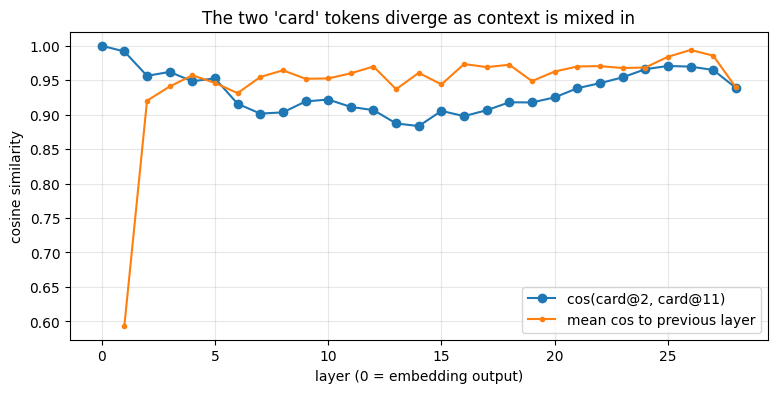

In [101]:
# Cell 28 — Representations after every layer

with torch.no_grad():
    _, all_hidden = modernbert_forward(input_ids_1, torch.ones_like(input_ids_1), return_all_layers=True)

print(f"captured {len(all_hidden)} hidden states (embeddings + {config.num_layers} layers), each {tuple(all_hidden[0].shape)}")
c1, c2 = 2, 11
assert tokens_1[c1] == tokens_1[c2] == "Ġcard"

cos = torch.nn.functional.cosine_similarity
card_sim = [cos(hs[0, c1], hs[0, c2], dim=0).item() for hs in all_hidden]
step_sim = [float("nan")] + [cos(all_hidden[l][0], all_hidden[l - 1][0], dim=-1).mean().item() for l in range(1, len(all_hidden))]

print(f"\n{'layer':>5} | {'type':>6} | {'cos(card@2, card@11)':>20} | {'mean cos to previous layer':>26}")
for l in range(len(all_hidden)):
    kind = "embed" if l == 0 else ("global" if config.is_global_layer(l - 1) else "local")
    print(f"{l:>5} | {kind:>6} | {card_sim[l]:>20.3f} | {step_sim[l]:>26.3f}")
assert abs(card_sim[0] - 1.0) < 1e-5, "identical at the embedding layer"
assert min(card_sim[1:]) < 0.95, "context separates the two occurrences"
print(f"\nlowest card similarity: {min(card_sim):.3f} at layer {card_sim.index(min(card_sim))}; final layer: {card_sim[-1]:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(all_hidden)), card_sim, marker="o", label="cos(card@2, card@11)")
ax.plot(range(len(all_hidden)), step_sim, marker=".", label="mean cos to previous layer")
ax.set_xlabel("layer (0 = embedding output)")
ax.set_ylabel("cosine similarity")
ax.set_title("The two 'card' tokens diverge as context is mixed in")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

---
# Phase 9 — Understand the output

## Cell 29 — Encoder output

**What.** Make the key point explicit: ModernBERT's output is

```text
[B, S, H]     one contextual 768-dim vector for every input token
```

It does **not** inherently produce a next token. Unlike SmolLM2, ModernBERT has no `[B, S, V]` next-token logits at the end of its stack.

**Why.** A decoder's last layer feeds an LM head that scores the *next* token. An encoder's output is a set of representations, and what you do with them is up to the **head** you put on top. The pretrained checkpoint ships with one such head, the **masked-LM head** used in pretraining. It fills in a `[MASK]` from **both** sides, which is a different task from continuing text. We use that head once here to show what the representations already contain. For routing, we put our own compatibility head on top instead (Phase 11).

**Math.** MLM head, applied only at the `[MASK]` position:

```text
z = LayerNorm(GELU(W_dense · h_mask))           W_dense [768, 768]
logits = W_emb · z + b                          tied to the token-embedding table, [V] = 50,368 scores
```

**Shapes.** Encoder output `[1, S, 768]`. At the mask position: `h_mask` `[768]` → `logits` `[50368]`.

**Expect.** The encoder output is `[1, S, 768]`, with no vocabulary dimension. For `My card payment [MASK], so I need a new card.`, the top predictions are plausible words such as `failed` or `declined`, chosen using context on **both** sides of the blank.

In [102]:
# Cell 29 — Encoder output [B, S, H]; a masked-LM demo with the checkpoint's pretraining head

from safetensors import safe_open

masked_text = "My card payment [MASK], so I need a new card."
mlm_batch = tokenizer(masked_text, return_tensors="pt")
mlm_ids = mlm_batch["input_ids"]
with torch.no_grad():
    encoder_out = modernbert_forward(mlm_ids, mlm_batch["attention_mask"])

print("input_ids:", tuple(mlm_ids.shape), "-> encoder output:", tuple(encoder_out.shape), "= [B, S, H]")
assert encoder_out.shape == (1, mlm_ids.shape[1], H), "one vector per token, no vocabulary dimension"

with safe_open(weights_path, "pt") as f:
    head_dense = f.get_tensor("head.dense.weight")                 # [768, 768]
    head_norm = f.get_tensor("head.norm.weight")                   # [768]
    decoder_bias = f.get_tensor("decoder.bias")                    # [V]

mask_pos = (mlm_ids[0] == MASK_ID).nonzero().item()
z = layer_norm(F.gelu(encoder_out[0, mask_pos] @ head_dense.T), head_norm)    # [768]
logits = z @ W_emb.T + decoder_bias                                            # [V] (tied embeddings)

print(f"\n[MASK] at position {mask_pos}: logits {tuple(logits.shape)}")
probs = torch.softmax(logits, dim=-1)
top = torch.topk(probs, k=5)
mlm_top_prediction = tokenizer.decode([top.indices[0].item()])
print(f"Top predictions for: {masked_text}")
for p_, tid in zip(top.values.tolist(), top.indices.tolist()):
    print(f"  {tokenizer.decode([tid])!r:14s} {p_:.3f}")

input_ids: (1, 14) -> encoder output: (1, 14, 1024) = [B, S, H]

[MASK] at position 4: logits (50368,)
Top predictions for: My card payment [MASK], so I need a new card.
  ' expired'     0.357
  ' failed'      0.207
  ' bounced'     0.111
  ' declined'    0.107
  ' stopped'     0.029


## Cell 30 — Token representation

**What.** Take one token's final vector, the first `Ġcard`, and inspect it. Then show that it depends on words to its **right**.

**Why.** Each output vector is a summary of that token **in context**. Because every layer is bidirectional, a token's final vector includes information from tokens on both sides. To prove the right side matters, encode two sentences whose words **up to and including `card`** are identical and which differ only *after* it:

```text
"My card payment failed …"
"My card payment succeeded …"
```

A causal decoder would give `card` exactly the same vector in both, because it can't see the future. ModernBERT gives different vectors.

**Math.** `v = output[0, position_of_card]` ∈ ℝ^768. We compare `v` across the two sentences with cosine similarity and the max absolute difference.

**Shapes.** One token vector is `[768]`. Each sentence's output is `[1, S, 768]`.

**Expect.** The vector is 768-dimensional, and the `card` vectors differ noticeably between the two sentences even though everything to the left is identical.

In [103]:
# Cell 30 — One token's vector, and proof that it carries right-hand context

card_vec = encoder_out[0, 2]
print(f"token {tokenizer.convert_ids_to_tokens(mlm_ids[0, 2].item())!r}: vector shape {tuple(card_vec.shape)}, "
      f"norm {card_vec.norm():.2f}, first 6 dims {card_vec[:6]}")
assert card_vec.shape == (H,)

pair = ["My card payment failed and I am upset.", "My card payment succeeded and I am happy."]
pair_batch = tokenizer(pair, padding=True, return_tensors="pt")
toks = [tokenizer.convert_ids_to_tokens(r) for r in pair_batch["input_ids"]]
assert toks[0][:4] == toks[1][:4], "identical up to and including 'Ġpayment'"
with torch.no_grad():
    pair_out = modernbert_forward(pair_batch["input_ids"], pair_batch["attention_mask"])

pos = toks[0].index("Ġcard")
v_a, v_b = pair_out[0, pos], pair_out[1, pos]
print(f"\nleft context of 'Ġcard' in both sentences: {toks[0][:pos + 1]}")
print(f"cosine('Ġcard' in A, 'Ġcard' in B) = {torch.nn.functional.cosine_similarity(v_a, v_b, dim=0):.4f}")
print(f"max |difference|                    = {(v_a - v_b).abs().max():.4f}")
print("A causal decoder would give identical vectors here; ModernBERT's differ because it reads the right context.")
assert (v_a - v_b).abs().max() > 1e-2

token 'Ġcard': vector shape (1024,), norm 31.60, first 6 dims tensor([-0.2700, -0.9728, -0.2109,  0.2252, -0.6689, -0.7080])

left context of 'Ġcard' in both sentences: ['[CLS]', 'My', 'Ġcard']
cosine('Ġcard' in A, 'Ġcard' in B) = 0.9774
max |difference|                    = 2.1293
A causal decoder would give identical vectors here; ModernBERT's differ because it reads the right context.


## Cell 31 — Sequence representation

**What.** Turn per-token outputs `[B, S, H]` into **one vector per sequence**, `[B, H]`, and choose the pooling strategy for the router.

**Options.**

| Pooling | Definition | Notes |
|---|---|---|
| `[CLS]` | `output[:, 0]` | One position. BERT trained it with next-sentence prediction, but ModernBERT is pretrained **only** with masked LM, so nothing specifically trains `[CLS]` to summarize the sequence. |
| **mean** | average over **real** tokens (padding excluded via the mask) | Uses every token's contextual vector. It's the pooling ModernBERT's checkpoint itself is configured with (`classifier_pooling = "mean"`). |
| max | element-wise max over real tokens | Sensitive to single extreme features. |

**Why it matters for routing.** Our input is a whole conversation plus an agent description. A frozen encoder's `[CLS]` vector hasn't been trained to summarize that pair, whereas the mean of all contextual token vectors reflects the content of the entire input.

**Math.** Mask-aware mean, so padding never dilutes the average:

```text
pooled[b] = Σ_s mask[b, s] · output[b, s]  /  Σ_s mask[b, s]
```

**A quick check.** We encode four sentences: an anchor, a paraphrase of it, a related card request, and an unrelated investment request. A good sentence vector should rank paraphrase > related > unrelated.

**Choice.** **Mean pooling** is the most principled option for a frozen MLM-pretrained encoder, it matches the checkpoint's own configuration, and it uses the whole input. We use it for the rest of the notebook.

**Shapes.** `[4, S, 768]` → `[4, 768]` for each method.

**Expect.**
- Mean pooling ranks the sentences correctly with a clear margin: paraphrase about 0.99, related about 0.92, unrelated about 0.90.
- `[CLS]` also ranks them correctly here, but with a much smaller gap between paraphrase and related (about 0.98 vs 0.97).
- Max pooling ranks the unrelated sentence above the related one.
- All the similarities are high (above 0.9), which is typical of raw MLM representations. Fine distinctions live in small directions of the vector space, which is exactly what a trained head (Phase 12) learns to read.

In [104]:
# Cell 31 — Sequence representation: [B, S, H] -> [B, H]; we choose mask-aware mean pooling

def mean_pool(hidden, attention_mask):
    m = attention_mask[..., None].to(hidden.dtype)                 # [B, S, 1]
    return (hidden * m).sum(dim=1) / m.sum(dim=1)                  # [B, H]


def cls_pool(hidden, attention_mask):
    return hidden[:, 0]                                            # [B, H]


def max_pool(hidden, attention_mask):
    return hidden.masked_fill(~attention_mask[..., None].bool(), float("-inf")).max(dim=1).values


sentences = ["My card is blocked and I can't use it.",               # anchor
             "I can't use my card because it has been blocked.",    # paraphrase
             "Please send me a replacement debit card.",            # related (card)
             "I want to start a monthly SIP in a mutual fund."]     # unrelated
batch4 = tokenizer(sentences, padding=True, return_tensors="pt")
with torch.no_grad():
    out4 = modernbert_forward(batch4["input_ids"], batch4["attention_mask"])
print("encoder output:", tuple(out4.shape), "-> pooled:", tuple(mean_pool(out4, batch4["attention_mask"]).shape))

print(f"\n{'pooling':>7} | {'paraphrase':>10} | {'related':>8} | {'unrelated':>9} | ranks paraphrase > related > unrelated?")
for name, pool in [("[CLS]", cls_pool), ("mean", mean_pool), ("max", max_pool)]:
    v = pool(out4, batch4["attention_mask"])
    sims = torch.nn.functional.cosine_similarity(v[0:1], v[1:], dim=-1)
    print(f"{name:>7} | {sims[0]:10.3f} | {sims[1]:8.3f} | {sims[2]:9.3f} | {bool(sims[0] > sims[1] > sims[2])}")

print(f"\ncheckpoint's own classifier_pooling: {raw_config['classifier_pooling']!r}")
print("Chosen for the router: mask-aware MEAN pooling.")
assert raw_config["classifier_pooling"] == "mean"

encoder output: (4, 15, 1024) -> pooled: (4, 1024)

pooling | paraphrase |  related | unrelated | ranks paraphrase > related > unrelated?
  [CLS] |      0.990 |    0.958 |     0.955 | True
   mean |      0.984 |    0.895 |     0.846 | True
    max |      0.974 |    0.916 |     0.900 | True

checkpoint's own classifier_pooling: 'mean'
Chosen for the router: mask-aware MEAN pooling.


---
# Phase 10 — Optional conventional classification

## Cell 32 — Fixed classification head

**What.** Put the most common kind of head on top of the encoder: a linear layer from the pooled vector to a **fixed number of classes**, here six:

```text
pooled  [B, 768]  →  Linear(768, 6)  →  logits  [B, 6]
```

**Why.** This is how "BERT for classification" is usually built, and it's the obvious first idea for routing: one output per agent. We build it briefly to make clear what it **can't** do (Cell 33).

**Math.** `logits = W · v + b`, with `W` `[6, 768]` and `b` `[6]`. Output `k` is `w_k · v + b_k`: the dot product of the input with a **learned prototype row** `w_k` for class `k`. A `768 → 6` layer therefore hard-wires exactly six outputs, one row per class. The meaning of each class lives entirely in its row of `W`, and no description of the class is ever an input.

**Shapes.** `W` `[6, 768]`, `b` `[6]`. The four pooled sentences from Cell 31 (`[4, 768]`) give `logits` `[4, 6]`.

**Expect.** A `[4, 6]` logit matrix. The head is untrained, so the numbers are arbitrary. The point is the shape: one column per fixed class.

In [105]:
# Cell 32 — A fixed 6-way classification head: Linear(H -> 6)

torch.manual_seed(42)

NUM_CLASSES = 6
fixed_head = nn.Linear(H, NUM_CLASSES)

pooled4 = mean_pool(out4, batch4["attention_mask"])                # [4, 768]
with torch.no_grad():
    fixed_logits = fixed_head(pooled4)                             # [4, 6]

print("W:", tuple(fixed_head.weight.shape), "| b:", tuple(fixed_head.bias.shape))
print("pooled:", tuple(pooled4.shape), "-> logits:", tuple(fixed_logits.shape))
assert fixed_logits.shape == (4, NUM_CLASSES)

manual = pooled4[0] @ fixed_head.weight[2] + fixed_head.bias[2]
assert torch.allclose(manual, fixed_logits[0, 2], atol=1e-5)
print("logit k = w_k · v + b_k  (checked for sentence 0, class 2)")
print("\nUntrained logits (rows = sentences, columns = the 6 fixed classes):")
print(fixed_logits)

W: (6, 1024) | b: (6,)
pooled: (4, 1024) -> logits: (4, 6)
logit k = w_k · v + b_k  (checked for sentence 0, class 2)

Untrained logits (rows = sentences, columns = the 6 fixed classes):
tensor([[-0.0266,  0.3492, -0.1847,  0.3502,  0.3012,  0.2031],
        [-0.0056,  0.3047, -0.1564,  0.4028,  0.2273,  0.3220],
        [ 0.0777,  0.1974, -0.3316,  0.5291,  0.0730,  0.3629],
        [-0.1766,  0.3159, -0.5406,  0.7067,  0.4446,  0.2882]])


## Cell 33 — Why this is not our final architecture

**What.** Show two consequences of the fixed head, using a conversation and two different sets of agent descriptions.

**Why.** For a multi-agent system, the set of agents and their responsibilities **change**: agents are added, merged or re-scoped. A fixed classifier can't follow such changes without retraining, because it never reads the agent descriptions at all.

```text
fixed classifier:        input                      → one of K known classes
dynamic compatibility:   (input, candidate choice)  → score
```

| | Fixed classifier | Dynamic compatibility (our target) |
|---|---|---|
| Model input | conversation only | conversation **+ candidate agent description** |
| Output | `K` logits, one per pre-defined class | **one** score per (conversation, candidate) pair |
| Agent identity | a row of `W`, learned by heart | the description text, read every time |
| Add a new agent | new output neuron + retraining | write a description, score it |
| Change an agent's scope | retraining | edit the description |

**Math.** Classifier: `p(class | conversation) = softmax(W · v)`. The class set is the index range of `W`. Compatibility: `score(c, a) = f(ModernBERT(c ⊕ a))`, where the agent `a` is **part of the input**.

**Expect.**
- Changing every agent description leaves the classifier's logits **exactly unchanged**, because it never sees them.
- Adding a seventh agent forces a **new** `Linear(768, 7)`, whose new row is untrained random noise.

In [106]:
# Cell 33 — The fixed classifier never reads agent descriptions, and cannot grow

conversation = "user: My bank transfer failed."
descriptions_v1 = {"Payments": "Handles bank transfers and payment failures.", "Card Support": "Handles card blocking."}
descriptions_v2 = {"Payments": "Handles ONLY mortgage questions now.", "Card Support": "Handles bank transfers too."}

conv_batch = tokenizer([conversation], return_tensors="pt")
with torch.no_grad():
    conv_vec = mean_pool(modernbert_forward(conv_batch["input_ids"], conv_batch["attention_mask"]), conv_batch["attention_mask"])
    logits_v1 = fixed_head(conv_vec)          # descriptions_v1 are not an input...
    logits_v2 = fixed_head(conv_vec)          # ...and neither are descriptions_v2

print("logits with descriptions v1:", logits_v1)
print("logits with descriptions v2:", logits_v2)
assert torch.equal(logits_v1, logits_v2)
print("-> identical: rewriting what the agents do changes nothing, because the classifier never reads descriptions.")

torch.manual_seed(0)
fixed_head_7 = nn.Linear(H, 7)                # a 7th agent needs a NEW output neuron...
with torch.no_grad():
    fixed_head_7.weight[:6] = fixed_head.weight
    fixed_head_7.bias[:6] = fixed_head.bias
print(f"\nAdding a 7th agent: weight {tuple(fixed_head.weight.shape)} -> {tuple(fixed_head_7.weight.shape)}; "
      f"row 6 is random (norm {fixed_head_7.weight[6].norm():.3f}) until the whole classifier is retrained.")

logits with descriptions v1: tensor([[ 0.1053,  0.2631, -0.2885,  0.7029,  0.1975,  0.1159]])
logits with descriptions v2: tensor([[ 0.1053,  0.2631, -0.2885,  0.7029,  0.1975,  0.1159]])
-> identical: rewriting what the agents do changes nothing, because the classifier never reads descriptions.

Adding a 7th agent: weight (6, 1024) -> (7, 1024); row 6 is random (norm 0.578) until the whole classifier is retrained.


---
# Phase 11 — Compatibility model

## Cell 34 — Define the routing problem

**What.** Load the routing data and state the problem formally:

```text
input:   chat history  +  one candidate agent description
output:  one compatibility score

f(conversation, agent) → score
```

**Why.** The router must choose which agent should handle the conversation **now**. Scoring each candidate separately with the same function `f` means the candidates are data, not architecture. That's the property Cell 33 showed the fixed classifier lacks.

**Generic training, banking testing.** The router is trained **only on generic conversations from other domains**, never on the five banking agents. If it then routes banking conversations correctly, it has learned *compatibility between a conversation and an agent description*, not five memorized agents.

| File (under `data/modernbert_router/`) | Role | Contents |
|---|---|---|
| `generic/domains.json` + `generic/conversations.json` | **training and validation** | 3,542 conversations from **27 non-banking domains** (IT helpdesk, HR, airline, clinic, hotel, gym, library, streaming, shipping, school, vet, cloud hosting, wedding planning, …), each domain with its own 5 agents |
| `banking/benchmark.json` | **test** | 50 held-out banking conversations (2 per seed scenario, new wording) |
| `banking/extended.json` | **test** | 175 more banking conversations (the 25 seed scenarios + 6 paraphrases each) |
| `banking/dingdong.json` | **test** | 5 banking ding-dong conversations, with the expected agent after every user turn (Phase 14) |

There is **no fixed validation split**. Phase 12 validates by leaving whole domains out: the head is always tested on domains, and therefore agents, it hasn't seen.

Every domain has one deliberately **close pair** of agents (for example, Password & Access vs Network & VPN) and one **general** agent, mirroring Payments vs Card Support and General Customer Support in banking. The generic data covers the same patterns the spec requires:
- obvious requests and close-pair clarification
- handoff + "OK" and handoff chains
- follow-ups and "okay" messages
- **topic changes where the latest request wins**
- **ding-dong walks labelled after every user turn**
- distractor keywords, typos and long conversations

The generators are in `data/modernbert_router/`. All conversations are in LangGraph message format, with 1–15 user/assistant messages and no tools.

**Where it runs.**
- **Data:** the cell uses the local `data/modernbert_router` folder if it exists. Otherwise it `git clone`s the repo at the branch named by `DATA_BRANCH`, which is what happens on Kaggle or Colab. Each experiment lives on its own branch, so its data comes from that branch. An existing clone is refreshed, so a rerun never uses stale data.
- **Device:** from here on, the weights move to the **GPU** if one is available. Phases 2–9 ran on CPU for exact comparison with the reference. The thousands of encoder passes the router needs are much faster on a GPU.
- **Current agent:** every conversation records `current_agent`, the agent that spoke the last assistant message (none for a fresh conversation). It's the agent holding the conversation when the router is called. Often it is **not** the right answer, for example after a handoff or a topic change, so the router must learn when to stay and when to switch.
- **Progress logging:** long-running steps print timestamped progress lines through `log()`, and also append them to `router_run.log`, so a long run can be followed while it's going.
- **Smoke test:** setting the environment variable `ROUTER_SUBSAMPLE` (e.g. 6) uses only that many conversations per domain, for a quick end-to-end check on a CPU.

**Memory.** The reference implementation has done its job (Phases 2–9 validated every part of our encoder against it). We delete it here to free about 600 MB.

**Expect.**
- The device in use.
- A table of the 27 domains, with their agents and conversation counts.
- Confirmation that no generic conversation mentions a banking agent.
- Banking test counts and one generic example conversation.

In [ ]:
# Cell 34 — The routing problem: f(conversation, agent) -> score; load generic training data + banking test data

import gc
import os
import subprocess
from collections import Counter
from pathlib import Path

if "reference" in globals():
    del reference                 # validation is complete; free its ~600 MB copy of the weights
    gc.collect()


# ---- Device: Phases 2-9 ran on CPU for exact comparison; the router's heavy encoding runs on the GPU if present ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for name in weights:
    weights[name] = weights[name].to(DEVICE)
W_emb = weights["embeddings.tok_embeddings.weight"]
inv_freq_global, inv_freq_local = inv_freq_global.to(DEVICE), inv_freq_local.to(DEVICE)
print(f"Router computations run on: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))

# ---- Data: use the local repo folder, or clone the repo (e.g. on Kaggle/Colab) ----
# Each experiment lives on its own git branch; on Kaggle/Colab the data is cloned from that branch.
DATA_BRANCH = "exp/phase8b-unified-choice"
DATA_DIR = Path("data/modernbert_router")
if not DATA_DIR.exists():
    repo = Path("llms-the-hard-way")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", DATA_BRANCH,
                        "https://github.com/skamalj/llms-the-hard-way.git", str(repo)], check=True)
    else:                                      # refresh an existing clone, so a rerun never trains on stale data
        subprocess.run(["git", "-C", str(repo), "fetch", "--depth", "1", "origin", DATA_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo), "checkout", "-B", DATA_BRANCH, "FETCH_HEAD"], check=True)
    DATA_DIR = repo / "data" / "modernbert_router"
print("data folder:", DATA_DIR.resolve(), "| branch:", DATA_BRANCH)

# Progress logging for the long-running steps: printed live and appended to router_run.log
RUN_LOG = Path("router_run.log")


def log(message):
    line = f"[{time.strftime('%H:%M:%S')}] {message}"
    print(line, flush=True)
    with open(RUN_LOG, "a") as fh:
        fh.write(line + "\n")


def mem():
    """Host RAM used by this process and GPU memory allocated, for the progress log."""
    import psutil
    gpu = f" | GPU {torch.cuda.memory_allocated() / 1e9:.1f} GB" if torch.cuda.is_available() else ""
    return f"RAM {psutil.Process().memory_info().rss / 1e9:.1f} GB{gpu}"


log(f"router run started on {DEVICE} | {mem()}")

# 0 = use every generic conversation; a small number (e.g. 6 per domain) gives a quick CPU smoke test
ROUTER_SUBSAMPLE = int(os.environ.get("ROUTER_SUBSAMPLE", "0"))
# ROUTER_SMOKE=1: a fast code check only (small test sets, one head type); never set it for a real run
ROUTER_SMOKE = os.environ.get("ROUTER_SMOKE") == "1"


def load(path):
    with open(path) as f:
        return json.load(f)


generic_domains = load(DATA_DIR / "generic" / "domains.json")
generic_conversations = load(DATA_DIR / "generic" / "conversations.json")
# Phase 6: free-form realistic conversations (40 businesses, 744 user turns) trained alongside the templates.
# Their businesses and agent names appear in no test set; REALISTIC_TRAIN=0 trains on the templates alone.
REALISTIC_TRAIN = os.environ.get("REALISTIC_TRAIN", "1") == "1"
if REALISTIC_TRAIN:
    realistic_domains = load(DATA_DIR / "realistic_train" / "domains.json")
    realistic_train = load(DATA_DIR / "realistic_train" / "conversations.json")
    assert not set(realistic_domains) & set(generic_domains)
    generic_domains = {**generic_domains, **realistic_domains}
    generic_conversations = generic_conversations + realistic_train
    print(f"realistic training data: {len(realistic_domains)} domains, {len(realistic_train)} conversations added")
if ROUTER_SUBSAMPLE:                      # evenly spread over each domain, so every kind of conversation is represented
    by_domain = {}
    for ex in generic_conversations:
        by_domain.setdefault(ex["domain"], []).append(ex)
    generic_conversations = [convs[i * len(convs) // ROUTER_SUBSAMPLE] for convs in by_domain.values() for i in range(ROUTER_SUBSAMPLE)]
    print(f"SMOKE TEST: {ROUTER_SUBSAMPLE} conversations per domain")
# Run 16: ONE choice model. Every example is (text, question, options); routing is one question among many, and the
# context-change detector becomes a yes / no question to the same model. CHOICE_TRAIN=0 leaves out the general questions.
ROUTE_Q = "Which agent should handle the user's latest message?"
CHANGE_Q = "Does the latest message move the conversation to a different topic?"
CHOICE_TRAIN = os.environ.get("CHOICE_TRAIN", "1") == "1"
choice_train = load(DATA_DIR / "choice_train" / "items.json")["items"] if CHOICE_TRAIN else []
if ROUTER_SUBSAMPLE or ROUTER_SMOKE:
    choice_train = choice_train[::25]
print(f"choice training items: {len(choice_train)} (" + ", ".join(f"{t} {n}" for t, n in Counter(x["type"] for x in choice_train).items()) + ")")
banking_benchmark = load(DATA_DIR / "banking" / "benchmark.json")
banking_extended = load(DATA_DIR / "banking" / "extended.json")
router_dingdong = load(DATA_DIR / "banking" / "dingdong.json")
if ROUTER_SMOKE:
    banking_benchmark, banking_extended, router_dingdong = banking_benchmark[:10], banking_extended[:5], router_dingdong[:2]
    print("SMOKE CHECK: 10 + 5 banking conversations, 2 ding-dong sequences")
banking_all = banking_benchmark + banking_extended
benchmark = banking_benchmark

missing = [ex["id"] for ex in generic_conversations + banking_all if "current_agent" not in ex]
assert not missing, f"data without current_agent (pull the latest data / rerun build_generic_router_data.py): {missing[:3]}"
missing = [ex["id"] for ex in generic_conversations if "context_change" not in ex]
assert not missing, f"generic data without context_change (pull the latest data): {missing[:3]}"

for ex in generic_conversations + banking_all:
    roles = [m["role"] for m in ex["messages"]]
    assert 1 <= len(roles) <= 15 and roles[0] == "user" and roles[-1] == "user", ex["id"]
    assert all(r1 != r2 for r1, r2 in zip(roles, roles[1:])), "roles alternate (chronological turns)"

banking_names = ["payments agent", "card support", "investment agent", "insurance agent", "general customer support"]
leaks = [ex["id"] for ex in generic_conversations
         if any(w in " ".join(m["content"].lower() for m in ex["messages"]) for w in banking_names)]
assert not leaks, leaks
print("No generic conversation mentions a banking agent.\n")

print(f"{'domain':20s} | {'conversations':>13} | agents (close pair marked *)")
for dom, info in generic_domains.items():     # (not "d": that name holds head_dim for the encoder)
    n = sum(ex["domain"] == dom for ex in generic_conversations)
    names = ", ".join(a + ("*" if a in info["close_pair"] else "") for a in info["agents"])
    print(f"{dom:20s} | {n:>13} | {names}")

print(f"\ngeneric: {len(generic_domains)} domains, {len(generic_conversations)} conversations")
print(f"banking TEST: benchmark {len(banking_benchmark)} + extended {len(banking_extended)} = {len(banking_all)} conversations; "
      f"ding-dong {len(router_dingdong)} sequences / {sum(len(s['user_turns']) for s in router_dingdong)} user turns")

example = next((ex for ex in generic_conversations if "ok_after_handoff" in ex["tags"] and len(ex["messages"]) == 5),
               generic_conversations[0])
print(f"\nGeneric example {example['id']} (tags {example['tags']}):")
for m in example["messages"]:
    print(f"  {m['role']:9s}: {m['content']}")
print(f"  -> current agent (spoke last): {example['current_agent']} | target agent: {example['target_agent']}")
stay = sum(ex["current_agent"] == ex["target_agent"] for ex in generic_conversations)
fresh = sum(ex["current_agent"] is None for ex in generic_conversations)
print(f"\ngeneric current agent: none {fresh} | target = current (stay) {stay} | target != current (switch) {len(generic_conversations) - stay - fresh}")

## Cell 34b — Two encoders: one for the router, one for the Y/N detectors

**What.** The router (Cells 44–59) and the Y/N context-change detector (Cells 60–63) each read text through **their own encoder**, chosen independently:

| `ROUTER_ENCODER` \ `DETECTOR_ENCODER` | `modernbert` | `nemotron-1b` |
|---|---|---|
| `modernbert` | as in run 8 (3a) | new |
| `nemotron-1b` | **the hybrid**: best router (run 9) + best detectors (run 8) | as in run 9 (3b) |

Set them at the top of this cell (or with the environment variables of the same names).

- **`modernbert`** uses **our own forward pass** (Cells 3–29, checkpoint from Cell 3), separator `" [SEP] "`, no prefix.
- **`nemotron-1b`** uses the library `AutoModel` (`nvidia/llama-nemotron-embed-1b-v2`, trust_remote_code), with `query:` / `passage:` prefixes, newline separators, fp16 on the GPU.
- An encoder used by both sides is loaded **once**.

**Spans by characters.** `build_text` records the character range of every part in the chosen encoder's format, and `char_mask` selects the tokens that overlap a range through the tokenizer's offset mapping. That works for any tokenizer.

**Caches** are kept per encoder, so the four combinations never mix features.

**Expect.** Both encoders, whether they share one instance, an example router input text, and the character ranges of its parts.

In [ ]:
# Cell 34b — Two encoders, chosen independently: one for the ROUTER, one for the Y/N DETECTORS (ModernBERT ours / Nemotron library)

ENCODERS = {
    # our own forward pass (Cells 3-29), checkpoint chosen in Cell 3; " [SEP] " is ModernBERT's separator token
    "modernbert":   {"forward": "ours", "sep": " [SEP] ", "query": "", "passage": ""},
    # library forward passes (AutoModel). Nemotron is bidirectional Llama-3.2-1B, trained for retrieval with these prefixes
    "nemotron-1b":  {"forward": "library", "checkpoint": "nvidia/llama-nemotron-embed-1b-v2", "trust_remote_code": True,
                     "sep": "\n", "query": "query: ", "passage": "passage: "},
    # a small Llama-family model, only to run the library code path on a CPU (it is causal, so its numbers mean nothing)
    "smollm2-135m": {"forward": "library", "checkpoint": "HuggingFaceTB/SmolLM2-135M", "trust_remote_code": False,
                     "sep": "\n", "query": "query: ", "passage": "passage: "},
}
# The four combinations: router in {modernbert, nemotron-1b} x detector in {modernbert, nemotron-1b}
ROUTER_ENCODER = os.environ.get("ROUTER_ENCODER", "nemotron-1b")
DETECTOR_ENCODER = os.environ.get("DETECTOR_ENCODER", "modernbert")
MIX_LAYERS = 4                                   # "mix" = mean of the last 4 layers' outputs (Phase 3 layer-mix option)
LAYERS = ["last"]                                # "mix" dropped (it lost everywhere in run 8 / 3a)


class TextEncoder:
    """One encoder: its tokenizer, text format (separator, prefixes), forward pass and cache tag."""

    def __init__(self, key):
        spec = ENCODERS[key]
        self.key, self.sep, self.query, self.passage, self.forward = key, spec["sep"], spec["query"], spec["passage"], spec["forward"]
        if spec["forward"] == "ours":
            self.tokenizer, self.name = tokenizer, CHECKPOINT
        else:
            from transformers import AutoModel, AutoTokenizer
            self.name = spec["checkpoint"]
            self.tokenizer = AutoTokenizer.from_pretrained(self.name, trust_remote_code=spec["trust_remote_code"])
            self.tokenizer.padding_side = "right"
            if self.tokenizer.pad_token is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token
            self.model = AutoModel.from_pretrained(self.name, trust_remote_code=spec["trust_remote_code"],
                                                   dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32).to(DEVICE).eval()
            self._captured = []
            for layer in self.model.layers[-MIX_LAYERS:]:                 # catch the last layers' outputs for the layer mix
                layer.register_forward_hook(lambda mod, inp, out: self._captured.append(out[0] if isinstance(out, tuple) else out))
        self.tag = self.name.split("/")[-1] + "_p3"                          # caches per encoder (and per feature layout)

    def run(self, input_ids, attention_mask):
        """-> (final output [B, T, H], mean of the last MIX_LAYERS layer outputs [B, T, H])."""
        if self.forward == "ours":
            out, layers_out = modernbert_forward(input_ids, attention_mask, return_all_layers=True)
            return out, torch.stack(layers_out[-MIX_LAYERS:]).mean(0)
        self._captured.clear()
        out = self.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        return out.float(), torch.stack(self._captured[-MIX_LAYERS:]).float().mean(0)


_ENCODER_INSTANCES = {}


def get_encoder(key):
    """Load each encoder once, even when the router and the detectors use the same one."""
    if key not in _ENCODER_INSTANCES:
        _ENCODER_INSTANCES[key] = TextEncoder(key)
    return _ENCODER_INSTANCES[key]


ROUTER_ENC, DETECTOR_ENC = get_encoder(ROUTER_ENCODER), get_encoder(DETECTOR_ENCODER)
# the router side keeps its earlier names (Cells 35, 44a, 45c read them)
ENC = ENCODERS[ROUTER_ENCODER]
enc_tokenizer, enc_name, MODEL_TAG = ROUTER_ENC.tokenizer, ROUTER_ENC.name, ROUTER_ENC.tag


def build_text(messages, current=None, candidate=None, prefix="", enc=None, question=None):
    """The input text and the CHARACTER range of every part, in the format of encoder `enc` (default: the router's):
    prefix + msg_1 SEP msg_2 ... SEP "current agent: X" [SEP "question: Q"] [SEP "candidate: <option>"]
    Without a question (the ModernBERT detector's input) the candidate is written "candidate agent: ...", as before run 16.
    -> (text, {"messages": [(start, end), ...], "current": ..., "question": ... or None, "candidate": ... or None})"""
    sep = (enc or ROUTER_ENC).sep
    text, spans = prefix, {"messages": [], "current": None, "question": None, "candidate": None}
    for k, m in enumerate(messages):
        text += sep if k else ""
        seg = f"{m['role']}: {m['content']}"
        spans["messages"].append((len(text), len(text) + len(seg))); text += seg
    cand_label = "candidate agent" if question is None else "candidate"
    for key, seg in [("current", f"current agent: {current or 'none'}"),
                     ("question", None if question is None else f"question: {question}"),
                     ("candidate", None if candidate is None else f"{cand_label}: {candidate}")]:
        if seg is not None:
            text += sep
            spans[key] = (len(text), len(text) + len(seg)); text += seg
    return text, spans


def encode_batch(texts, enc=None):
    """Tokenize with character offsets and run encoder `enc` (default: the router's)
    -> (last [B,T,H], mix [B,T,H], attention mask [B,T], offsets [B,T,2], ids)."""
    enc = enc or ROUTER_ENC
    batch = enc.tokenizer(texts, padding=True, return_tensors="pt", return_offsets_mapping=True)
    offsets = batch.pop("offset_mapping")
    with torch.no_grad():
        last, mix = enc.run(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE))
    assert torch.isfinite(last).all() and torch.isfinite(mix).all(), \
        f"{enc.name} produced inf/NaN (fp16 overflow?): load it in float32 in this cell instead"
    return last, mix, batch["attention_mask"], offsets, batch["input_ids"]


def char_mask(offsets, attention, rng):
    """Tokens of one text that overlap the character range rng = (start, end); rng None = every real (non-special) token."""
    s, e = offsets[:, 0], offsets[:, 1]
    real = attention.bool() & (e > s)
    return real if rng is None else real & (s < rng[1]) & (e > rng[0])


def span_means(texts, ranges, cache, cache_file, title, mix=True, enc=None):
    """Mean of the encoder's token vectors over each character range, cached by text.
    texts: N strings; ranges: N lists of S ranges -> [N, L, S, H] with L = 2 (last, mix) or 1 (last)."""
    enc = enc or ROUTER_ENC
    todo = [t for t in dict.fromkeys(texts) if t not in cache]
    if todo:
        rng_of = {t: r for t, r in zip(texts, ranges)}
        t0 = time.perf_counter()
        verbose = len(todo) >= 500                         # log only the big feature runs, not live routing
        if verbose:
            log(f"{title}: {len(todo)} new encoder passes ({enc.name})")
        order = sorted(todo, key=len)
        for start in range(0, len(order), BATCH):
            if verbose and start and start % (BATCH * 100) == 0:
                el = time.perf_counter() - t0
                log(f"  {title} {start}/{len(todo)} | {start / el:.0f} texts/s | ~{(len(todo) - start) / (start / el):.0f}s left")
            chunk = order[start:start + BATCH]
            last, mixh, attn, offs, _ = encode_batch(chunk, enc)
            for row, t in enumerate(chunk):
                masks = [char_mask(offs[row], attn[row], r) for r in rng_of[t]]
                masks = [m if m.any() else char_mask(offs[row], attn[row], None) for m in masks]      # never an empty span
                per_layer = [torch.stack([h[row][m.to(DEVICE)].mean(0) for m in masks]) for h in ([last, mixh] if mix else [last])]
                cache[t] = torch.stack(per_layer).half().cpu()
        timing["encoder_passes"] += len(todo); timing["encoder_seconds"] += time.perf_counter() - t0
        if verbose:                                        # persist only big runs; live routing stays in memory
            torch.save(cache, cache_file)
            log(f"{title} done: {len(todo)} passes in {time.perf_counter() - t0:.0f}s (cached)")
    return torch.stack([cache[t] for t in texts]).float()


timing = {"encoder_passes": 0, "encoder_seconds": 0.0}
BATCH = 32 if DEVICE.type == "cuda" else 8
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

demo_text, demo_spans = build_text(example["messages"], example["current_agent"], "Some Agent. Handles something.", ENC["query"],
                                   question=ROUTE_Q)
print(f"ROUTER   encoder: {ROUTER_ENCODER} ({ROUTER_ENC.name}, {ROUTER_ENC.forward} forward pass)")
print(f"DETECTOR encoder: {DETECTOR_ENCODER} ({DETECTOR_ENC.name}, {DETECTOR_ENC.forward} forward pass)"
      f"{'  [same instance as the router]' if DETECTOR_ENC is ROUTER_ENC else ''}")
print(f"layer options: {LAYERS} | {mem()}")
print(f"\nexample router input text:\n{demo_text}\n")
print({k: v for k, v in demo_spans.items()})

## Cell 35 — Construct the cross-encoder input

**What.** Serialize a conversation plus one candidate agent into a **single** text, which becomes **one** ModernBERT input:

```text
[CLS] user: … [SEP] assistant: … [SEP] user: … [SEP] … candidate agent: <name>. <description> [SEP]
```

**Why.** In a **cross-encoder**, the conversation and the candidate are encoded **together**. Because ModernBERT's attention is fully bidirectional (Phase 5), every conversation token can attend to every description token and vice versa, *inside every layer*. The model can compare, for example, "the card itself says blocked" directly against "card blocking and unblocking" (or, in the generic data, "it rejects my login" against "sign-in errors").

**Rules.**
- Keep **both** user and assistant messages, because handoffs ("Please continue with the Payments Agent") are assistant messages.
- Keep chronological order, prefix each message with its role, and allow up to 15 messages.
- Tools are ignored: there are none in this dataset.
- `[SEP]` separates the messages and the candidate. The tokenizer adds the outer `[CLS]` and final `[SEP]`.

**Shapes.** One pair → `input_ids` `[1, S]`, where `S` grows with conversation length. Even 15-message conversations stay far below ModernBERT's 8,192-token limit.

**Expect.** The token sequence starts with `[CLS]`. It contains exactly one `[SEP]` per message plus the final `[SEP]`, and the candidate description is at the end.

**Current agent.** Between the history and the candidate sits one more segment, `current agent: <name>` (or `none`). It names the agent that spoke the last assistant message. In the joint pass, the candidate's tokens can attend to it, so "the candidate **is** the current agent" is visible inside the encoder. A short reply like "ok" or "Sunday" usually belongs to whoever is holding the conversation, unless the last assistant message handed it to someone else.

In [ ]:
# Cell 35 — Cross-encoder input: conversation turns + candidate agent, as one sequence

MAX_MESSAGES = 15


def serialize(messages, candidate_text, current=None, question=ROUTE_Q):
    """history SEP current agent SEP question SEP candidate: one segment per message, who holds the chat, what is asked,
    then the option. The separator and any prefix come from the router encoder (Cell 34b)."""
    assert 1 <= len(messages) <= MAX_MESSAGES
    return build_text(messages, current, candidate_text, ENC["query"], question=question)[0]


sample_candidate = f"{example['target_agent']}. {generic_domains[example['domain']]['agents'][example['target_agent']]}"
pair_text = serialize(example["messages"], sample_candidate, example["current_agent"])
pair_ids = enc_tokenizer(pair_text)["input_ids"]
pair_tokens = enc_tokenizer.convert_ids_to_tokens(pair_ids)

print(pair_text[:400], "...")
print(f"\ntokens: {len(pair_ids)} | first: {pair_tokens[0]} | last: {pair_tokens[-1]}")
print("token sequence (first 40):", pair_tokens[:40])

if ENC["forward"] == "ours":                                    # ModernBERT: the separators are real [SEP] tokens
    n_sep = pair_ids.count(SEP_ID)
    assert pair_tokens[0] == "[CLS]" and pair_tokens[-1] == "[SEP]"
    assert n_sep == len(example["messages"]) + 3, "one [SEP] per message + after the current agent + after the question + final"
    assert len(pair_ids) < config.max_position_embeddings
    print(f"[SEP] tokens: {n_sep} = {len(example['messages'])} messages + current agent + question + final")

## Cell 36 — Compatibility head

**What.** Put a **one-output** linear head on top of our ModernBERT:

```text
(conversation ⊕ candidate)  →  ModernBERT  →  mean pool  →  Linear(768 → 1)  →  score
```

**Why.** This is a **head over ModernBERT**, not a separate model. ModernBERT does all the language work, reading the conversation and the description together. The head only learns which directions of the pooled representation indicate "this agent fits this conversation". Because it outputs a single number for any (conversation, candidate) pair, the number of candidates is unlimited and determined at run time.

**Math.**

```text
v = mean_pool(ModernBERT(serialize(conversation, agent)))      v ∈ ℝ^768
score = w · v + b                                              w ∈ ℝ^768, b ∈ ℝ  (769 parameters)
```

**Shapes.** A batch of `N` pairs → `input_ids` `[N, S]` → encoder output `[N, S, 768]` → pooled `[N, 768]` → scores `[N]`.

`encode_pairs` sorts texts by length before batching, so each batch pads as little as possible, then restores the original order. The scores are identical either way.

**Expect.** The head has 769 parameters. An (untrained) score is printed for the example pair.

In [110]:
# Cell 36 — The compatibility head: Linear(H -> 1) over mean-pooled ModernBERT output

torch.manual_seed(42)
compat_head = nn.Linear(H, 1)


def encode_pairs(texts, batch_size=32 if DEVICE.type == "cuda" else 8):
    """Run OUR ModernBERT on each text and mean-pool: list of N strings -> [N, H]."""
    order = sorted(range(len(texts)), key=lambda i: len(texts[i]))           # similar lengths together
    pooled = [None] * len(texts)
    with torch.no_grad():
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            batch = tokenizer([texts[i] for i in idx], padding=True, return_tensors="pt").to(DEVICE)
            out = modernbert_forward(batch["input_ids"], batch["attention_mask"])          # [b, S, H]
            for i, v in zip(idx, mean_pool(out, batch["attention_mask"]).cpu()):
                pooled[i] = v
    return torch.stack(pooled)                                                          # [N, H]


pair_vec = encode_pairs([pair_text])                                 # [1, 768]
with torch.no_grad():
    pair_score = compat_head(pair_vec).squeeze(-1)                    # [1]

print("pooled pair representation:", tuple(pair_vec.shape))
print("head weight:", tuple(compat_head.weight.shape), "| bias:", tuple(compat_head.bias.shape),
      f"| parameters: {sum(p.numel() for p in compat_head.parameters())}")
print(f"untrained score for (example conversation, Payments Agent): {pair_score.item():.4f}")

pooled pair representation: (1, 1024)
head weight: (1, 1024) | bias: (1,) | parameters: 1025
untrained score for (example conversation, Payments Agent): 0.1433


## Cell 37 — Five candidate agents

**What.** Define the five agents. Each description is part of the model input.

**Why.** The router can only be as good as the distinctions the descriptions make. Two agents are **deliberately close**:

- **Payments Agent:** the *transaction*. Transfers, failed or duplicate payments, refunds, settlement.
- **Card Support Agent:** the *card*. Blocking, replacement, limits, PIN, security of card details.

A message such as "my card payment failed" contains keywords of both, so keyword matching can't decide. The router has to read *what the customer actually needs*, often from earlier turns.

**Shapes.** Five `(name, description)` pairs. Each candidate text is `"<name>. <description>"`, which adds about 40–70 tokens to every cross-encoder input.

**Expect.** A table of the five agents and the token length of each candidate text.

In [111]:
# Cell 37 — The five candidate agents (descriptions are part of the model input)

AGENTS = {
    "Payments Agent": "Handles bank transfers, failed or pending payments, transaction status, payment charges and "
                      "duplicate charges, refunds for transactions, and settlement problems where money was sent but "
                      "not received. Does not handle card servicing such as blocking, replacing or activating cards.",
    "Card Support Agent": "Handles debit and credit card servicing: card activation, blocking and unblocking, lost or "
                          "stolen cards, card replacement and delivery, card limits, card PIN, card security and "
                          "compromised card details, and card-specific transactions.",
    "Investment Agent": "Handles mutual funds, SIPs, investments, portfolio allocation, investment transactions, "
                        "redemptions and investment planning.",
    "Insurance Agent": "Handles insurance policies, premiums, renewals, claims, policy expiry and policy servicing.",
    "General Customer Support Agent": "Handles general account questions, profile and contact details, issues that do "
                                      "not clearly belong to a specialist, and routing customers to the right agent.",
}
AGENT_NAMES = list(AGENTS)
CLOSE_PAIR = {"Payments Agent", "Card Support Agent"}


def agent_text(name):
    return f"{name}. {AGENTS[name]}"


assert len(AGENT_NAMES) == 5
for name in AGENT_NAMES:
    n_tok = len(tokenizer(agent_text(name), add_special_tokens=False)["input_ids"])
    close = "  <- closely related pair" if name in CLOSE_PAIR else ""
    print(f"{name:32s} {n_tok:3d} tokens{close}")
    print(f"    {AGENTS[name]}")

Payments Agent                    54 tokens  <- closely related pair
    Handles bank transfers, failed or pending payments, transaction status, payment charges and duplicate charges, refunds for transactions, and settlement problems where money was sent but not received. Does not handle card servicing such as blocking, replacing or activating cards.
Card Support Agent                50 tokens  <- closely related pair
    Handles debit and credit card servicing: card activation, blocking and unblocking, lost or stolen cards, card replacement and delivery, card limits, card PIN, card security and compromised card details, and card-specific transactions.
Investment Agent                  28 tokens
    Handles mutual funds, SIPs, investments, portfolio allocation, investment transactions, redemptions and investment planning.
Insurance Agent                   24 tokens
    Handles insurance policies, premiums, renewals, claims, policy expiry and policy servicing.
General Customer Support A

## Cell 38 — Score all five agents

**What.** For one conversation, run ModernBERT **five times**, once per candidate agent:

```text
history + Payments Agent        → ModernBERT → score A
history + Card Support Agent    → ModernBERT → score B
history + Investment Agent      → ModernBERT → score C
history + Insurance Agent       → ModernBERT → score D
history + General Support Agent → ModernBERT → score E
```

**Why five separate passes?** This is the defining property of a **cross-encoder**. The conversation is re-encoded *together with* each candidate, so every layer can compare the two. The conversation's representation is therefore different for each candidate, and nothing can be shared between the five passes. That's the cost of letting conversation and description attend to each other.

**Shapes.** Each pass is `[1, S_k]` → `[1, S_k, 768]` → `[768]` → one score, where `S_k` differs slightly per agent. The five scores together form `[5]`.

**Expect.** Five scores, plus the time each encoder pass took on this CPU. The head isn't trained yet, so the scores aren't meaningful.

In [112]:
# Cell 38 — Five deliberate encoder passes: one per (conversation, candidate agent)

routing_example = next((ex for ex in banking_benchmark if ex["id"] == "011-e0"), banking_benchmark[0])   # banking test: handoff + "OK"
print("Conversation:")
for m in routing_example["messages"]:
    print(f"  {m['role']:9s}: {m['content']}")

raw_scores, pass_times = [], []
for name in AGENT_NAMES:
    text = serialize(routing_example["messages"], agent_text(name), routing_example["current_agent"])
    t0 = time.perf_counter()
    vec = encode_pairs([text])                                       # ONE full ModernBERT pass
    pass_times.append(time.perf_counter() - t0)
    with torch.no_grad():
        raw_scores.append(compat_head(vec).squeeze())
    print(f"  pass for {name:32s}: {len(tokenizer(text)['input_ids']):3d} tokens, {pass_times[-1] * 1000:6.0f} ms")

untrained_scores = torch.stack(raw_scores)                           # [5]
print("\nscores:", tuple(untrained_scores.shape), untrained_scores)
print(f"encoder passes: {len(AGENT_NAMES)} | total time {sum(pass_times):.2f}s")

Conversation:
  user     : Transfer marked complete, but my friend still hasn't got the funds.
  assistant: This is probably a settlement delay.
  user     : Can you help?
  assistant: Please continue with the Payments Agent for transfer and settlement problems.
  user     : OK
  pass for Payments Agent                  : 126 tokens,     54 ms
  pass for Card Support Agent              : 122 tokens,     53 ms
  pass for Investment Agent                :  99 tokens,     58 ms
  pass for Insurance Agent                 :  95 tokens,     41 ms
  pass for General Customer Support Agent  : 106 tokens,     36 ms

scores: (5,) tensor([ 0.0517, -0.0238,  0.0096, -0.0146,  0.0585])
encoder passes: 5 | total time 0.24s


## Cell 39 — Softmax

**What.** Turn the five raw scores into routing probabilities and pick the most likely agent:

```python
probabilities = torch.softmax(scores, dim=0)
selected = argmax(probabilities)
```

**Why.** Raw scores are on an arbitrary scale. Softmax makes them comparable *within this decision*: the five probabilities are positive and sum to 1. The argmax is the routed agent. The probability margin gives a confidence signal that later cells use (for example, when deciding whether to switch agents).

**Math.** `p_k = exp(s_k) / Σ_j exp(s_j)` over the five candidates. Softmax is shift-invariant: adding a constant to every score changes nothing. Only the **differences** between candidates matter.

**Shapes.** `scores` `[5]` → `probabilities` `[5]` → `selected` (a scalar index).

**Expect.** Five probabilities summing to 1 and an argmax index. The head is still untrained, so the selection is arbitrary.

In [113]:
# Cell 39 — Scores -> routing probabilities -> selected agent

probabilities = torch.softmax(untrained_scores, dim=0)              # [5]
selected = int(torch.argmax(probabilities))

print("probabilities:", probabilities)
print(f"sum = {probabilities.sum():.6f} | selected index {selected} -> {AGENT_NAMES[selected]}")
assert torch.isclose(probabilities.sum(), torch.tensor(1.0))
assert torch.allclose(torch.softmax(untrained_scores + 7.0, dim=0), probabilities), "shift-invariant"

probabilities: tensor([0.2071, 0.1920, 0.1986, 0.1938, 0.2085])
sum = 1.000000 | selected index 4 -> General Customer Support Agent


## Cell 40 — Inspect the routing decision

**What.** Show the complete decision as a table:

```text
Agent | Raw score | Probability | Selected?
```

**Why.** We'll use this view throughout the evaluation. It shows not only which agent won but also by how much, and which agent was runner-up. For the Payments / Card Support pair, the runner-up is often the more informative part.

**Expect.** One row per agent. The correct answer for this banking test conversation is the **Payments Agent**: the user said "OK" right after being handed off to Payments. The untrained head has no reason to pick it, and training (Phase 12) is what changes that.

In [114]:
# Cell 40 — The routing decision as a table

def decision_table(names, scores, correct=None):
    probs = torch.softmax(scores, dim=0)
    best = int(torch.argmax(scores))
    print(f"{'Agent':34s} | {'Raw score':>9} | {'Probability':>11} | Selected?")
    print("-" * 72)
    for k, name in enumerate(names):
        mark = "  <== selected" if k == best else ""
        flag = "  (correct)" if correct == name else ""
        print(f"{name:34s} | {scores[k].item():9.4f} | {probs[k].item():11.3f} |{mark}{flag}")
    return names[best]


chosen = decision_table(AGENT_NAMES, untrained_scores, correct=routing_example["target_agent"])
print(f"\nuntrained head selects: {chosen} | correct: {routing_example['target_agent']}")

Agent                              | Raw score | Probability | Selected?
------------------------------------------------------------------------
Payments Agent                     |    0.0517 |       0.207 |  (correct)
Card Support Agent                 |   -0.0238 |       0.192 |
Investment Agent                   |    0.0096 |       0.199 |
Insurance Agent                    |   -0.0146 |       0.194 |
General Customer Support Agent     |    0.0585 |       0.209 |  <== selected

untrained head selects: General Customer Support Agent | correct: Payments Agent


## Cell 41 — One choice model: every example is (text, question, options)

**What changed in run 16.** The router used to answer one fixed question: which of these 5 agents fits the conversation? It now answers **any** choice question, and routing is just one of them. Every training example is:

```text
query: <conversation or text> | current agent: X | question: <what is asked> | candidate: <one option>
```

| Task | Examples | Question | Options |
|---|---|---|---|
| routing | 6,850 conversations | "Which agent should handle the user's latest message?" | the domain's 5 agents (name + description) |
| context change | 5,948 conversations with a previous turn | "Does the latest message move the conversation to a different topic?" | yes / no |
| general choice | 1,524 grounded questions (`choice_train/items.json`) | yes / no, choice, or a score scale | 2–5 options |

- The **context-change detector becomes a question** to the same model. Cell 70 compares it with the separate ModernBERT detector.
- The general questions are about short texts. 469 of their 541 texts are asked several questions with different answers, so the model has to **read the question**. None shares a 5-word phrase with E12.
- **Folds:** leave-domains-out as before. The general questions form 11 extra "domains" (`choice/tone`, `choice/compare`, …), so every held-out fold also contains question families the head never saw.

**Expect.** The number of examples and pairs per task, the 5 folds, and one serialized example of each task.


In [ ]:
# Cell 41 — Every training example is (text, question, options): routing, context change (yes / no) and general choice

import random

K_MAX = 5                                                   # options per question: 2 (yes / no) up to 5 (agents)
CHOICE_TASKS = {"noul", "choice", "score"}


def option_text(name, description):
    return f"{name}. {description}" if description else name


def make_examples():
    """-> list of {id, domain, task, messages, current, question, options {name: description}, target}."""
    out = []
    for ex in generic_conversations:                                         # routing: which agent?
        out.append({"id": ex["id"], "domain": ex["domain"], "task": "routing", "messages": ex["messages"],
                    "current": ex["current_agent"], "question": ROUTE_Q, "options": generic_domains[ex["domain"]]["agents"],
                    "target": ex["target_agent"]})
    for ex in generic_conversations:                                         # context change: the detector as a question
        if ex["context_change"] is not None:
            out.append({"id": ex["id"] + "/change", "domain": ex["domain"], "task": "change", "messages": ex["messages"],
                        "current": ex["current_agent"], "question": CHANGE_Q, "options": {"yes": "", "no": ""},
                        "target": "yes" if ex["context_change"] else "no"})
    for it in choice_train:                                                  # general grounded questions about a text
        out.append({"id": it["id"], "domain": it["domain"], "task": it["type"], "messages": [{"role": "user", "content": it["state"]}],
                    "current": None, "question": it["question"], "options": {o: "" for o in it["options"]}, "target": it["answer"]})
    return out


def make_pairs(examples):
    """One (example, option) pair per option; 'ex' and 'slot' place it on the [examples, K_MAX] grid."""
    pairs = []
    for ei, ex in enumerate(examples):
        assert 2 <= len(ex["options"]) <= K_MAX and ex["target"] in ex["options"], ex["id"]
        for slot, (name, description) in enumerate(ex["options"].items()):
            cand = option_text(name, description)
            pairs.append({"ex": ei, "slot": slot, "conv_id": ex["id"], "domain": ex["domain"], "agent": name, "target": ex["target"],
                          "label": float(name == ex["target"]), "messages": ex["messages"], "current": ex["current"],
                          "question": ex["question"], "candidate": cand,
                          "text": serialize(ex["messages"], cand, ex["current"], ex["question"])})
    return pairs


train_examples = make_examples()
generic_pairs = make_pairs(train_examples)
conv_domain = [ex["domain"] for ex in train_examples]                     # one entry per example
ex_task = [ex["task"] for ex in train_examples]

N_FOLDS = 5
fold_domains = sorted(set(conv_domain))                                   # generic + realistic domains + choice/<family>
random.Random(42).shuffle(fold_domains)
FOLDS = [fold_domains[i::N_FOLDS] for i in range(N_FOLDS)]

pos = int(sum(p_["label"] for p_ in generic_pairs))
print(f"{len(train_examples)} examples -> {len(generic_pairs)} pairs ({pos} positive, {len(generic_pairs) - pos} negative)")
print("examples per task:", dict(Counter(ex_task)))
for f, doms in enumerate(FOLDS):
    n = sum(dom in doms for dom in conv_domain)
    print(f"  fold {f}: {n:5d} examples | {len(doms)} domains")

for task in ["routing", "change", "noul", "choice", "score"]:
    ex = next((e for e in train_examples if e["task"] == task), None)
    if ex:
        print(f"\n[{task}] {ex['id']}: question {ex['question']!r} | options {list(ex['options'])} | target {ex['target']}")
        print("  " + serialize(ex["messages"], option_text(ex["target"], ex["options"][ex["target"]]), ex["current"], ex["question"])[-260:]
              .replace("\n", " | "))


## Cell 42 — Positive and negative pairs

**What.** Classify every negative pair by **how hard** it is, and oversample the hardest kind.

| Negative type | Definition | Generic example |
|---|---|---|
| **semantically close** | the wrong agent is the other member of the domain's close pair | "it rejects my login" over VPN, scored against Network & VPN |
| **plausible but incorrect** | the conversation mentions the wrong agent's topic word (a distractor) | "Forget the printer. I need Photoshop installed." scored against Hardware |
| **obviously wrong** | nothing in the conversation points to that agent | a baggage question scored against Special Assistance |

**Why.** If most negatives are obvious, the head can get a low loss from easy topic matching and never learn close-pair boundaries. Close pairs are exactly where keyword routing fails, and in testing the banking close pair (Payments ↔ Card Support) is the hardest decision. Giving close negatives **3× weight** makes those mistakes cost more during training.

**Math.** Each pair gets a sample weight `w`, which enters the loss in Cell 43:

```text
w = 4   for positives               (balances 1 positive against 4 negatives)
w = 3   for semantically-close negatives
w = 1   for all other negatives
```

**Expect.** The counts of each negative type in the training pairs, and the total weight each group carries.

In [ ]:
# Cell 42 — Negative types and sample weights (close-pair negatives oversampled)

POS_WEIGHT, HARD_WEIGHT = 4.0, 3.0


def negative_type(pair, conv_text):
    if pair["label"] == 1:
        return "positive"
    if pair["question"] != ROUTE_Q:
        return "other question"
    info = generic_domains[pair["domain"]]
    if {pair["agent"], pair["target"]} == set(info["close_pair"]):
        return "semantically close"
    if any(k in conv_text for k in info["keywords"][pair["agent"]]):
        return "plausible but incorrect"
    return "obviously wrong"


conv_text = {ex["id"]: " ".join(m["content"] for m in ex["messages"]).lower() for ex in train_examples}
for p_ in generic_pairs:
    p_["kind"] = negative_type(p_, conv_text[p_["conv_id"]])
    p_["weight"] = {"positive": POS_WEIGHT, "semantically close": HARD_WEIGHT}.get(p_["kind"], 1.0)

kinds = Counter(p_["kind"] for p_ in generic_pairs)
print(f"{'pair type':26s} | {'count':>5} | {'weight each':>11} | {'total weight':>12}")
for kind in ["positive", "semantically close", "plausible but incorrect", "obviously wrong", "other question"]:
    w = {"positive": POS_WEIGHT, "semantically close": HARD_WEIGHT}.get(kind, 1.0)
    print(f"{kind:26s} | {kinds[kind]:5d} | {w:11.1f} | {kinds[kind] * w:12.1f}")

ex_hard = next((p_ for p_ in generic_pairs if p_["kind"] == "semantically close"), None)
if ex_hard:
    print(f"\nExample close negative: {ex_hard['conv_id']} (target {ex_hard['target']}) vs candidate {ex_hard['agent']}")

## Cell 43 — Loss

**What.** Two candidate losses. In the first full run the listwise loss won clearly (it took the top 5 configurations), so Phase 12's head selection now trains with the listwise loss.

**1. Weighted binary cross-entropy (pointwise).** Each (conversation, agent) pair answers one yes/no question: *is this agent appropriate?*

```text
loss = Σ w_n · BCE(sigmoid(score_n), label_n) / Σ w_n          (weights from Cell 42)
```

It matches the spec's labels exactly and works for any number of candidates. `BCEWithLogitsLoss` applies the sigmoid internally in a numerically stable way.

**2. Softmax over candidates (listwise).** Group a conversation's 5 pairs and apply cross-entropy over their 5 scores:

```text
loss = −log softmax(s_1 … s_5)[correct agent]
```

This optimizes exactly what routing uses at inference: *the correct agent must beat the other candidates of the same conversation*. Every batch must contain complete candidate groups, so we batch by conversation (`[conversations, 5, features]`).

**Expect.**
- Binary: near 0 for a confident correct score, large for a confident wrong one, 0.69 for a neutral score of 0.
- Listwise: small when the correct agent clearly wins the group, and log 5 ≈ 1.61 when all five scores are equal.

In [ ]:
# Cell 43 — Pointwise (weighted BCE) and listwise (softmax over the 5 candidates) losses

bce = nn.BCEWithLogitsLoss(reduction="none")


def weighted_bce(scores, labels, weights):
    return (bce(scores, labels) * weights).sum() / weights.sum()


def listwise_ce(scores, labels, mask=None):
    """scores, labels: [examples, K_MAX]; exactly one label is 1 per row. mask: which slots hold a real option
    (a yes / no question uses 2 of the 5 slots); padded slots get a score of -10,000, so softmax gives them ~0."""
    if mask is not None:
        scores = scores.masked_fill(~mask, -1e4)
    return F.cross_entropy(scores, labels.argmax(dim=1))


cases = [("confident & right (positive)", 6.0, 1.0), ("confident & right (negative)", -6.0, 0.0),
         ("confident & WRONG (positive)", -6.0, 1.0), ("neutral score 0", 0.0, 1.0)]
print("Binary (pointwise):")
print(f"  {'case':32s} | {'score':>6} | {'label':>5} | {'BCE':>7}")
for name, s_, y in cases:
    print(f"  {name:32s} | {s_:6.1f} | {y:5.0f} | {bce(torch.tensor([s_]), torch.tensor([y])).item():7.4f}")

labels = torch.tensor([[1.0, 0, 0, 0, 0]])
print("\nListwise (softmax over 5 candidates, correct = candidate 0):")
for name, s_ in [("correct clearly wins", [4.0, 0, 0, 0, 0]), ("all equal", [0.0] * 5), ("a wrong one wins", [0.0, 4, 0, 0, 0])]:
    print(f"  {name:22s} scores {s_} -> loss {listwise_ce(torch.tensor([s_]), labels).item():.4f}")

## Cell 44a — Freeze vs fine-tune, and the features the head sees

**First experiment:** ModernBERT **frozen**, compatibility head **trainable**. A frozen encoder is a fixed function, so every input's representation can be computed **once**, cached, and reused across all head experiments. That's what makes it possible to compare dozens of head designs.

**What changes when the encoder is fine-tuned?**
- Gradients must flow back through all the layers, so every training step needs a forward and a backward pass for every pair, in every epoch. Nothing can be cached.
- Memory grows with stored activations and optimizer state (about 1.8 GB for Adam on 149M parameters).
- The representations themselves adapt to routing. That's usually the biggest accuracy gain, at the risk of overfitting and forgetting general knowledge. Partial fine-tuning, or LoRA as in this repo's LoRA notebook, is a middle ground.

**Two families of frozen features per (conversation, agent) pair.**

| Family | How it's computed | What it captures |
|---|---|---|
| **cross** | one ModernBERT pass over `conversation [SEP] candidate` (the cross-encoder input). From that single output we average three **spans**: the whole conversation `c`, the **last user message** `l`, and the agent description `a` | conversation and description tokens attended to each other inside every layer |
| **dual** | three **separate** passes over the conversation alone, the last user message alone, and the description alone (each mean-pooled). Description vectors can be computed once per agent | each text understood on its own, as in a dual encoder |

**Why these matching features.** A head that sees the raw vectors learns *which domain* a conversation is from, and that doesn't transfer to unseen agents. We therefore give it **matching signals**: element-wise products and absolute differences between conversation-side and agent-side vectors, after standardizing each dimension.

```text
cross features = [ l⊙a,  c⊙a,  |l−a|,  |c−a| ]   (from the joint pass)         4 × 768 = 3,072
dual  features = [ c⊙a,  |c−a|,  l⊙a,  |l−a| ]   (from separate passes)        4 × 768 = 3,072
```

Keeping `l` (the last user message) separate gives the newest turn its own weight, which matters for topic changes.

**This cell** freezes the encoder and defines the feature functions. Cell 44b computes the features.

**Current agent.** Both passes include `current agent: <name>`: the joint text has it before the candidate, and the dual conversation text ends with it. `raw_features` also returns one explicit flag per pair, `is_current` (1 if the candidate **is** the current agent). It's appended to every feature set, so the head can learn a "stay" prior and when the text overrides it. The separate last-message pass is gone: alone, "ok" means nothing, while its span in the joint pass has read the history.

In [ ]:
# Cell 44a — Frozen encoder; functions for cross (span) and dual features, cached

for t in weights.values():
    t.requires_grad_(False)
print(f"trainable encoder parameters: {sum(t.numel() for t in weights.values() if t.requires_grad)}")

CROSS_CACHE, DUAL_CACHE = CACHE_DIR / f"span_features_q_{MODEL_TAG}.pt", CACHE_DIR / f"dual_features_q_{MODEL_TAG}.pt"
cross_cache = torch.load(CROSS_CACHE) if CROSS_CACHE.exists() else {}
dual_cache = torch.load(DUAL_CACHE) if DUAL_CACHE.exists() else {}


def cross_features(pairs):
    """One joint pass per (conversation, current agent, question, option) text -> [N, L, 5, H]:
    means over the conversation, its last message, the option, the whole input, and the question."""
    built = [build_text(p_["messages"], p_["current"], p_["candidate"], ENC["query"], question=p_["question"]) for p_ in pairs]
    ranges = [[(sp["messages"][0][0], sp["messages"][-1][1]), sp["messages"][-1], sp["candidate"], None, sp["question"]]
              for _, sp in built]
    return span_means([t for t, _ in built], ranges, cross_cache, CROSS_CACHE, "cross features")


def dual_vectors(texts):
    """Separate pass per distinct text, mean over all its tokens -> [N, L, H]."""
    return span_means(texts, [[None]] * len(texts), dual_cache, DUAL_CACHE, "dual features")[:, :, 0]


def turns_text(messages, current=None, question=None):
    """The conversation text alone (with its current agent and the question): the dual pass's conversation side."""
    return build_text(messages, current, None, ENC["query"], question=question)[0]


def raw_features(pairs):
    """-> cross [N, L, 5, H] (joint pass), dual [N, L, 2, H] (separate passes: conversation + question, option), is_current [N, 1].

    The last message gets no separate dual pass: alone, a reply like "ok" or "and the card?" has no meaning.
    In the joint pass its tokens attend to the whole history, so its span there keeps that meaning."""
    cross = cross_features(pairs)
    dual = torch.stack([dual_vectors([turns_text(p_["messages"], p_["current"], p_["question"]) for p_ in pairs]),
                        dual_vectors([ENC["passage"] + p_["candidate"] for p_ in pairs])], dim=2)
    is_current = torch.tensor([[float(p_["agent"] == p_["current"])] for p_ in pairs])
    return cross, dual, is_current

## Cell 44b — Compute the features for every generic pair

**What.** Run the feature functions from Cell 44a over all 17,710 generic (conversation, agent) pairs:
- one joint pass per pair (cross)
- one separate pass per distinct conversation (with its current agent) and agent description (dual)

**Caching.** Results are stored in `cache/` and keyed by the exact input text. A rerun of the notebook (or of this cell) reuses them and finishes in seconds.

**Shapes.** `cross` `[pairs, 4, H]` (conversation, last message, candidate, whole input). `dual` `[pairs, 2, H]` (conversation, candidate), and `is_current` `[pairs, 1]`.

**Expect.** About 22,600 encoder passes on the first run (about 3 minutes on a T4, much longer on CPU), and 0 new passes when cached.

In [119]:
# Cell 44b — Compute (or load from cache) the features of every generic pair

t0 = time.perf_counter()
generic_cross, generic_dual, generic_current = raw_features(generic_pairs)
generic_cross, generic_dual = generic_cross.half(), generic_dual.half()      # half the RAM; layers go to the GPU one at a time
cross_cache.clear()                                                           # its contents are on disk and in generic_cross
log(f"generic features ready | {mem()}")
feature_time = time.perf_counter() - t0
print(f"cross {tuple(generic_cross.shape)} | dual {tuple(generic_dual.shape)}  (pairs, layers [last, mix], parts, H) | "
      f"is_current {tuple(generic_current.shape)}: {int(generic_current.sum())} pairs where the candidate is the current agent")
print(f"new encoder passes: {timing['encoder_passes']} in {timing['encoder_seconds']:.0f}s on {DEVICE} | feature step {feature_time:.0f}s")

[05:32:42] generic features ready | RAM 9.4 GB | GPU 5.9 GB
cross (34250, 2, 4, 2048) | dual (34250, 2, 2, 2048)  (pairs, layers [last, mix], parts, H) | is_current (34250, 1): 5948 pairs where the candidate is the current agent
new encoder passes: 391 in 2s on cuda | feature step 7s


## Cell 45a — Features with the question, and training over 2–5 options

**Features.** The joint (cross) pass now has a fifth span, the **question**. The head sees how the option relates to the conversation, to the last message **and to the question**:

```text
dual  : conversation + question  vs  option              -> products, |differences|       2H
cross : last message, conversation, QUESTION  vs  option -> products, |differences|       6H
sims  : 4 cosine similarities;  is_current: 1 only for the current agent of a routing question
```

**Training.** A yes / no question has 2 options and a routing question has 5, so every example sits on a grid of 5 slots with a **mask**. Padded slots get a score of −10,000, so the softmax gives them nothing. The loss is still listwise cross-entropy, over the real options only. The grid is kept in fp16 on the GPU and converted per batch.

**Balance.** There are 6,850 routing and 5,948 context-change examples, but only 1,524 general questions, so the general questions are **repeated ×3** in training (`CHOICE_REPEAT`).

**The head** is fixed: MLP-256 (Phase 7).


In [ ]:
# Cell 45a — Matching features (with the question), the head, and masked listwise training on a [examples, 5, F] grid

import copy
import statistics

# One fixed configuration (Phase 7): both passes + similarities, MLP-256 head
FEATURE_SETS = ["dual + cross + sim"]
HEADS = ["mlp-256"]
TRAINED = [(fs, layer, head) for fs in FEATURE_SETS for layer in LAYERS for head in HEADS]
CONFIGS = TRAINED
LR, WEIGHT_DECAY = 3e-4, 1e-2
MAX_EPOCHS = int(os.environ.get("ROUTER_MAX_EPOCHS", "400"))   # lower it only for quick smoke tests
PATIENCE = 40
CHOICE_REPEAT = int(os.environ.get("CHOICE_REPEAT", "3"))     # general-choice examples are repeated in training (they are few)


def feature_stats(cross, dual):
    return (cross.mean(0, keepdim=True), cross.std(0, keepdim=True) + 1e-6,
            dual.mean(0, keepdim=True), dual.std(0, keepdim=True) + 1e-6)


def matching_features(cross, dual, stats):
    """Standardize, then products and absolute differences against the option (a):
    dual  [conversation + question vs option]                               -> 2H
    cross [last message, conversation, QUESTION, each vs the option]        -> 6H
    -> matching [N, 8H] and similarities [N, 4] (dual, conversation, last message, question vs option)."""
    cm, cs, dm, ds = stats
    zc, zd = (cross - cm) / cs, (dual - dm) / ds
    c, a = zd[:, 0], zd[:, 1]
    dual_f = torch.cat([c * a, (c - a).abs()], dim=1)
    sims = [F.cosine_similarity(c, a, dim=-1)]
    c, l, a, q = zc[:, 0], zc[:, 1], zc[:, 2], zc[:, 4]
    cross_f = torch.cat([l * a, c * a, q * a, (l - a).abs(), (c - a).abs(), (q - a).abs()], dim=1)
    sims += [F.cosine_similarity(c, a, dim=-1), F.cosine_similarity(l, a, dim=-1), F.cosine_similarity(q, a, dim=-1)]
    return torch.cat([dual_f, cross_f], dim=1), torch.stack(sims, dim=1)


def features(match, sims, is_current, feature_set=None):
    """Matching features + similarities + the is_current flag (1 only for the current agent of a routing question)."""
    return torch.cat([match, sims, is_current], dim=1)


class ResidualHead(nn.Module):
    """Dropout -> Linear(F -> 256) -> LayerNorm -> GELU, then a residual block 256 -> 256, then -> 1 score."""

    def __init__(self, n_in, d=256, drop=0.3):
        super().__init__()
        self.inp = nn.Sequential(nn.Dropout(0.2), nn.Linear(n_in, d), nn.LayerNorm(d), nn.GELU())
        self.block = nn.Sequential(nn.Dropout(drop), nn.Linear(d, d), nn.LayerNorm(d), nn.GELU())
        self.out = nn.Linear(d, 1)

    def forward(self, x):
        h = self.inp(x)
        return self.out(h + self.block(h))


def make_head(kind, n_in):
    if kind == "linear":
        return nn.Linear(n_in, 1)
    if kind == "resid-ls":
        return ResidualHead(n_in)
    hidden, drop = {"mlp-64": (64, 0.5), "mlp-256": (256, 0.3)}[kind]
    return nn.Sequential(nn.Dropout(0.2), nn.Linear(n_in, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, 1))


def masked_scores(head, X, mask):
    """X [B, K_MAX, F] (fp16 storage) -> scores [B, K_MAX], padded slots at -10,000."""
    return head(X.float()).squeeze(-1).masked_fill(~mask, -1e4)


def eval_loss(head, X, y, m, idx):
    with torch.no_grad():
        total = sum(F.cross_entropy(masked_scores(head, X[b], m[b]), y[b].argmax(1), reduction="sum").item() for b in idx.split(2048))
    return total / max(1, len(idx))


def train_head(head_kind, X, y, m, idx_tr, idx_va=None, epochs=MAX_EPOCHS, patience=PATIENCE, seed=42):
    """X [examples, K_MAX, F] fp16 on DEVICE, y labels [examples, K_MAX], m mask [examples, K_MAX];
    idx_tr / idx_va: example indices (idx_tr may repeat examples). Masked listwise loss; early stopping on idx_va."""
    torch.manual_seed(seed)
    head = make_head(head_kind, X.shape[-1]).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    g = torch.Generator().manual_seed(seed)
    idx_tr = idx_tr.to(DEVICE)
    idx_va = None if idx_va is None else idx_va.to(DEVICE)
    best, history = (float("inf"), None, 0), []
    for epoch in range(1, epochs + 1):
        head.train()
        for b in idx_tr[torch.randperm(len(idx_tr), generator=g).to(DEVICE)].split(64):
            loss = F.cross_entropy(masked_scores(head, X[b], m[b]), y[b].argmax(1))
            opt.zero_grad(); loss.backward(); opt.step()
        if idx_va is None:
            continue
        head.eval()
        history.append((eval_loss(head, X, y, m, idx_tr[:20000]), eval_loss(head, X, y, m, idx_va)))
        if history[-1][1] < best[0]:
            best = (history[-1][1], copy.deepcopy(head.state_dict()), epoch)
        if epoch - best[2] >= patience:
            break
    if idx_va is not None:
        head.load_state_dict(best[1])
    head.eval()
    return head, best[2], history


def heldout_probs(head, X, m, idx):
    with torch.no_grad():
        return torch.cat([torch.softmax(masked_scores(head, X[b], m[b]), dim=1) for b in idx.to(DEVICE).split(2048)])


print(f"router configuration: {CONFIGS[0]} (fixed); masked listwise loss over 2-{K_MAX} options, lr {LR}, "
      f"weight decay {WEIGHT_DECAY}; general-choice examples x{CHOICE_REPEAT} in training")


## Cell 45b — Leave-domains-out score, per task

**What.** The fixed configuration with the 5-fold scheme from Cell 41. For fold `f`, the 3 training folds fit the standardization and the head, the next fold decides early stopping, and fold `f` (never seen) is scored.

**Expect.** Held-out correct / total **per task**: routing (the same 6,850 conversations as earlier runs' E1), context change, yes / no, choice and score. The routing line is the number to compare with run 14 (5,845 / 6,850).


In [ ]:
# Cell 45b — The fixed configuration x 5 folds (leave-domains-out); held-out score per task

N_EX = len(train_examples)
H_ = generic_cross.shape[-1]
PAIR_EX = torch.tensor([p_["ex"] for p_ in generic_pairs])
PAIR_SLOT = torch.tensor([p_["slot"] for p_ in generic_pairs])
GRID_MASK = torch.zeros(N_EX, K_MAX, dtype=torch.bool)
GRID_MASK[PAIR_EX, PAIR_SLOT] = True
LABELS = torch.zeros(N_EX, K_MAX)
LABELS[PAIR_EX, PAIR_SLOT] = torch.tensor([p_["label"] for p_ in generic_pairs])
assert (LABELS.sum(1) == 1).all(), "every example has exactly one right option"
GRID_MASK, LABELS = GRID_MASK.to(DEVICE), LABELS.to(DEVICE)
conv_fold = torch.tensor([next(f for f, doms in enumerate(FOLDS) if dom in doms) for dom in conv_domain])
is_choice = torch.tensor([t in CHOICE_TASKS for t in ex_task])
TASKS = ["routing", "change", "noul", "choice", "score"]


def grid_features(li, stats, chunk=8192):
    """Features of every pair placed on the [examples, K_MAX, F] grid, fp16 on the GPU (padded slots stay 0)."""
    n_feat = 8 * H_ + 4 + 1
    X = torch.zeros(N_EX, K_MAX, n_feat, dtype=torch.float16, device=DEVICE)
    st = tuple(s_.to(DEVICE) for s_ in stats)
    for s0 in range(0, len(generic_pairs), chunk):
        sl = slice(s0, s0 + chunk)
        match, sims = matching_features(generic_cross[sl, li].to(DEVICE).float(), generic_dual[sl, li].to(DEVICE).float(), st)
        X[PAIR_EX[sl].to(DEVICE), PAIR_SLOT[sl].to(DEVICE)] = features(match, sims, generic_current[sl].to(DEVICE)).half()
        del match, sims
    return X


def with_repeats(idx):
    """Training indices with the general-choice examples repeated CHOICE_REPEAT times."""
    extra = idx[is_choice[idx]].repeat(CHOICE_REPEAT - 1) if CHOICE_REPEAT > 1 else idx[:0]
    return torch.cat([idx, extra])


t0 = time.perf_counter()
n_runs, run_i = N_FOLDS * len(TRAINED), 0
log(f"leave-domains-out score: {len(TRAINED)} head x {N_FOLDS} folds = {n_runs} training runs | {N_EX} examples, {len(generic_pairs)} pairs")
results = {cfg: {"correct": 0, "total": 0, "best_epochs": [], "histories": [], "heldout": torch.zeros(N_EX, K_MAX),
                 "by_task": {t: [0, 0] for t in TASKS}} for cfg in CONFIGS}
for f in range(N_FOLDS):
    te, va = conv_fold == f, conv_fold == (f + 1) % N_FOLDS
    tr = ~(te | va)
    for li, layer in enumerate(LAYERS):
        pm = tr[PAIR_EX]                                                  # pairs whose example is in the training folds
        stats = feature_stats(generic_cross[pm, li].float(), generic_dual[pm, li].float())
        X = grid_features(li, stats)
        log(f"  fold {f} | layer {layer} features ready | {mem()}")
        for fs, head_kind in [(fs, h) for fs in FEATURE_SETS for h in HEADS]:
            cfg = (fs, layer, head_kind)
            te_idx = te.nonzero().flatten()
            head, best_epoch, history = train_head(head_kind, X, LABELS, GRID_MASK, with_repeats(tr.nonzero().flatten()),
                                                   va.nonzero().flatten())
            probs = heldout_probs(head, X, GRID_MASK, te_idx).cpu()
            ok = (LABELS.cpu()[te_idx, probs.argmax(1)] == 1)
            r = results[cfg]
            r["correct"] += int(ok.sum()); r["total"] += len(te_idx); r["best_epochs"].append(best_epoch); r["histories"].append(history)
            r["heldout"][te_idx] = probs
            for i, good in zip(te_idx.tolist(), ok.tolist()):
                r["by_task"][ex_task[i]][0] += good; r["by_task"][ex_task[i]][1] += 1
            run_i += 1
            el = time.perf_counter() - t0
            log(f"  run {run_i}/{n_runs} | fold {f} | {fs:18s} {layer:4s} {head_kind:8s} | best epoch {best_epoch:3d} | "
                f"held-out {int(ok.sum())}/{len(te_idx)} | {el:.0f}s elapsed, ~{el / run_i * (n_runs - run_i):.0f}s left")
            del head
        del X
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    log(f"fold {f} done ({time.perf_counter() - t0:.0f}s) | {mem()}")
lodo_time = time.perf_counter() - t0

BEST_CFG = CONFIGS[0]
r = results[BEST_CFG]
print(f"\n{BEST_CFG} | best epoch per fold {r['best_epochs']} | {lodo_time:.0f}s")
print(f"held-out domains, per task (every domain held out once):")
for t in TASKS:
    ok, n = r["by_task"][t]
    if n:
        print(f"  {t:8s} {ok:>6} / {n:<6} ({ok / n:5.1%})")
print(f"  {'ALL':8s} {r['correct']:>6} / {r['total']:<6}")
lodo_best = tuple(r["by_task"]["routing"])                               # the routing number, comparable with earlier E1 (same 6,850)
print(f"\nrouter encoder: {ROUTER_ENCODER} | routing held-out {lodo_best[0]}/{lodo_best[1]}")


## Cell 45c — Loss curves of the winner, and the final head(s)

**What.**
1. Plot the training and early-stopping losses for all 5 folds. This is the loss-decay check: how long does loss on **unseen** domains keep falling?
2. Train the **final head** on **all generic domains**. Standardization is refit on all generic data. Each head trains for the median best epoch from its folds, since there's no held-out data left for early stopping.
3. Define `score_candidates(messages, agents, current=None)`, the finished router used by every later cell. It scores any set of candidate `{name: description}` agents for a conversation, given the agent currently holding it. The scores are log-probabilities; a softmax over them gives back the probabilities exactly.

**Expect.** Five pairs of curves, and the final head trained in seconds.

In [ ]:
# Cell 45c — Loss decay, the final head on all training examples, and the choice / router functions

fs, best_layer, head_kind = BEST_CFG
MEMBERS = [fs]

fig, ax = plt.subplots(figsize=(9, 4))
for f, hist in enumerate(results[BEST_CFG]["histories"]):
    ax.plot([h[0] for h in hist], color="tab:blue", alpha=0.5, label="training examples" if f == 0 else None)
    ax.plot([h[1] for h in hist], color="tab:orange", alpha=0.8, label="unseen early-stopping domains" if f == 0 else None)
ax.set_xlabel("epoch"); ax.set_ylabel("masked listwise loss"); ax.set_title(f"Loss decay per fold — {BEST_CFG}")
ax.legend(); ax.grid(alpha=0.3); plt.show()

BEST_LI = LAYERS.index(best_layer)
FINAL_STATS = {BEST_LI: feature_stats(generic_cross[:, BEST_LI].float(), generic_dual[:, BEST_LI].float())}   # on the CPU


def train_final(feature_set, layer, kind):
    """One head on all training examples, for the median best epoch of its folds."""
    epochs = max(1, int(statistics.median(results[(feature_set, layer, kind)]["best_epochs"])))
    X_all = grid_features(LAYERS.index(layer), FINAL_STATS[LAYERS.index(layer)])
    head, _, _ = train_head(kind, X_all, LABELS, GRID_MASK, with_repeats(torch.arange(N_EX)), epochs=epochs)
    del X_all
    return {"head": head, "set": feature_set, "layer": LAYERS.index(layer), "epochs": epochs}


log(f"training the final head {BEST_CFG} on all {N_EX} examples")
t0 = time.perf_counter()
final_heads = {mfs: train_final(mfs, best_layer, head_kind) for mfs in MEMBERS}
final_epochs = {mfs: h["epochs"] for mfs, h in final_heads.items()}
head_train_time = time.perf_counter() - t0
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print(f"final {BEST_CFG}: trained on {N_EX} examples ({len(generic_pairs)} pairs), epochs {final_epochs}, {head_train_time:.1f}s | {mem()}")


def head_probs(heads, cross, dual, is_current):
    """Probabilities over the options of ONE question (matching features from each head's layer option) -> [N]."""
    total = 0
    with torch.no_grad():
        for h in heads.values():
            match, sims = matching_features(cross[:, h["layer"]], dual[:, h["layer"]], FINAL_STATS[h["layer"]])
            X = features(match.to(DEVICE), sims.to(DEVICE), is_current.to(DEVICE))
            total = total + torch.softmax(h["head"](X).squeeze(-1), dim=0)
    return total / len(heads)


def candidate_features(messages, options, current=None, question=ROUTE_Q):
    """Encode one question: raw cross / dual features and is_current for every option {name: description}."""
    rows = [{"messages": messages, "current": current, "question": question, "agent": n, "candidate": option_text(n, d)}
            for n, d in options.items()]
    return raw_features(rows)


def score_candidates(messages, agents, current=None, question=ROUTE_Q):
    """The finished model: log-probabilities over the options of a question (by default: which agent?) -> [len(options)]."""
    return head_probs(final_heads, *candidate_features(messages, agents, current, question)).log().cpu()


def ask(messages, question, options, current=None):
    """Any choice question about a text or conversation -> {option: probability}. options: list of names or {name: description}."""
    opts = options if isinstance(options, dict) else {o: "" for o in options}
    p = head_probs(final_heads, *candidate_features(messages, opts, current, question)).cpu()
    return dict(zip(opts, p.tolist()))


demo = [{"role": "user", "content": "Help! My payouts have been failing for 3 days!"}]
print("\nthe decider's model-card example, asked to our model:")
for q, opts in [("Which team should handle this?", ["billing", "sales", "retail"]), ("Does this convey urgency?", ["yes", "no"]),
                ("How frustrated is the writer?", ["calm", "frustrated", "furious"])]:
    print(f"  {q:34s} " + " | ".join(f"{k} {v:.2f}" for k, v in ask(demo, q, opts).items()))


## Cell 46 — CPU performance

**What.** Measure what this design costs on this CPU:

1. one ModernBERT pass (feature extraction)
2. training the head
3. one **live routing decision** for a brand-new conversation (5 encoder passes, nothing cached)
4. a projection of what **fine-tuning** the encoder would cost here

**Why.** The notebook must stay usable on the provided CPU-only environment, and the numbers show why the frozen-encoder design was chosen first.

**Math.**

```text
routing latency ≈ 5 × (one encoder pass)          five candidates, cross-encoder
fine-tune epoch ≈ N_pairs × 3 × (one encoder pass) forward + backward, nothing cacheable
```

**Expect.**
- An encoder pass takes on the order of 100 ms for these short inputs, so a routing decision (5 passes, batched) takes well under a second.
- Head training takes seconds to a minute or so, even over thousands of epochs, because every epoch reuses the cached features.
- A full fine-tuning epoch would cost minutes of compute per epoch, repeated every epoch with nothing cacheable. Memory is the bigger obstacle: gradients plus Adam's two moment estimates for 149M parameters need about 1.8 GB on top of the weights and activations, and this 8 GB machine has well under 1 GB free. That's why we freeze the encoder here.

**Note.** With features cached, every head experiment only costs head training. The encoder passes are paid once.

In [124]:
# Cell 46 — Timings for the frozen-encoder router

fresh = [{"role": "user", "content": "Hi, my salary transfer bounced back, what should I do now?"}]
t0 = time.perf_counter()
fresh_scores = score_candidates(fresh, AGENTS)               # live passes for the new conversation (descriptions are cached)
live_latency = time.perf_counter() - t0
fresh_choice = AGENT_NAMES[int(torch.argmax(fresh_scores))]

per_pass = (timing["encoder_seconds"] / timing["encoder_passes"]) if timing["encoder_passes"] else float("nan")
print(f"{'measurement':52s} | value")
print("-" * 80)
print(f"{'device':52s} | {DEVICE}")
print(f"{'mean encoder pass during feature extraction':52s} | {per_pass * 1000:.1f} ms per text")
print(f"{'leave-domains-out selection (all configs x 5 folds)':52s} | {lodo_time:.0f} s")
print(f"{'final head training':52s} | {head_train_time:.1f} s")
print(f"{'live routing decision for a new conversation':52s} | {live_latency:.2f} s  -> {fresh_choice}")

measurement                                          | value
--------------------------------------------------------------------------------
device                                               | cuda
mean encoder pass during feature extraction          | 4.1 ms per text
leave-domains-out selection (all configs x 5 folds)  | 62 s
final head training                                  | 0.7 s
live routing decision for a new conversation         | 0.12 s  -> Payments Agent


---
# Phase 13 — Routing evaluation

## Cell 47a — Basic accuracy: routing and metrics

**What.** Route every **banking** conversation, a domain the head has never seen, and count

```text
routing accuracy = correct routes / total conversations
```

We report on two banking test sets: the **benchmark** (50 held-out conversations) and **all banking** (benchmark + 175 extended = 225).

**Why.** A single accuracy number hides where routing fails. The spec asks for each of these separately:

| Metric | Definition |
|---|---|
| overall routing accuracy | correct agent ranked first among the 5 |
| obvious-case accuracy | `obvious` conversations (single clear request) |
| hard-negative accuracy | for Payments / Card targets: correct agent scores **above its close sibling** |
| closely-related-agent accuracy | 5-way accuracy on Payments / Card targets |
| handoff accuracy | conversations containing an explicit handoff |
| "OK"-after-handoff accuracy | handoff conversations whose final user message is just "OK" / "okay" / "sure" |
| ding-dong routing accuracy | final routing decision on ding-dong conversations |
| context-dependent accuracy | the last message alone is ambiguous |

**This cell** defines the routing loop and the metrics. Cell 47b runs them on banking.

In [125]:
# Cell 47a — Routing and the category metrics

def route_conversations(conversations, agents=AGENTS):
    results = []
    for ex in conversations:
        s_ = score_candidates(ex["messages"], agents, ex["current_agent"])
        results.append({"ex": ex, "scores": s_, "pred": list(agents)[int(torch.argmax(s_))]})
    return results


def sibling(name):
    return next(iter(CLOSE_PAIR - {name}))


def category_metrics(results):
    def count(rows):
        return (sum(r["pred"] == r["ex"]["target_agent"] for r in rows), len(rows))
    def tagged(tag):
        return [r for r in results if tag in r["ex"]["tags"]]
    close = [r for r in results if r["ex"]["target_agent"] in CLOSE_PAIR]
    hard = sum(r["scores"][AGENT_NAMES.index(r["ex"]["target_agent"])] > r["scores"][AGENT_NAMES.index(sibling(r["ex"]["target_agent"]))] for r in close)
    return {
        "overall routing accuracy": count(results),
        "obvious-case accuracy": count(tagged("obvious")),
        "hard-negative accuracy": (int(hard), len(close)),
        "closely-related-agent accuracy": count(close),
        "handoff accuracy": count(tagged("handoff")),
        "OK-after-handoff accuracy": count(tagged("ok_after_handoff")),
        "ding-dong routing accuracy": count(tagged("ding_dong")),
        "context-dependent accuracy": count(tagged("context")),
        "short (1-3 messages)": count(tagged("short")),
        "medium (4-8 messages)": count(tagged("medium")),
        "long (9-15 messages)": count(tagged("long")),
    }




def fmt(pc):
    passed, total = pc
    return f"{passed:>3} pass / {total - passed:>3} fail  ({passed / total:5.1%})" if total else "n/a"

## Cell 47b — Banking test results

**What.** Route every banking conversation with the final router from Cell 45c and print **pass / fail** per category for the benchmark (50) and for all banking conversations (225).

The final router is the configuration that transferred best to unseen generic domains, trained on all 27 of them. It has never seen a banking conversation or a banking agent.

**Expect.** One row per metric for both test sets.

In [126]:
# Cell 47b — Banking TEST: pass / fail per category (the head was trained on generic domains only)

log("routing the banking test conversations")
eval_results = route_conversations(banking_benchmark)
all_results = route_conversations(banking_all)
log(f"banking routing done: {len(all_results)} conversations")
eval_metrics, all_metrics = category_metrics(eval_results), category_metrics(all_results)

print(f"{'metric':32s} | {'benchmark (50)':>28} | {'all banking (225)':>28}")
print("-" * 96)
for k in eval_metrics:
    print(f"{k:32s} | {fmt(eval_metrics[k]):>28} | {fmt(all_metrics[k]):>28}")

[05:33:57] routing the banking test conversations
[05:34:18] banking routing done: 225 conversations
metric                           |               benchmark (50) |            all banking (225)
------------------------------------------------------------------------------------------------
overall routing accuracy         |  43 pass /   7 fail  (86.0%) | 198 pass /  27 fail  (88.0%)
obvious-case accuracy            |   9 pass /   1 fail  (90.0%) |  43 pass /   2 fail  (95.6%)
hard-negative accuracy           |  22 pass /   4 fail  (84.6%) | 103 pass /  14 fail  (88.0%)
closely-related-agent accuracy   |  21 pass /   5 fail  (80.8%) |  95 pass /  22 fail  (81.2%)
handoff accuracy                 |   8 pass /   4 fail  (66.7%) |  42 pass /  12 fail  (77.8%)
OK-after-handoff accuracy        |   8 pass /   4 fail  (66.7%) |  42 pass /  12 fail  (77.8%)
ding-dong routing accuracy       |   7 pass /   1 fail  (87.5%) |  33 pass /   3 fail  (91.7%)
context-dependent accuracy       |  27 pas

## Cell 48 — Confusion matrix

**What.** Cross-tabulate the correct agent (rows) against the selected agent (columns) over **all 225 banking test conversations**, then pull out the **Payments ↔ Card Support** block on its own.

**Why.** Accuracy tells us *how often* the router is wrong. The confusion matrix tells us *how*: which agent absorbs which errors. If errors concentrate in the Payments / Card block, the router has learned the topics but not the boundary. If they spread into General Support, it's uncertain and falling back to the generic agent.

**Shapes.** A `[5, 5]` count matrix whose rows sum to the number of test conversations per correct agent. The close pair is a `[2, 2]` sub-matrix.

**Expect.** Most counts on the diagonal. The error list shows the misrouted benchmark conversations.

correct \ selected   Payments       Card Investment  Insurance    General   total
          Payments         55          0          8          0          0      63
              Card         14         40          0          0          0      54
        Investment          1          2         69          0          0      72
         Insurance          0          0          0         27          0      27
           General          0          1          1          0          7       9
correct on the diagonal: 198 / 225

Payments <-> Card Support block (rows correct, columns selected):
tensor([[55,  0],
        [14, 40]])

Benchmark errors (7 of 50):
  005-e0  correct General    -> selected Card       | last user message: 'I want to change my registered phone number.'
  012-e0  correct Card       -> selected Payments   | last user message: 'OK'
  012-e1  correct Card       -> selected Payments   | last user message: 'ok'
  017-e1  correct Investment -> selected Payments   | last user 

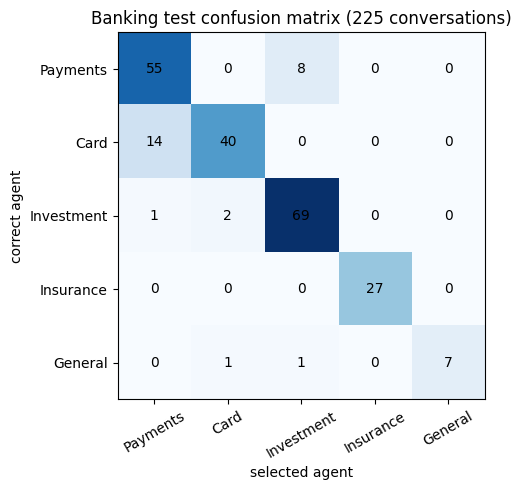

In [128]:
# Cell 48 — Confusion matrix on all banking test conversations: rows = correct agent, columns = selected agent

short_names = {"Payments Agent": "Payments", "Card Support Agent": "Card", "Investment Agent": "Investment",
               "Insurance Agent": "Insurance", "General Customer Support Agent": "General"}
idx = {n: i for i, n in enumerate(AGENT_NAMES)}
confusion = torch.zeros(5, 5, dtype=torch.long)
for r in all_results:
    confusion[idx[r["ex"]["target_agent"]], idx[r["pred"]]] += 1

labels5 = [short_names[n] for n in AGENT_NAMES]
print(f"{'correct \\ selected':>18}" + "".join(f"{l:>11}" for l in labels5) + f"{'total':>8}")
for i, l in enumerate(labels5):
    print(f"{l:>18}" + "".join(f"{v:>11d}" for v in confusion[i].tolist()) + f"{int(confusion[i].sum()):>8}")
assert confusion.sum() == len(all_results)
print(f"correct on the diagonal: {int(confusion.diag().sum())} / {len(all_results)}")

pc = [idx["Payments Agent"], idx["Card Support Agent"]]
print("\nPayments <-> Card Support block (rows correct, columns selected):")
print(confusion[pc][:, pc])

errors = [r for r in eval_results if r["pred"] != r["ex"]["target_agent"]]
print(f"\nBenchmark errors ({len(errors)} of {len(eval_results)}):")
for r in errors:
    print(f"  {r['ex']['id']:7s} correct {short_names[r['ex']['target_agent']]:10s} -> selected {short_names[r['pred']]:10s} "
          f"| last user message: {r['ex']['messages'][-1]['content']!r}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(confusion.numpy(), cmap="Blues")
for i in range(5):
    for j in range(5):
        ax.text(j, i, int(confusion[i, j]), ha="center", va="center")
ax.set_xticks(range(5), labels5, rotation=30)
ax.set_yticks(range(5), labels5)
ax.set_xlabel("selected agent")
ax.set_ylabel("correct agent")
ax.set_title("Banking test confusion matrix (225 conversations)")
plt.tight_layout()
plt.show()

---
# Phase 14 — Ding-dong routing

## Cell 50 — Define the ding-dong problem

**What.** A "ding-dong" conversation is one where the user repeatedly jumps between agents' topics:

```text
User → investment topic      → Investment
User → payment topic         → Payments
User → investment topic      → Investment
…
```

Sometimes the jumps are legitimate (a real second question). Sometimes they're deliberate or playful ("lol no, block my card", "just kidding").

**Why.** A router that re-decides after every user turn can flip-flop: it might switch on a stray keyword, or fail to follow a real change of topic. To study this, we need the **expected agent after every user turn**, not only at the end. Each sequence in `data/modernbert_router_dingdong.json` annotates every user turn with:

| `turn_type` | Meaning |
|---|---|
| `start` | first request |
| `same_topic` | follow-up on the current topic: the agent should **not** change |
| `topic_change` | a genuine new request: switching is correct |
| `ding_dong` | the user deliberately bounces to another agent's topic: following them is correct, but it's a *bounce* |
| `ambiguous` | the request could belong to more than one agent; history decides |

**Shapes.** 5 sequences of 9 messages each, with 5 annotated user turns per sequence (25 routing decisions).

**Expect.** One sequence printed with its per-turn annotations, and a summary of the turn types.

In [130]:
# Cell 50 — Ding-dong sequences with the expected agent after every user turn

for seq in router_dingdong:
    print(f"{seq['id']}: {seq['title']}")

seq = router_dingdong[0]
print(f"\n{seq['id']} in full:")
ann = {u["message_index"]: u for u in seq["user_turns"]}
for i, m in enumerate(seq["messages"]):
    note = f"   -> expect {short_names[ann[i]['expected_agent']]} ({ann[i]['turn_type']})" if i in ann else ""
    print(f"  {m['role']:9s}: {m['content']}{note}")

print("\nturn types:", dict(Counter(u["turn_type"] for s_ in router_dingdong for u in s_["user_turns"])))

D1: Investment <-> Payments ping-pong
D2: Follow-ups on one topic (the router should stay)
D3: Payments <-> Card Support bouncing
D4: Playful bouncing across all agents
D5: General start, handoff, OK, follow-ups

D1 in full:
  user     : I want to invest in a mutual fund.   -> expect Investment (start)
  assistant: The Investment Agent can help you choose a fund.
  user     : How do I transfer money into my investment account?   -> expect Payments (topic_change)
  assistant: The Payments Agent can help with transfers.
  user     : Ok and which fund has lower risk?   -> expect Investment (ding_dong)
  assistant: The Investment Agent can compare fund risk for you.
  user     : And the transfer fee?   -> expect Payments (ding_dong)
  assistant: Transfer charges are handled by the Payments Agent.
  user     : Back to funds, what about returns over five years?   -> expect Investment (ding_dong)

turn types: {'start': 5, 'topic_change': 3, 'ding_dong': 9, 'same_topic': 6, 'ambiguous': 2}


## Cell 51 — Evaluate routing stability

**What.** Replay each ding-dong conversation and route **after every user turn**, using the conversation history up to and including that turn. Record:

```text
Turn | user message | expected agent | selected agent | probability | switch?
```

**Why.** This is how a router behaves inside a live multi-agent system: it's consulted again on every user message. A decision is a **switch** if the selected agent differs from the one selected at the previous user turn.

**Math.** For user turn `t`, `prefix_t = messages[0 : index_t + 1]`, so the prefix always ends with that user message, and `selected_t = argmax_k score(prefix_t, agent_k)`.

**Shapes.** 25 prefixes × 5 candidates = 125 encoder passes (cached after the first run).

**Expect.** A per-turn table for each sequence, and per-turn accuracy overall.

**Current agent.** This is a live simulation. The agent holding the conversation at each turn is the router's **own previous pick** (none at the first turn), exactly as in a deployed system. A wrong pick can therefore carry over to the next turn.

In [132]:
# Cell 51 — Route after every user turn and mark switches

def replay(seq):
    """Live simulation: the current agent is the router's OWN previous pick (so an early mistake can carry over)."""
    rows, prev = [], None
    for u in seq["user_turns"]:
        prefix = seq["messages"][:u["message_index"] + 1]
        s_ = score_candidates(prefix, AGENTS, prev)
        pr = torch.softmax(s_, dim=0)
        sel = AGENT_NAMES[int(torch.argmax(s_))]
        rows.append({"turn": len(rows) + 1, "message": prefix[-1]["content"], "expected": u["expected_agent"],
                     "type": u["turn_type"], "selected": sel, "prob": pr.max().item(),
                     "switch": prev is not None and sel != prev})
        prev = sel
    return rows


dingdong_rows = {seq["id"]: replay(seq) for seq in router_dingdong}

for sid, rows in dingdong_rows.items():
    print(f"\n{sid}: {next(s_['title'] for s_ in router_dingdong if s_['id'] == sid)}")
    print(f"  {'turn':>4} | {'user message':44s} | {'expected':10s} | {'selected':10s} | {'prob':>5} | switch?")
    for r in rows:
        ok = "" if r["selected"] == r["expected"] else "  x"
        msg = r["message"] if len(r["message"]) <= 44 else r["message"][:41] + "..."
        print(f"  {r['turn']:>4} | {msg:44s} | {short_names[r['expected']]:10s} | {short_names[r['selected']]:10s} | "
              f"{r['prob']:5.2f} | {'SWITCH' if r['switch'] else ''}{ok}")

all_rows = [r for rows in dingdong_rows.values() for r in rows]
turn_accuracy = sum(r["selected"] == r["expected"] for r in all_rows) / len(all_rows)
print(f"\nper-turn routing accuracy over {len(all_rows)} user turns: {turn_accuracy:.1%}")


D1: Investment <-> Payments ping-pong
  turn | user message                                 | expected   | selected   |  prob | switch?
     1 | I want to invest in a mutual fund.           | Investment | Investment |  1.00 | 
     2 | How do I transfer money into my investmen... | Payments   | Investment |  1.00 |   x
     3 | Ok and which fund has lower risk?            | Investment | Investment |  0.99 | 
     4 | And the transfer fee?                        | Payments   | Payments   |  0.84 | SWITCH
     5 | Back to funds, what about returns over fi... | Investment | Investment |  0.96 | SWITCH

D2: Follow-ups on one topic (the router should stay)
  turn | user message                                 | expected   | selected   |  prob | switch?
     1 | My card has been blocked.                    | Card       | Card       |  0.78 | 
     2 | Why did that happen?                         | Card       | Card       |  0.63 | 
     3 | Can you unblock it?                          | Car

---
# Phase 15 — Final analysis

## Cell 58 — Final summary

**The journey.**

```text
SmolLM2
  ↓
causal generation                    token i sees tokens ≤ i, predicts token i+1

ModernBERT
  ↓
bidirectional representation         every token sees every token; RoPE for position;
                                     local (±64) and global layers; GeGLU MLP; pre-norm residuals
                                     → [B, S, 768], built here from the real pretrained checkpoint
                                       and verified against the reference implementation

Compatibility head
  ↓
dynamic choice scoring               mean-pooled (conversation ⊕ candidate) → Linear(768 → 1) → score

Multi-agent router
  ↓
conversation + candidate agent       5 cross-encoder passes → softmax → selected agent
  ↓
score
```

**What we built and verified.** Our own PyTorch forward pass for ModernBERT, covering embeddings, RoPE (two bases), Q/K/V, multi-head attention, padding plus sliding-window masks, local/global layers, LayerNorm, GeGLU, residuals, all layers and the final norm. It was loaded with the **real pretrained ModernBERT-large weights** (28 layers, H = 1,024) and matches the reference `last_hidden_state` to about 3e-5. The checkpoint's own MLM head fills `My card payment [MASK]…` with "expired" (base said "failed").

**How the router was trained and tested.** The compatibility head was trained **only on generic conversations from 27 non-banking domains**, and its configuration was chosen by leaving whole domains out. It was then tested on **banking**, whose five agents it had never seen. Every banking number below is therefore a test of compatibility between a conversation and an *unseen* agent description.

**The question we set out to answer:** *can a ModernBERT cross-encoder learn the compatibility between a conversation and a dynamically supplied agent description, and use it to route a multi-agent conversation?* The table below gives the measured answer in absolute numbers.

In [134]:
# Cell 58 — Final summary in absolute numbers

def row(name, test_set, passed, total):
    print(f"{name:52s} | {test_set:34s} | {total:>7} | {passed:>4} | {total - passed:>4}")


print(f"{'approach / measurement':52s} | {'test set':34s} | {'samples':>7} | {'pass':>4} | {'fail':>4}")
print("-" * 112)
row("leave-domains-out (router head)", f"generic, all {len(generic_domains)} domains held out", *lodo_best)
row("5-agent router", "banking benchmark", *eval_metrics["overall routing accuracy"])
row("5-agent router", "all banking conversations", *all_metrics["overall routing accuracy"])
row("5-agent router", "banking ding-dong, per user turn", int(round(turn_accuracy * len(all_rows))), len(all_rows))
row("5-agent router", "banking ding-dong, full conversation",
    sum(rows[-1]["selected"] == rows[-1]["expected"] for rows in dingdong_rows.values()), len(dingdong_rows))

print(f"\nencoder vs reference (last_hidden_state): max |diff| = {encoder_validation_diff:.1e} | MLM demo: {mlm_top_prediction!r}")
print(f"winning head: {BEST_CFG} | epochs {final_epochs}, {head_train_time:.1f}s | device {DEVICE} | live routing decision: {live_latency:.2f}s")

approach / measurement                               | test set                           | samples | pass | fail
----------------------------------------------------------------------------------------------------------------
leave-domains-out (router head)                      | generic, all 77 domains held out   |    6850 | 5845 | 1005
5-agent router                                       | banking benchmark                  |      50 |   43 |    7
5-agent router                                       | all banking conversations          |     225 |  198 |   27
5-agent router                                       | banking ding-dong, per user turn   |      25 |   20 |    5
5-agent router                                       | banking ding-dong, full conversation |       5 |    4 |    1

encoder vs reference (last_hidden_state): max |diff| = 2.8e-05 | MLM demo: ' expired'
winning head: ('dual + cross + sim', 'last', 'mlp-256') | epochs {'dual + cross + sim': 2}, 0.7s | device cuda | l

## Cell 59 — Try it on five brand-new conversations

**What.** Five conversations, each with 8 user turns (40 in total), from five companies: an online shop, a home internet and mobile provider, a furniture store, an energy supplier and an online course provider. None of their agents appears in the training data. (The training data does have a mobile-network domain, but with different, narrower agents.) Like real customer service, each company has just **three broad agents**, for example Orders, Returns & Refunds and Payments. That's far fewer than the five narrow, partly overlapping agents of the training domains.

**Live, with a current agent.** The router is called after **every** user turn with the whole history, assistant replies included. The agent holding the conversation is the router's **own previous pick** (none at the first turn), exactly as it would be deployed. The table prints that current agent and the assistant lines, so you can see everything the router read.

For every turn the cell prints the router's pick, its probability and the probability of the **expected** agent. All the numbers are kept in `turn_log`.

**What the conversations exercise.**
- **Clear requests:** "Where is my order?", "My internet has been down since this morning."
- **Topic switches mid-conversation:** order → double charge → return → address change.
- **Short replies that only make sense from the history and the current agent:** "55102", "afternoon", "12 Harbour Road", "Chrome" and "yes" as answers to the agent's question, and "ok" or "ok thanks" after an answer.

**Expect.** Clear first messages and explicit switches should route correctly. The short replies test the current-agent signal: each should stay with the agent who just asked or answered.

**How to use it.** Edit `NEW_TESTS` to try your own agents and conversations. No retraining is needed, because agents are just names and descriptions.


In [136]:
# Cell 59 — Five new conversations from domains the head never saw, routed live

# Each company has a few broad agents, as real customer service does; then (user message, expected agent, assistant reply) per turn.
NEW_TESTS = [
    {"domain": "online shop",
     "agents": {
         "Orders Agent": "Handles orders: placing and changing orders, delivery addresses, tracking and late deliveries.",
         "Returns & Refunds Agent": "Handles returns: sending items back, return labels and getting money back for returned items.",
         "Payments Agent": "Handles payments: paying, failed or double charges, saved cards and invoices."},
     "turns": [
         ("Where is my order? It was supposed to arrive yesterday.", "Orders Agent", "Can you share the order number?"),
         ("55102", "Orders Agent", "It's with the courier and arrives today."),
         ("Also I was charged twice for it.", "Payments Agent", "I see two charges; the extra one will be reversed within 3 days."),
         ("ok thanks", "Payments Agent", "Anything else I can help with?"),
         ("Yes, the shoes in that order are too small. Can I send them back?", "Returns & Refunds Agent", "Sure, I've emailed you a return label."),
         ("how long until I get my money back?", "Returns & Refunds Agent", "5 to 7 days after we receive them."),
         ("Can I change the delivery address for my other order?", "Orders Agent", "What's the new address?"),
         ("5 Mill Lane", "Orders Agent", None)]},
    {"domain": "home internet and mobile provider",
     "agents": {
         "Technical Support Agent": "Fixes problems: internet down or slow, router issues, no signal and connection faults.",
         "Bills & Payments Agent": "Handles bills: charges, higher bills, payment plans and paying a bill.",
         "Plans & Upgrades Agent": "Handles plans: changing or upgrading a plan, faster speeds and phone upgrades."},
     "turns": [
         ("My internet has been down since this morning.", "Technical Support Agent", "Have you restarted the router?"),
         ("yes twice", "Technical Support Agent", "I've reset the line from our side; please try now."),
         ("It works now. Why was my bill higher this month?", "Bills & Payments Agent", "There was a roaming charge from your trip."),
         ("ah right, can I pay it in two parts?", "Bills & Payments Agent", "Yes, I've split it into two payments."),
         ("I'd like a faster internet plan.", "Plans & Upgrades Agent", "The 500 Mbps plan is 10 more a month. Want it?"),
         ("yes please", "Plans & Upgrades Agent", "Done, it starts next month."),
         ("Does the new plan come with a phone upgrade?", "Plans & Upgrades Agent", "Yes, you can pick a new phone in the app."),
         ("The router light is blinking red again.", "Technical Support Agent", None)]},
    {"domain": "furniture store",
     "agents": {
         "Orders & Delivery Agent": "Handles furniture orders: placing orders, delivery dates and tracking deliveries.",
         "Assembly Service Agent": "Books our fitters to put furniture together at your home.",
         "Returns Agent": "Handles returns of furniture and damaged items, and refunds for them."},
     "turns": [
         ("When will my sofa be delivered?", "Orders & Delivery Agent", "It's scheduled for Thursday. Morning or afternoon?"),
         ("afternoon", "Orders & Delivery Agent", "Booked for Thursday afternoon."),
         ("Can someone put the wardrobe together for me too?", "Assembly Service Agent", "A fitter can come on Friday. Shall I book it?"),
         ("yes", "Assembly Service Agent", "Booked for Friday."),
         ("The coffee table arrived with a scratch, I want to return it.", "Returns Agent", "Sorry about that! Can you send a photo?"),
         ("sent it just now", "Returns Agent", "Got it; we'll collect it on Monday and refund you."),
         ("ok great", "Returns Agent", "Anything else?"),
         ("Will the delivery team take my old sofa away?", "Orders & Delivery Agent", None)]},
    {"domain": "energy supplier",
     "agents": {
         "Power Outages Agent": "Handles power cuts and faults: outages, flickering lights and engineer visits.",
         "Billing Agent": "Handles bills: high bills, charges and spreading payments.",
         "Moving Home Agent": "Moves the energy supply when a customer moves house."},
     "turns": [
         ("The power is out on my whole street.", "Power Outages Agent", "Sorry about that. What's your postcode?"),
         ("4412", "Power Outages Agent", "Engineers are on site; power should be back by 10 pm."),
         ("While I have you, why is my last bill so high?", "Billing Agent", "It includes two months of catch-up charges."),
         ("can I spread it out?", "Billing Agent", "Yes, over the next three bills."),
         ("We're moving house on the 14th.", "Moving Home Agent", "What's the new address?"),
         ("12 Harbour Road", "Moving Home Agent", "Done, your supply moves on the 14th."),
         ("The lights flickered again just now.", "Power Outages Agent", "We'll send an engineer. Morning or afternoon?"),
         ("morning please", "Power Outages Agent", None)]},
    {"domain": "online courses",
     "agents": {
         "Enrolment Agent": "Handles signing up for courses, start dates and course choice.",
         "Payments Agent": "Handles course payments: declined cards, payment links and invoices.",
         "Technical Help Agent": "Fixes problems with videos, logins and the learning platform."},
     "turns": [
         ("I want to sign up for the Python course.", "Enrolment Agent", "The next class starts on the 3rd. Shall I enrol you?"),
         ("yes", "Enrolment Agent", "Done. You'll get the details by email."),
         ("My card was declined when I tried to pay.", "Payments Agent", "Try another card, or I can send you a payment link."),
         ("send the link", "Payments Agent", "Sent."),
         ("The video lessons won't play on my laptop.", "Technical Help Agent", "Which browser are you using?"),
         ("Chrome", "Technical Help Agent", "Please clear the cache and try again."),
         ("that fixed it, thanks", "Technical Help Agent", "Great!"),
         ("Can I get an invoice for my company?", "Payments Agent", None)]},
]

if ROUTER_SMOKE:
    NEW_TESTS = NEW_TESTS[:2]                                                 # code check only

APPROACHES = ["router"]                           # Phase 7: the per-pass heads and "router x2" were removed


def route_probs(messages, agents, current):
    """Probabilities over the candidates from the final router."""
    return {"router": head_probs(final_heads, *candidate_features(messages, agents, current)).cpu()}


def short(name):
    return name.replace(" Agent", "")[:16]


turn_log = []                                     # every turn's probabilities, for later inspection
passes = {a: 0 for a in APPROACHES}
for conv in NEW_TESTS:
    names, messages, current = list(conv["agents"]), [], None
    print(f"\n{conv['domain']}  (candidates: {', '.join(short(n) for n in names)})")
    print(f"  {'turn':>4} | {'user message':40s} | {'current':16s} | {'expected':16s} | "
          + " | ".join(f"{a + ': pick':>23s}" for a in APPROACHES) + " | p(expected) " + " / ".join(APPROACHES))
    for t, (user_msg, expected, reply) in enumerate(conv["turns"], 1):
        messages.append({"role": "user", "content": user_msg})
        probs = route_probs(messages, conv["agents"], current)
        e = names.index(expected)
        picks = {a: names[int(torch.argmax(p_))] for a, p_ in probs.items()}
        for a in APPROACHES:
            passes[a] += picks[a] == expected
        turn_log.append({"domain": conv["domain"], "turn": t, "message": user_msg, "current": current, "expected": expected,
                         "probs": {a: dict(zip(names, probs[a].tolist())) for a in APPROACHES}})
        msg = user_msg if len(user_msg) <= 40 else user_msg[:37] + "..."
        cols = " | ".join(f"{short(picks[a]):>16s} {probs[a].max().item():.2f}{' x' if picks[a] != expected else '  '}" for a in APPROACHES)
        print(f"  {t:>4} | {msg:40s} | {short(current or 'none'):16s} | {short(expected):16s} | {cols} | "
              + " / ".join(f"{probs[a][e].item():.2f}" for a in APPROACHES))
        current = picks["router"]                 # live: the router's own pick answers, so it holds the next turn
        if reply:
            messages.append({"role": "assistant", "content": reply})
            print(f"  {'':>4} |   assistant ({short(current)}): {reply}")

n_turns = len(turn_log)
print(f"\nunseen-domain conversations, {n_turns} user turns:")
for a in APPROACHES:
    print(f"  {a:10s}: {passes[a]:>2} pass / {n_turns - passes[a]:>2} fail")


online shop  (candidates: Orders, Returns & Refund, Payments)
  turn | user message                             | current          | expected         |            router: pick | p(expected) router
     1 | Where is my order? It was supposed to... | none             | Orders           |           Orders 1.00   | 1.00
       |   assistant (Orders): Can you share the order number?
     2 | 55102                                    | Orders           | Orders           |           Orders 0.98   | 0.98
       |   assistant (Orders): It's with the courier and arrives today.
     3 | Also I was charged twice for it.         | Orders           | Payments         |         Payments 0.95   | 0.95
       |   assistant (Payments): I see two charges; the extra one will be reversed within 3 days.
     4 | ok thanks                                | Payments         | Payments         |         Payments 0.85   | 0.85
       |   assistant (Payments): Anything else I can help with?
     5 | Yes, the sho

---
# Phase 16 — A simpler question first: has the context changed?

## Cell 60 — Context-change labels (Y / N)

**What.** Before choosing among agents, ask one yes/no question about the **last user message**: does it move the conversation to a **different topic** (Y), or does it continue the current one (N)? The generic data now labels every conversation that has a previous turn:
- **N:** follow-ups ("can you check again?"), short answers to the agent's question ("Sunday", "PS5", "12 Harbour Road"), closings ("thanks", "got it"), and "ok" after a handoff. The user is still on the same thread.
- **Y:** topic changes ("Also, my bill is double"), short switches ("and the bill?", "printer please"), returning to an earlier topic, and "forget the X, I want Y".

**Why.** Most routing failures so far were short replies that the router sent back to the conversation's *first* topic. Telling "same thread" from "new topic" is a simpler, candidate-free question. If it can be answered (close to) perfectly, it can later steer the router: on N keep the current agent, on Y let the compatibility head choose.

**More short replies.** This data adds many more short samples: 4 short answers per specialist, 2 closings per specialist, 16 short answers after a topic change and 16 short switches per domain. Short Y examples matter, or the detector would just learn "short means N".

**Expect.** The Y/N counts, how many last messages are short, and one example of each kind.

**Data fixes for gaps found in run 5:**
- "Also …" / "And …" follow-ups that stay on the same topic (N);
- returns to an earlier topic with "… again" (Y);
- the first real request after the General agent's prompt (Y);
- more short-switch wording ("password?", "ok and billing").

(Phase 1 also trained a second label, **agent switch**, Y when the right agent differs from the current one. It never beat context change as a gate and was removed in Phase 7.)


In [138]:
# Cell 60 — Context-change labels: does the LAST user message move the conversation to a different topic? (Y / N)

cc_conv_idx = [i for i, ex in enumerate(generic_conversations) if ex["context_change"] is not None]   # needs a previous turn
cc_examples = [generic_conversations[i] for i in cc_conv_idx]
cc_labels = torch.tensor([float(ex["context_change"]) for ex in cc_examples])
cc_fold = torch.tensor([next(f for f, doms in enumerate(FOLDS) if ex["domain"] in doms) for ex in cc_examples])


def is_short(ex):
    return len(ex["messages"][-1]["content"].split()) <= 3


n_yes = int(cc_labels.sum())
short_ex = [ex for ex in cc_examples if is_short(ex)]
print(f"{len(cc_examples)} generic conversations with a previous turn: {n_yes} Y (context changes) | {len(cc_examples) - n_yes} N (same context)")
print(f"short last messages (<= 3 words): {len(short_ex)} | Y {sum(ex['context_change'] for ex in short_ex)} | "
      f"N {sum(not ex['context_change'] for ex in short_ex)}")

for tag in ["short_answer", "closing", "short_switch", "topic_change", "ok_after_handoff", "stay_prefix", "return_again", "after_general"]:
    ex = next((e for e in cc_examples if tag in e["tags"] and (tag != "short_answer" or "closing" not in e["tags"])), None)
    if ex is None:
        continue
    print(f"\n[{tag}]  current agent: {ex['current_agent']}  ->  context change: {'Y' if ex['context_change'] else 'N'}")
    for m in ex["messages"][-3:]:
        print(f"   {m['role']:9s}: {m['content']}")

5948 generic conversations with a previous turn: 2819 Y (context changes) | 3129 N (same context)
short last messages (<= 3 words): 2916 | Y 601 | N 2315

[short_answer]  current agent: Password & Access Agent  ->  context change: N
   user     : I need admin rihgts on the CRM.
   assistant: Which device are you using?
   user     : PS5

[closing]  current agent: Password & Access Agent  ->  context change: N
   user     : My login keeps getting rejected.
   assistant: I've noted that.
   user     : got it

[short_switch]  current agent: Network & VPN Agent  ->  context change: Y
   user     : The VPN keeps disconnecting.
   assistant: Here is what I found.
   user     : printer please

[topic_change]  current agent: Software Installation Agent  ->  context change: Y
   user     : The PDF editor shows a license error.
   assistant: Sure, let me look into that.
   user     : Different thing: my login keeps getting rejected.

[ok_after_handoff]  current agent: General IT Support Agent  -

## Cell 61 — Detector features from one joint pass

**What.** One ModernBERT pass over the conversation plus its current agent (`history [SEP] current agent: X`), the same text as the dual pass's conversation input. From that pass, three spans are mean-pooled:
- the **last user message**: its tokens have attended to the whole history;
- **everything before it**: the context so far;
- the **assistant message just before it**: often a question ("Which platform?") that a short answer refers to.

**Features.** Standardize, then the three vectors plus how the last message compares with the history and with the previous assistant message (products and absolute differences): 7 × H numbers per conversation. Nothing is reduced.

**Expect.** About 4,300 passes on the first run (a few minutes on the T4), cached afterwards.

In [140]:
# Cell 61 — Features for the detector: one joint pass over (history [SEP] current agent), three spans pooled

CC_CACHE = CACHE_DIR / f"context_features_{DETECTOR_ENC.tag}.pt"     # the DETECTOR encoder
cc_cache = torch.load(CC_CACHE) if CC_CACHE.exists() else {}


def context_features(examples):
    """-> [N, 3, H]: mean of the last user message, of everything before it, and of the assistant message just before it.

    All three come from ONE pass over the whole conversation, so the last message's tokens have read the history."""
    built = [build_text(ex["messages"], ex["current_agent"], None, DETECTOR_ENC.query, enc=DETECTOR_ENC) for ex in examples]
    ranges = [[sp["messages"][-1], (sp["messages"][0][0], sp["messages"][-2][1]), sp["messages"][-2]] for _, sp in built]
    return span_means([t for t, _ in built], ranges, cc_cache, CC_CACHE, "context features", mix=False, enc=DETECTOR_ENC)[:, 0]


def context_matching(feats, stats):
    """Standardize; then last message, history, previous assistant message, and how the last message compares to both -> [N, 7H]."""
    z = (feats - stats[0]) / stats[1]
    l, h, a = z[:, 0], z[:, 1], z[:, 2]
    return torch.cat([l, h, a, l * h, (l - h).abs(), l * a, (l - a).abs()], dim=1)


cc_feats = context_features(cc_examples)
print(f"context features {tuple(cc_feats.shape)} (conversations, [last message, history, previous assistant message], H)")

context features (5948, 3, 1024) (conversations, [last message, history, previous assistant message], H)


## Cell 62 — Train and score the detector on unseen domains

**What.** The same leave-domains-out scheme as the router: for each fold, train on 3 folds, early-stop on the next one, and score the held-out fold. The head is MLP-256 (fixed in Phase 7; it won in run 11), trained with a class-balanced loss, so Y and N count equally.

**Expect.** Held-out results in absolute numbers. "Y found" counts real topic changes that were detected, and "N kept" counts same-thread messages left alone. Both are reported for all messages and for short ones (≤ 3 words), because short replies are the hard case.

In [142]:
# Cell 62 — Train the Y/N detector with leave-domains-out folds; score the held-out domains

CC_HEADS = ["mlp-256"]                     # Phase 7: fixed (it won in run 11; linear / mlp-64 remain available in make_head)


def train_binary(kind, X_tr, y_tr, X_va=None, y_va=None, epochs=MAX_EPOCHS, patience=PATIENCE, seed=42):
    """X: [N, F], y: [N] in {0, 1}; class-balanced BCE. Early stopping on (X_va, y_va) if given."""
    torch.manual_seed(seed)
    head = make_head(kind, X_tr.shape[-1]).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    pos_weight = (1 - y_tr).sum() / y_tr.sum().clamp(min=1)               # Y and N count equally
    loss_fn = lambda X, y: F.binary_cross_entropy_with_logits(head(X).squeeze(-1), y, pos_weight=pos_weight)
    g = torch.Generator().manual_seed(seed)
    best, history = (float("inf"), None, 0), []
    for epoch in range(1, epochs + 1):
        head.train()
        for idx in torch.randperm(len(X_tr), generator=g).split(64):
            idx = idx.to(DEVICE)
            loss = loss_fn(X_tr[idx], y_tr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        if X_va is None:
            continue
        head.eval()
        with torch.no_grad():
            history.append((loss_fn(X_tr, y_tr).item(), loss_fn(X_va, y_va).item()))
        if history[-1][1] < best[0]:
            best = (history[-1][1], copy.deepcopy(head.state_dict()), epoch)
        if epoch - best[2] >= patience:
            break
    if X_va is not None:
        head.load_state_dict(best[1])
    head.eval()
    return head, best[2], history


def confusion(pred, y):
    """-> dict of Y/N counts: tp (said Y, was Y), fn (said N, was Y), tn, fp."""
    pred, y = pred.bool(), y.bool()
    return {"tp": int((pred & y).sum()), "fn": int((~pred & y).sum()), "tn": int((~pred & ~y).sum()), "fp": int((pred & ~y).sum())}


def fmt_cc(c):
    yes, no = c["tp"] + c["fn"], c["tn"] + c["fp"]
    return (f"{c['tp'] + c['tn']:>5} / {yes + no:<5} correct | Y: {c['tp']:>4}/{yes:<4} found | "
            f"N: {c['tn']:>4}/{no:<4} kept")


short_mask = torch.tensor([is_short(ex) for ex in cc_examples])


def lodo_detector(labels, title):
    """Leave-domains-out training and scoring of every head type for one Y/N label -> (results, best head type)."""
    t0 = time.perf_counter()
    results = {k: {"all": Counter(), "short": Counter(), "best_epochs": []} for k in CC_HEADS}
    log(f"{title} detector: {len(CC_HEADS)} heads x {N_FOLDS} folds")
    for f in range(N_FOLDS):
        te, va = cc_fold == f, cc_fold == (f + 1) % N_FOLDS
        tr = ~(te | va)
        stats = (cc_feats[tr].mean(0, keepdim=True), cc_feats[tr].std(0, keepdim=True) + 1e-6)
        X, y = context_matching(cc_feats, stats).to(DEVICE), labels.to(DEVICE)
        for kind in CC_HEADS:
            head, best_epoch, _ = train_binary(kind, X[tr.to(DEVICE)], y[tr.to(DEVICE)], X[va.to(DEVICE)], y[va.to(DEVICE)])
            with torch.no_grad():
                pred = (head(X[te.to(DEVICE)]).squeeze(-1) > 0).cpu()
            results[kind]["all"].update(confusion(pred, labels[te]))
            results[kind]["short"].update(confusion(pred[short_mask[te]], labels[te][short_mask[te]]))
            results[kind]["best_epochs"].append(best_epoch)
            log(f"  fold {f} | {kind:8s} | best epoch {best_epoch:3d} | held-out: {fmt_cc(confusion(pred, labels[te]))}")
        del X, y
    print(f"\n{title}: held-out domains (every domain held out once), {time.perf_counter() - t0:.0f}s")
    for kind in CC_HEADS:
        print(f"  {kind:8s} all messages   : {fmt_cc(results[kind]['all'])}")
        print(f"  {'':8s} short (<= 3 w) : {fmt_cc(results[kind]['short'])}")
    best = max(CC_HEADS, key=lambda k: results[k]["all"]["tp"] + results[k]["all"]["tn"])
    print(f"best {title} head: {best} | best epochs per fold {results[best]['best_epochs']}\n")
    return results, best


cc_results, CC_BEST = lodo_detector(cc_labels, "context-change")


[05:39:26] context-change detector: 1 heads x 5 folds
[05:39:41]   fold 0 | mlp-256  | best epoch  81 | held-out:   734 / 773   correct | Y:  353/371  found | N:  381/402  kept
[05:39:48]   fold 1 | mlp-256  | best epoch  20 | held-out:  1434 / 1490  correct | Y:  668/701  found | N:  766/789  kept
[05:40:04]   fold 2 | mlp-256  | best epoch 100 | held-out:  1249 / 1292  correct | Y:  600/615  found | N:  649/677  kept
[05:40:19]   fold 3 | mlp-256  | best epoch  86 | held-out:  1066 / 1108  correct | Y:  499/518  found | N:  567/590  kept
[05:40:27]   fold 4 | mlp-256  | best epoch  17 | held-out:  1235 / 1285  correct | Y:  592/614  found | N:  643/671  kept

context-change: held-out domains (every domain held out once), 60s
  mlp-256  all messages   :  5718 / 5948  correct | Y: 2712/2819 found | N: 3006/3129 kept
           short (<= 3 w) :  2880 / 2916  correct | Y:  579/601  found | N: 2301/2315 kept
best context-change head: mlp-256 | best epochs per fold [81, 20, 100, 86, 17]



## Cell 63 — Final detector, tested on realistic conversations

**What.** Train the best detector head on all generic data. Then test it on conversations it has never seen:
- **(a)** the realistic conversations of Cell 59. A turn is Y when its expected agent differs from the previous turn's. The current agent is the previous turn's **correct** agent, so this measures the detector alone, without the router's mistakes.
- **(b)** the banking ding-dong turns: `topic_change` and `ding_dong` turns are Y, `same_topic` turns are N.

**Expect.** Every turn with its truth, `p(change)` and the detector's answer, then a summary. The goal is 100%. If it gets there, the next step is to combine it with the router: on N stay with the current agent, on Y let the compatibility head choose.

In [144]:
# Cell 63 — Final detector on all generic data; test it on the realistic conversations (Cell 59) and banking ding-dong turns

CC_STATS = (cc_feats.mean(0, keepdim=True), cc_feats.std(0, keepdim=True) + 1e-6)
cc_epochs = max(1, int(statistics.median(cc_results[CC_BEST]["best_epochs"])))
cc_head, _, _ = train_binary(CC_BEST, context_matching(cc_feats, CC_STATS).to(DEVICE), cc_labels.to(DEVICE), epochs=cc_epochs)
log(f"final context-change detector: {CC_BEST}, {cc_epochs} epochs, trained on {len(cc_examples)} generic conversations")


def p_change(messages, current):
    """Probability that the last user message changes the context, given the history and the agent holding it."""
    feats = context_features([{"messages": messages, "current_agent": current}])
    with torch.no_grad():
        return torch.sigmoid(cc_head(context_matching(feats, CC_STATS).to(DEVICE))).item()


def show(rows, title):
    print(f"\n{title}")
    print(f"  {'user message':44s} | {'current':18s} | truth | p(change) | said | ")
    for msg, cur, truth, p in rows:
        said = p > 0.5
        m_ = msg if len(msg) <= 44 else msg[:41] + "..."
        print(f"  {m_:44s} | {(cur or 'none').replace(' Agent', '')[:18]:18s} |   {'Y' if truth else 'N'}   |   {p:5.2f}   |  {'Y' if said else 'N'}  | {'' if said == truth else 'x'}")
    c = confusion(torch.tensor([p > 0.5 for *_, p in rows]), torch.tensor([t for _, _, t, _ in rows]))
    print(f"  -> {fmt_cc(c)}")
    return c


# (a) the realistic conversations of Cell 59: label = the expected agent differs from the previous turn's; current = previous expected agent
realistic = []
for conv in NEW_TESTS:
    messages, prev = [], None
    for user_msg, expected, reply in conv["turns"]:
        messages.append({"role": "user", "content": user_msg})
        if prev is not None:
            realistic.append((user_msg, prev, expected != prev, p_change(list(messages), prev)))
        prev = expected
        if reply:
            messages.append({"role": "assistant", "content": reply})
c_real = show(realistic, f"realistic conversations (Cell 59), {len(realistic)} turns after the first:")

# (b) banking ding-dong: topic_change / ding_dong turns are Y, same_topic turns are N (start and ambiguous turns skipped)
banking_turns = []
for seq in router_dingdong:
    prev = None
    for u in seq["user_turns"]:
        if prev is not None and u["turn_type"] in ("topic_change", "ding_dong", "same_topic"):
            prefix = seq["messages"][:u["message_index"] + 1]
            banking_turns.append((prefix[-1]["content"], prev, u["turn_type"] != "same_topic", p_change(prefix, prev)))
        prev = u["expected_agent"]
c_bank = show(banking_turns, f"banking ding-dong turns, {len(banking_turns)} turns:")

held = cc_results[CC_BEST]["all"]
print(f"\nSUMMARY (Y/N: does the last user message change the context?)")
print(f"  held-out generic domains : {fmt_cc(held)}")
print(f"  realistic conversations  : {fmt_cc(c_real)}")
print(f"  banking ding-dong turns  : {fmt_cc(c_bank)}")


[05:40:43] final context-change detector: mlp-256, 81 epochs, trained on 5948 generic conversations

realistic conversations (Cell 59), 35 turns after the first:
  user message                                 | current            | truth | p(change) | said | 
  55102                                        | Orders             |   N   |    0.00   |  N  | 
  Also I was charged twice for it.             | Orders             |   Y   |    0.91   |  Y  | 
  ok thanks                                    | Payments           |   N   |    0.00   |  N  | 
  Yes, the shoes in that order are too smal... | Payments           |   Y   |    1.00   |  Y  | 
  how long until I get my money back?          | Returns & Refunds  |   N   |    1.00   |  Y  | x
  Can I change the delivery address for my ... | Returns & Refunds  |   Y   |    1.00   |  Y  | 
  5 Mill Lane                                  | Orders             |   N   |    0.00   |  N  | 
  yes twice                                    | Technical S

## Cell 69 — E10: the realistic test set

**What.** 35 free-form conversations from 13 companies that appear nowhere in training: a pharmacy, a water utility, a dating app, a ride-hailing app, a cruise line, a solar installer, a pet-food subscription, a photo-printing service, a car dealership, a driving school, a parking operator, an electronics repair shop and a games-console company. Each company has 3 broad agents, and there are **193 user turns** in total. The conversations were written without templates (`data/modernbert_router/build_realistic_test_data.py`) and are never used for training.

**Live routing.** Every user turn is routed with the history so far. Each approach's **own previous pick** is its current agent, so mistakes can carry over, as in deployment. This cell scores the **router alone**; Cell 70 adds the gate. (The cross-only head, hard cascade and soft fusion were compared here until Phase 7.)

**Turn types.** Every turn is labelled, so the table shows *where* each approach fails:

| Type | Meaning |
|---|---|
| start | first message |
| answer | a short answer to the agent's question |
| follow | a follow-up on the same request |
| aspect | the same agent, a different aspect |
| closing | "ok cheers" |
| also_stay | "Also …" that stays with the agent |
| switch | a clear switch |
| short_switch | a switch in a few words |
| return | back to an earlier topic |
| handoff_ok | "ok" after a handoff |
| branch | the same words, a different agent depending on the history |

**Expect.** Pass / total per turn type and in total, then the router's first mistakes.

In [146]:
# Cell 69 — E10: the realistic test set (35 conversations, 13 companies, 193 typed user turns), routed live

REAL_FILE = DATA_DIR / "realistic" / "conversations.json"
if not REAL_FILE.exists():                                     # a data clone made before this file existed: refresh it
    repo_dir = DATA_DIR.parent.parent
    subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", DATA_BRANCH], check=True)
    subprocess.run(["git", "-C", str(repo_dir), "checkout", "-B", DATA_BRANCH, "FETCH_HEAD"], check=True)
real_convs = load(REAL_FILE)
if globals().get("ROUTER_SMOKE"):
    real_convs = real_convs[:3]                                # code check only


def pick_router(messages, agents, current):
    return list(agents)[int(torch.argmax(score_candidates(messages, agents, current)))]


E10_APPROACHES = {"router": pick_router}         # Phase 7: cross-only, hard cascade and soft fusion were removed; the gate is Cell 70

log(f"E10: {len(real_convs)} conversations, {sum(len(c['user_turns']) for c in real_convs)} user turns x {len(E10_APPROACHES)} approaches")
e10_rows = []
for k, conv in enumerate(real_convs):
    current = {a: None for a in E10_APPROACHES}                # live: each approach's own previous pick holds the next turn
    for u in conv["user_turns"]:
        prefix = conv["messages"][:u["message_index"] + 1]
        row = {"id": conv["id"], "company": conv["company"], "type": u["turn_type"], "expected": u["expected_agent"],
               "message": prefix[-1]["content"]}
        for a, pick_fn in E10_APPROACHES.items():
            row[a] = current[a] = pick_fn(prefix, conv["agents"], current[a])
        e10_rows.append(row)
    if (k + 1) % 10 == 0:
        log(f"  E10 {k + 1}/{len(real_convs)} conversations")

TURN_TYPES = ["start", "answer", "follow", "aspect", "closing", "also_stay", "switch", "short_switch", "return", "handoff_ok", "branch"]
print(f"\nE10 realistic test, live | router encoder: {ROUTER_ENCODER} | detector encoder: {DETECTOR_ENCODER} | router: {BEST_CFG}")
print(f"{'turn type':14s} | {'turns':>5} | " + " | ".join(f"{a:>12s}" for a in E10_APPROACHES))
print("-" * (24 + 15 * len(E10_APPROACHES)))
for tt in TURN_TYPES + ["ALL"]:
    rows = [r for r in e10_rows if tt == "ALL" or r["type"] == tt]
    if not rows:
        continue
    if tt == "ALL":
        print("-" * (24 + 15 * len(E10_APPROACHES)))
    print(f"{tt:14s} | {len(rows):>5} | " + " | ".join(f"{sum(r[a] == r['expected'] for r in rows):>6} / {len(rows):<3}"
                                                     for a in E10_APPROACHES))

print("\nrouter mistakes (first 15):")
for r in [r for r in e10_rows if r["router"] != r["expected"]][:15]:
    msg = r["message"] if len(r["message"]) <= 50 else r["message"][:47] + "..."
    print(f"  {r['id']:9s} {r['type']:12s} | {msg:50s} | expected {r['expected'].replace(' Agent', ''):22s} | got {r['router'].replace(' Agent', '')}")

[05:41:19] E10: 35 conversations, 193 user turns x 1 approaches
[05:41:24]   E10 10/35 conversations
[05:41:28]   E10 20/35 conversations
[05:41:32]   E10 30/35 conversations

E10 realistic test, live | router encoder: nemotron-1b | detector encoder: modernbert | router: ('dual + cross + sim', 'last', 'mlp-256')
turn type      | turns |       router
---------------------------------------
start          |    35 |     32 / 35 
answer         |    51 |     44 / 51 
follow         |    21 |     17 / 21 
aspect         |     7 |      7 / 7  
closing        |    15 |      9 / 15 
also_stay      |     4 |      4 / 4  
switch         |    42 |     29 / 42 
short_switch   |     6 |      6 / 6  
return         |     7 |      6 / 7  
handoff_ok     |     2 |      0 / 2  
branch         |     3 |      3 / 3  
---------------------------------------
ALL            |   193 |    157 / 193

router mistakes (first 15):
  pharm-1   start        | Hi, I need a refill on my blood pressure tablets.  | exp

## Cell 70 — A two-sided gate: "confident stay" and "confident switch"

**Why.** The context-change detector is very reliable at its extremes, and the router has one remaining weakness on real conversations: when a user moves to a **closely related agent** with a message that still mentions the current topic ("and is the snorkelling trip still available?" while talking to Onboard Services), the router stays with the current agent. Run 13 traced every failed E10 test switch to this.

**The gate.** Use the detector only where it is very sure, on either side:

```text
p = detector(conversation, current agent)          # p(context change): ModernBERT pooled (Cells 61-63) or the unified model's yes / no answer
p < τ_low    (sure nothing changed)  → keep the current agent                 "confident stay"  (runs 10-13)
p > τ_high   (sure the topic changed) → the router picks among the OTHER agents "confident switch" (new)
otherwise                            → the router picks among ALL agents
```

This is not the Phase 1 hard cascade: that acted on every p ≥ 0.5, with the weaker agent-switch detector, and so excluded the right agent whenever the detector was unsure. Here the exclusion happens only at the very top of the detector's range.

**Choosing τ honestly.** E10's 13 companies are split in two:
- **7 dev companies:** τ_low ∈ {0.02, 0.05, 0.1, 0.2, 0.3} first; then, with that τ_low, τ_high ∈ {off, 0.9, 0.95, 0.98, 0.99, 0.995, 0.999}. Ties go to "off" (the simpler gate), then to the higher τ_high (the more cautious one);
- **6 test companies:** the results are reported there, next to the router alone and the stay-only gate.

**Two detectors (run 16).** The separate ModernBERT pooled detector, and the unified choice model asked *"Does the latest message move the conversation to a different topic?"* (P(yes)). Each gets its own τ_low and τ_high from the dev companies, and both are reported on the test companies. If the unified answer is as good, the separate detector can go: one model for the whole pipeline.

**Expect.** The dev sweeps, the test table per turn type, and every test turn whose answer the confident switch changed (fixed or broken). If it works, test switches should rise without losing follow-ups and "aspect" turns. (Q-K-V detectors were removed after run 13: no gain in either mode.)


In [ ]:
# Cell 70 — Two-sided gate on E10, two detectors (ModernBERT pooled; the unified model's own yes / no answer); taus on dev companies

companies = sorted({c["company"] for c in real_convs})
DEV_COMPANIES = set(companies[::2])                                   # 7 companies to choose the taus on
TEST_COMPANIES = set(companies) - DEV_COMPANIES                       # 6 companies to report on
dev_convs = [c for c in real_convs if c["company"] in DEV_COMPANIES]
test_convs = [c for c in real_convs if c["company"] in TEST_COMPANIES]

TAUS_LOW = [0.02, 0.05, 0.1, 0.2, 0.3]
TAUS_HIGH = [None, 0.9, 0.95, 0.98, 0.99, 0.995, 0.999]              # None = no confident switch
_memo = {}


def memo(key, fn):
    """The same (turn, current agent) always gives the same answer: compute it once across all taus."""
    if key not in _memo:
        _memo[key] = fn()
    return _memo[key]


def pick_other(messages, agents, current):
    """The router's best agent with the current one excluded."""
    names = list(agents)
    s = score_candidates(messages, agents, current).clone()
    s[names.index(current)] = float("-inf")
    return names[int(torch.argmax(s))]


def p_change_q(messages, current):
    """The unified model asked the context-change question: P(yes)."""
    return ask(messages, CHANGE_Q, ["yes", "no"], current)["yes"]


DETECTORS = {"pooled": p_change, "unified": p_change_q}
DET = "pooled"                                      # set per sweep below


def run_live(convs, tau_low=None, tau_high=None):
    """Route every turn live (the gate's own previous pick is the current agent).
    p < tau_low -> keep the current agent; p > tau_high -> router among the OTHER agents; else router among ALL agents."""
    rows = []
    for conv in convs:
        cur = None
        for k, u in enumerate(conv["user_turns"]):
            prefix = conv["messages"][:u["message_index"] + 1]
            action, p = "route", None
            if (tau_low is not None or tau_high is not None) and cur is not None and cur in conv["agents"]:
                p = memo(("p", DET, conv["id"], k, cur), lambda: DETECTORS[DET](prefix, cur))
                if tau_low is not None and p < tau_low:
                    action = "stay"
                elif tau_high is not None and p > tau_high:
                    action = "switch"
            if action == "route":
                cur = memo(("r", conv["id"], k, cur), lambda: pick_router(prefix, conv["agents"], cur))
            elif action == "switch":
                cur = memo(("o", conv["id"], k, cur), lambda: pick_other(prefix, conv["agents"], cur))
            rows.append({"id": conv["id"], "type": u["turn_type"], "message": prefix[-1]["content"], "expected": u["expected_agent"],
                         "pick": cur, "p": p, "action": action, "ok": cur == u["expected_agent"]})
    return rows


n_ok = lambda rows: sum(r["ok"] for r in rows)
dev_turns = sum(len(c["user_turns"]) for c in dev_convs)
test_turns = sum(len(c["user_turns"]) for c in test_convs)
log(f"gate: dev {len(DEV_COMPANIES)} companies / {dev_turns} turns, test {len(TEST_COMPANIES)} companies / {test_turns} turns")

# 1) DEV, per detector: tau_low for confident stay, then tau_high for confident switch (with that tau_low)
print(f"DEV ({', '.join(sorted(DEV_COMPANIES))})")
print(f"  router alone: {n_ok(run_live(dev_convs))} / {dev_turns}")
chosen = {}
for DET in DETECTORS:
    low_scores = [n_ok(run_live(dev_convs, t)) for t in TAUS_LOW]
    t_low = TAUS_LOW[max(range(len(TAUS_LOW)), key=lambda i: (low_scores[i], -i))]
    high_scores = [n_ok(run_live(dev_convs, t_low, t)) for t in TAUS_HIGH]
    order = sorted(range(len(TAUS_HIGH)), key=lambda i: (-high_scores[i], TAUS_HIGH[i] is not None, -(TAUS_HIGH[i] or 0)))
    chosen[DET] = (t_low, TAUS_HIGH[order[0]])
    print(f"  [{DET}] confident stay   | " + " | ".join(f"{t}: {s_}" for t, s_ in zip(TAUS_LOW, low_scores)) + f"  -> tau_low {t_low}")
    print(f"  [{DET}] + confident switch | " + " | ".join(f"{t or 'off'}: {s_}" for t, s_ in zip(TAUS_HIGH, high_scores))
          + f"  -> tau_high {chosen[DET][1] or 'off'}")
log("gate dev sweeps done")

# 2) TEST with the dev-chosen taus, per detector
test_rows = {"router alone": run_live(test_convs)}
for DET in DETECTORS:
    t_low, t_high = chosen[DET]
    test_rows[f"{DET} stay @{t_low}"] = run_live(test_convs, t_low)
    test_rows[f"{DET} stay+switch @{t_high or 'off'}"] = run_live(test_convs, t_low, t_high)
print(f"\nTEST ({', '.join(sorted(TEST_COMPANIES))}) — taus chosen on DEV only")
names = list(test_rows)
print(f"{'turn type':14s} | {'turns':>5} | " + " | ".join(f"{n:>24s}" for n in names))
for tt in TURN_TYPES + ["ALL"]:
    sel = {n: [r for r in rows if tt == "ALL" or r["type"] == tt] for n, rows in test_rows.items()}
    if not sel["router alone"]:
        continue
    total = len(sel["router alone"])
    print(f"{tt:14s} | {total:>5} | " + " | ".join(f"{n_ok(sel[n]):>17} / {total:<4}" for n in names))

# Which test turns did each detector's confident switch change?
for DET in DETECTORS:
    t_low, t_high = chosen[DET]
    stay_rows, both_rows = test_rows[f"{DET} stay @{t_low}"], test_rows[f"{DET} stay+switch @{t_high or 'off'}"]
    changed = [(a_, b_) for a_, b_ in zip(stay_rows, both_rows) if a_["pick"] != b_["pick"]]
    print(f"\n[{DET}] test turns changed by the confident switch: {len(changed)} "
          f"(fixed {sum(b_['ok'] and not a_['ok'] for a_, b_ in changed)}, broken {sum(a_['ok'] and not b_['ok'] for a_, b_ in changed)})")
    for a_, b_ in changed:
        m_ = b_["message"] if len(b_["message"]) <= 50 else b_["message"][:47] + "..."
        print(f"  {b_['id']:9s} {b_['type']:12s} | {m_:50s} | expected {b_['expected'].replace(' Agent', ''):20s} | "
              f"{a_['pick'].replace(' Agent', ''):20s} -> {b_['pick'].replace(' Agent', '')}")


## Cell 71 — E11: first-turn routing only

**What.** The core skill on its own, with no conversation effects: **one incoming message, no history, no current agent**. Pick the right agent among **5 candidates** per company.

- **100 messages** from 10 companies that appear nowhere else: online grocery, a smartwatch maker, council waste services, an online marketplace for sellers, a home-appliance maker, a cinema chain, a bike-share scheme, accounting software, a hair-salon chain and a charity.
- Each company has 5 agents, including deliberately **close pairs** (for example Bin Collections vs Garden Waste, Disputes vs Shipping Labels).
- The messages are written free-form (`data/modernbert_router/build_first_turn_test_data.py`) and are never used for training.

**Message types.**

| Type | Meaning | Example |
|---|---|---|
| clear | names the need | "I need a new water filter for my fridge." |
| short | 1–4 words | "flat tyre", "payout delayed" |
| indirect | describes the situation without the keyword | "I'm retired and would love to help out a couple of days a week." |
| close | between two similar agents | "my garden waste bin was skipped this week" |
| noisy | typos / lower case | "can i add bananas to tomorrows order" |

**Expect.** Router top-1 and top-2 accuracy per type, per company, and a list of every router mistake with its confidence. Top-2 shows how often the right agent is at least the runner-up, which matters for a "shortlist and confirm" design.

In [148]:
# Cell 71 — E11: first-turn routing only (one incoming message, no history, no current agent), 5 agents per company

FT_FILE = DATA_DIR / "first_turn" / "messages.json"
if not FT_FILE.exists():                                       # a data clone made before this file existed: refresh it
    repo_dir = DATA_DIR.parent.parent
    subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", DATA_BRANCH], check=True)
    subprocess.run(["git", "-C", str(repo_dir), "checkout", "-B", DATA_BRANCH, "FETCH_HEAD"], check=True)
ft = load(FT_FILE)
ft_companies, ft_msgs = ft["companies"], ft["messages"]
log(f"E11: {len(ft_msgs)} first messages, {len(ft_companies)} companies x 5 agents")

ft_rows = []
for m in ft_msgs:
    agents = ft_companies[m["company"]]
    names = list(agents)
    feats = candidate_features([{"role": "user", "content": m["message"]}], agents, None)
    p_router = head_probs(final_heads, *feats).cpu()
    ft_rows.append({**m, "router": names[int(p_router.argmax())],
                    "router_top2": [names[i] for i in p_router.topk(2).indices.tolist()], "p_router": p_router.max().item()})

FT_TYPES = ["clear", "short", "indirect", "close", "noisy"]
print(f"E11 first-turn routing | router encoder: {ROUTER_ENCODER} | router: {BEST_CFG}")
print(f"{'type':10s} | {'msgs':>4} | {'router':>9} | {'router top-2':>12}")
for tt in FT_TYPES + ["ALL"]:
    rows = [r for r in ft_rows if tt == "ALL" or r["type"] == tt]
    top1 = sum(r["router"] == r["target_agent"] for r in rows)
    top2 = sum(r["target_agent"] in r["router_top2"] for r in rows)
    print(f"{tt:10s} | {len(rows):>4} | {top1:>4} / {len(rows):<3} | {top2:>6} / {len(rows):<3}")

print("\nper company (router):")
for comp in ft_companies:
    rows = [r for r in ft_rows if r["company"] == comp]
    print(f"  {comp:32s} {sum(r['router'] == r['target_agent'] for r in rows):>2} / {len(rows)}")

print("\nrouter mistakes:")
for r in [r for r in ft_rows if r["router"] != r["target_agent"]]:
    msg = r["message"] if len(r["message"]) <= 58 else r["message"][:55] + "..."
    print(f"  {r['type']:8s} | {msg:58s} | expected {r['target_agent'].replace(' Agent', ''):26s} | got {r['router'].replace(' Agent', '')} ({r['p_router']:.2f})")

[05:41:44] E11: 100 first messages, 10 companies x 5 agents
E11 first-turn routing | router encoder: nemotron-1b | router: ('dual + cross + sim', 'last', 'mlp-256')
type       | msgs |    router | router top-2
clear      |   31 |   29 / 31  |     31 / 31 
short      |   17 |   16 / 17  |     16 / 17 
indirect   |   17 |   16 / 17  |     16 / 17 
close      |   20 |   17 / 20  |     19 / 20 
noisy      |   15 |   15 / 15  |     15 / 15 
ALL        |  100 |   93 / 100 |     97 / 100

per company (router):
  online grocery                   10 / 10
  smartwatch maker                 10 / 10
  council waste services           10 / 10
  online marketplace for sellers   10 / 10
  home appliance maker              8 / 10
  cinema chain                      8 / 10
  bike share scheme                 9 / 10
  accounting software               9 / 10
  hair salon chain                  9 / 10
  charity                          10 / 10

router mistakes:
  indirect | My washing machine stopped mid

## Cell 72 — E12: grounded choice questions

**What.** Can the router, exactly as trained for routing, answer **general choice questions** about a text? This is the zero-shot starting point of phase 8 and its comparison with the Strands decider, a model built for exactly this.

**The test (E12, `data/modernbert_router/choice_test/items.json`).** 170 items written for this test and never used in training. Every answer can be read from the text itself; none needs world knowledge. There are three question types, the decider's three primitives:

| Type | Items | Example |
|---|---|---|
| yes / no | 58 | "Help! My payouts have been failing for 3 days!" — *Does this convey urgency?* → yes |
| choice | 59 | same text — *Which team should handle this?* billing / sales / retail → billing |
| score | 53 | same text — *How frustrated is the writer?* calm / frustrated / furious → frustrated |

Eleven texts are asked several different questions (25 items), which checks that a model reads the **question**, not only the text.

**Asked to the unified model (run 16).** The text becomes the user's message, the item's question goes in the `question:` segment, and each option is a candidate. Yes / no and choice take the top option. Score reports the top level and the expected level Σ p × index. The model was trained on general questions of the same three types (Cell 41), but on different texts. E12 itself is never used in training. Run 14 asked the same items zero-shot to the routing-only model: **96 / 170**. The decider scored **160 / 170**.

**Expect.** Pass / total per type and per category, the score errors in levels, the question-group check, the mistakes, and the time per question. The comparison with run 14 shows what the choice training added.


In [ ]:
# Cell 72 — E12: grounded choice questions, asked to the unified choice model (E12 items are never used in training)

CT_FILE = DATA_DIR / "choice_test" / "items.json"
if not CT_FILE.exists():                                       # a data clone made before this file existed: refresh it
    repo_dir = DATA_DIR.parent.parent
    subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", DATA_BRANCH], check=True)
    subprocess.run(["git", "-C", str(repo_dir), "checkout", "-B", DATA_BRANCH, "FETCH_HEAD"], check=True)
e12_data = load(CT_FILE)
e12_items = e12_data["items"][:12] if ROUTER_SMOKE else e12_data["items"]


def choice_probs(item):
    """The text as the user's message, the item's question, its options -> probabilities in option order."""
    return torch.tensor(list(ask([{"role": "user", "content": item["state"]}], item["question"], item["options"]).values()))


choice_probs(e12_items[0])                                     # warm-up (not timed)
e12_rows, t0 = [], time.perf_counter()
for it in e12_items:
    p = choice_probs(it)
    top = int(p.argmax())
    row = {**it, "probs": p.tolist(), "pick": it["options"][top], "ok": it["options"][top] == it["answer"]}
    if it["type"] == "score":
        row["expected_level"] = float(sum(i * pi for i, pi in enumerate(p.tolist())))
        row["level_error"] = abs(top - it["answer_index"])
    e12_rows.append(row)
e12_ms = (time.perf_counter() - t0) * 1000 / len(e12_items)
log(f"E12: {len(e12_rows)} items, {e12_ms:.0f} ms per question")

print(f"E12 grounded choice | unified choice model | encoder: {ROUTER_ENCODER} | {BEST_CFG} | general-choice training: {len(choice_train)} items")
print(f"{'type':8s} | {'items':>5} | {'correct':>9}")
for t in ["noul", "choice", "score", "ALL"]:
    rows = [r for r in e12_rows if t == "ALL" or r["type"] == t]
    print(f"{t:8s} | {len(rows):>5} | {sum(r['ok'] for r in rows):>4} / {len(rows):<4}")
sc = [r for r in e12_rows if r["type"] == "score"]
if sc:
    print(f"score: exact level {sum(r['level_error'] == 0 for r in sc)} / {len(sc)} | within 1 level {sum(r['level_error'] <= 1 for r in sc)} / {len(sc)} | "
          f"mean |expected - true| {sum(abs(r['expected_level'] - r['answer_index']) for r in sc) / len(sc):.2f} levels")
yes_rows = [r for r in e12_rows if r["type"] == "noul"]
print(f"yes / no: answered yes {sum(r['pick'] == 'yes' for r in yes_rows)} of {len(yes_rows)} (truth: {sum(r['answer'] == 'yes' for r in yes_rows)} yes)")

print("\nper category (all types):")
for cat in sorted({r["category"] for r in e12_rows}):
    rows = [r for r in e12_rows if r["category"] == cat]
    print(f"  {cat:10s} {sum(r['ok'] for r in rows):>3} / {len(rows)}")

groups = {}
for r in e12_rows:
    if "pair" in r:
        groups.setdefault(r["pair"], []).append(r)
print(f"\nquestion groups (same text, different questions): all answers right in {sum(all(r['ok'] for r in g) for g in groups.values())} of {len(groups)} groups")
for pid, g in groups.items():
    print(f"  {pid}: " + " | ".join(f"{r['question'][:34]} -> {r['pick']}{'' if r['ok'] else ' x'}" for r in g))

print("\nmistakes:")
for r in [r for r in e12_rows if not r["ok"]]:
    s_ = r["state"] if len(r["state"]) <= 46 else r["state"][:43] + "..."
    print(f"  {r['id']} {r['type']:6s} | {s_:46s} | {r['question'][:38]:38s} | expected {r['answer']:14s} | got {r['pick']} ({max(r['probs']):.2f})")

with open("e12_ours.json", "w") as fh:                         # for the scorecard
    json.dump({"ms_per_question": e12_ms, "rows": [{k: r[k] for k in ("id", "type", "category", "pick", "ok", "probs")} for r in e12_rows]}, fh)
